# Projet P11 - La Poule qui Chante
## Notebook 1 - Preparation, nettoyage et exploration des donnees

---

## Contexte
La Poule qui Chante souhaite identifier des pays cibles pour exporter du poulet biologique. Pour y arriver, je pars de plusieurs jeux de donnees internationaux et je construis progressivement une base pays propre, comparable et exploitable pour l'ACP et le clustering.

## Cadre d'analyse PESTEL

Avant de choisir les variables, je pose un cadre PESTEL pour relier les donnees au besoin metier. L'objectif n'est pas seulement de produire une base statistique : il faut justifier pourquoi chaque variable aide a evaluer l'attractivite d'un pays pour l'export.

| Dimension PESTEL | Question metier | Variables ou familles mobilisees dans le notebook |
|---|---|---|
| Politique | Le pays presente-t-il un niveau de stabilite compatible avec un developpement export ? | stabilite politique, risque pays |
| Economique | Le marche a-t-il une capacite d'achat et un environnement favorable aux affaires ? | PIB par habitant, facilite des affaires, taille du marche |
| Social | Existe-t-il une demande potentielle pour la volaille et une proximite facilitant l'approche commerciale ? | disponibilite alimentaire en volaille, population, langue commune |
| Technologique / logistique | Le pays est-il accessible et exploitable commercialement depuis la France ? | distance a la France, indicateurs de transformation log pour comparer les marches |
| Environnemental | Le positionnement bio et les contraintes sanitaires peuvent-ils influencer le risque marche ? | evenements sanitaires, sources reglementaires documentees mais non retenues comme variables numeriques actives |
| Legal / reglementaire | Les donnees disponibles permettent-elles d'approcher les contraintes institutionnelles et sanitaires ? | stabilite institutionnelle, facilite des affaires, traces de qualite et sources reglementaires non actives |

Ce cadre sert de fil conducteur : les traitements statistiques ne remplacent pas l'analyse metier, ils permettent de choisir des variables comparables, completes et non redondantes pour representer ces dimensions.

---

## Table des matieres et attendus de la démarche analytique

| Partie | Ce que je fais | attendus |
|---|---|---|
| 0. Configuration et librairies | Je prepare l'environnement Python et les chemins du projet. | Le notebook doit pouvoir etre relance simplement depuis le projet. |
| 1. Chargement | Je verifie que les fichiers utiles sont disponibles. | Je sais quelles donnees vont servir a construire la base pays. |
| 2. Qualite des sources | Je regarde les dimensions, statuts et couvertures. | Toutes les sources ne sont pas completes, donc il faut mesurer leur fiabilite. |
| 3. Exclusions | Je retire les agregats et les observations trop incompletes. | L'analyse doit porter sur des pays comparables, pas sur des zones ou des lignes fragiles. |
| 4. Couverture pays | Je controle que le perimetre reste suffisant. | Le projet respecte l'attendu d'au moins 100 pays exploitables. |
| 5. Harmonisation ISO3 | Je stabilise les cles pays pour rapprocher les sources. | Une bonne fusion depend d'une cle pays fiable. |
| 6. Extraction | Je garde les variables utiles a la decision export. | Chaque variable retenue doit avoir un sens metier. |
| 7. Consolidation | Je remets chaque source au bon format avant fusion. | Je limite les erreurs de jointure et les incoherences de grain. |
| 8. Fusion | Je rassemble les signaux dans une base multi-sources. | La decision pays combine marche, bio, risque, institutionnel et distance. |
| 9. Traitement NaN | Je documente les valeurs manquantes et les corrections. | La base finale doit etre complete sans masquer les limites des donnees. |
| 10. Bilan nettoyage | Je controle la recevabilite de la base. | La base est suffisamment propre pour passer a l'analyse. |
| 11. Feature engineering | Je cree des ratios, transformations et scores. | Les pays deviennent comparables malgre leurs tailles differentes. |
| 12. Outliers | Je repere les valeurs atypiques. | Les extremes peuvent etre des signaux metier, pas seulement des erreurs. |
| 13. Preparation ACP | Je prepare des variables numeriques completes. | La standardisation et l'ACP pourront etre faites proprement dans le notebook 2. |
| 14. Correlations | Je repere les redondances. | Les variables trop proches ne doivent pas brouiller l'interpretation. |
| 15. Selection finale | Je retiens les variables utiles et interpretables. | La base finale garde les signaux les plus solides pour l'analyse. |
| 16. Exports finaux | Je sauvegarde les bases pour la suite. | Le notebook 2 peut enchainer sur ACP, CAH, KMeans et top 5. |
| 17. Conclusion | Je resume le resultat obtenu. | Le passage de donnees heterogenes a une base ACP-ready est justifie. |

---

<style>
.pipeline-p11 {
  font-family: "Aptos", Arial, sans-serif;
  font-size: 15px;
  line-height: 1.45;
}
.pipeline-p11 ol {
  padding-left: 24px;
  margin-top: 6px;
}
.pipeline-p11 li {
  white-space: nowrap;
  margin-bottom: 4px;
}
</style>

## Pipeline de traitement des données en 16 étapes Python

<div class="pipeline-p11">
<ol>
<li><b>Chargement</b> - importer les fichiers utiles au projet -> <b>sortie :</b> inventaire des fichiers disponibles et controles de presence.</li>
<li><b>Verification qualite</b> - comprendre les dimensions, les colonnes et la couverture -> <b>sortie :</b> tableau des dimensions, statuts d'integration et taux de couverture.</li>
<li><b>Suppression / exclusion</b> - retirer les agregats et les observations trop incompletes -> <b>sortie :</b> liste documentee des pays ou lignes exclus du perimetre actif.</li>
<li><b>Couverture</b> - verifier que le nombre de pays reste suffisant -> <b>sortie :</b> perimetre de pays eligibles et controle du seuil minimal attendu.</li>
<li><b>Harmonisation</b> - construire une cle pays commune avec ISO3 -> <b>sortie :</b> cles <code>country_key</code> / <code>iso3_final</code> et trace des jointures.</li>
<li><b>Extraction</b> - choisir les variables utiles dans chaque source -> <b>sortie :</b> dictionnaire des variables candidates par famille metier.</li>
<li><b>Consolidation</b> - remettre chaque source au bon format avant la fusion -> <b>sortie :</b> tables source consolidees au bon grain pays ou pays-annee.</li>
<li><b>Fusion</b> - rassembler les informations dans une base multi-sources -> <b>sortie :</b> base marche enrichie puis base multi-sources.</li>
<li><b>Traitement NaN</b> - documenter les valeurs manquantes et les corrections -> <b>sortie :</b> regles anti-NaN, trace d'imputation et niveau de confiance.</li>
<li><b>Dataset intermediaire</b> - controler le resultat du nettoyage -> <b>sortie :</b> rapport de recevabilite du notebook 1.</li>
<li><b>Feature engineering</b> - creer des variables analytiques comparables -> <b>sortie :</b> variables derivees, ratios, transformations <code>log1p</code> et scores de lecture.</li>
<li><b>Outliers</b> - reperer et expliquer les valeurs atypiques -> <b>sortie :</b> rapport des outliers et decision de conservation documentee.</li>
<li><b>Preparation standardisation</b> - preparer les variables numeriques pour l'ACP -> <b>sortie :</b> bases ACP-ready numeriques, completes et controlees.</li>
<li><b>Correlations</b> - identifier les redondances avant selection -> <b>sortie :</b> rapport de correlations et variables redondantes reperees.</li>
<li><b>Selection finale</b> - retenir les variables utiles pour l'analyse -> <b>sortie :</b> rapport de selection et variables retenues ou ecartees.</li>
<li><b>Exports finaux</b> - sauvegarder les bases utilisees dans le notebook 2 -> <b>sortie :</b> base ACP finale, base standardisee, dictionnaire et controles de completion.</li>
</ol>
</div>

<a id="RNCP37837BC04"></a>

## Configuration de l'environnement de travail

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Bloc compétence :</strong> <span style="background-color: #FFF3E0; padding: 2px 6px; border-radius: 3px;">RNCP37837BC04</span> — Organiser un projet data · Gérer la documentation · Formaliser le cahier des charges
</div>

Cette première étape rend le notebook rejouable depuis le projet, même si le dossier courant n'est pas exactement `notebooks/`. Elle cherche la racine du dépôt, ajoute cette racine au `sys.path`, puis définit les dossiers utilisés dans tout le pipeline :

- `RAW` : fichiers sources collectés ;
- `PROCESSED` : fichiers intermédiaires et exports finaux ;
- `COLLECTED` : sources nettoyées ou réencodées en UTF-8 quand elles existent.

Ce cadrage évite de coder des chemins absolus propres à une machine et sécurise les imports locaux du dossier `scripts/`.

In [31]:
from pathlib import Path
import re
import sys
import unicodedata

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while ROOT.name and not (ROOT / 'pyproject.toml').exists() and not (ROOT / 'scripts').exists():
    if ROOT.parent == ROOT:
        break
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.data_manager import inspecter_dataframe

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 160)

RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
COLLECTED = PROCESSED / 'collected_utf8_clean'

for directory in [RAW, PROCESSED]:
    if not directory.exists():
        raise FileNotFoundError(f'Dossier attendu introuvable : {directory}')

print('Environnement projet configuré')
print('ROOT      =', ROOT)
print('RAW       =', RAW)
print('PROCESSED =', PROCESSED)
print('COLLECTED =', COLLECTED)

Environnement projet configuré
ROOT      = C:\Users\feria\Documents\P11
RAW       = C:\Users\feria\Documents\P11\data\raw
PROCESSED = C:\Users\feria\Documents\P11\data\processed
COLLECTED = C:\Users\feria\Documents\P11\data\processed\collected_utf8_clean


## Import des librairies utiles au projet

Les imports sont regroupés ici pour rendre le périmètre technique lisible dès le départ :

- `pandas` et `numpy` pour la manipulation des données ;
- `matplotlib` pour les contrôles visuels ponctuels ;
- `scipy.stats` pour certains contrôles statistiques ;
- `StandardScaler` pour préparer la base standardisée destinée au notebook 2.

Les options d'affichage sont volontairement définies au début afin que les tableaux de contrôle restent lisibles pendant toute l'analyse.

In [32]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)
pd.set_option('display.width', 160)

print('Librairies utiles au projet importées avec succès')
print('- pandas / numpy : manipulation et contrôles de données')
print('- matplotlib : visualisations de contrôle')
print('- scipy.stats : contrôles statistiques')
print('- StandardScaler : standardisation des variables ACP')

Librairies utiles au projet importées avec succès
- pandas / numpy : manipulation et contrôles de données
- matplotlib : visualisations de contrôle
- scipy.stats : contrôles statistiques
- StandardScaler : standardisation des variables ACP


## 1. Chargement des données

Cette section déclare les fichiers sources utilisés pour construire la base pays finale. Le chargement est organisé comme un inventaire : avant toute transformation, le notebook vérifie quelles sources sont présentes, à quel niveau elles sont attendues et quel signal métier elles apportent.

Les sources couvrent les dimensions nécessaires au projet : disponibilité alimentaire, population, flux import/export, production locale, référentiel pays, contexte économique, stabilité politique, distance/proximité avec la France, événements sanitaires et signal bio/import FiBL-OMC/ADB.

L'objectif méthodologique est double :

1. documenter la provenance de chaque famille de variables ;
2. détecter immédiatement les fichiers manquants ou optionnels avant les étapes de nettoyage, d'harmonisation et de fusion.

In [33]:
paths = {
    'food_balance': RAW / '1-Collecte des données' / 'DAN-P9-data' / 'DisponibiliteAlimentaire_2017.csv',
    'population': RAW / '1-Collecte des données' / 'DAN-P9-data' / 'Population_2000_2018.csv',
    'trade_poultry': RAW / '1-Collecte des données' / 'Données collectées' / 'FAOSTAT_data_Imp_Exp_Poulets_Monde.csv',
    'countries': RAW / '1-Collecte des données' / 'Données collectées' / 'country_mapping_fr_en_iso.csv',
    'ease_business': RAW / '1-Collecte des données' / 'Données collectées' / 'ease doing of business Data.csv',
    'political_stability': RAW / '1-Collecte des données' / 'Données collectées' / 'PoliticalStability.csv',
    'pib': RAW / '1-Collecte des données' / 'Données collectées' / 'pib.csv',
    'geo_cepii': RAW / '1-Collecte des données' / 'Données collectées' / 'geo_cepii.xls',
    'dist_cepii': RAW / '1-Collecte des données' / 'Données collectées' / 'dist_cepii.xls',
    'prod_poulets': RAW / '1-Collecte des données' / 'Données collectées' / 'FAOSTAT_data_Prod_Poulets_Monde.csv',
    'events_sanitaires': RAW / '1-Collecte des données' / 'Données collectées' / 'Latest Reported Events.csv',
    'faolex_env': RAW / '1-Collecte des données' / 'Données collectées' / 'FAOLEX_Environment.csv',
    'omc_fibl_fe': PROCESSED / 'market_features_ready_omc_fibl_fe.csv',
}

sources_context = pd.DataFrame([
    {
        'jeu': 'food_balance',
        'niveau_attendu': 'pays x annee x element x produit',
        'apport_principal': 'consommation, pertes, disponibilite alimentaire',
        'question_eda': 'la source contient-elle bien un pays, une annee et un perimetre produit lisible ?',
    },
    {
        'jeu': 'population',
        'niveau_attendu': 'pays x annee x indicateur',
        'apport_principal': 'taille de marche et representativite',
        'question_eda': 'quelle annee retenir et comment exclure les agregats regionaux ?',
    },
    {
        'jeu': 'trade_poultry',
        'niveau_attendu': 'pays x annee x element x produit',
        'apport_principal': 'importations et exportations volaille',
        'question_eda': 'quel libelle ou code correspond exactement au perimetre poulet ?',
    },
    {
        'jeu': 'countries',
        'niveau_attendu': 'referentiel pays',
        'apport_principal': 'ISO3, continent, sous-region, libelles pays',
        'question_eda': 'peut-on s en servir comme table canonique de jointure ?',
    },
    {
        'jeu': 'ease_business',
        'niveau_attendu': 'pays x annee',
        'apport_principal': 'facilite des affaires',
        'question_eda': 'la structure World Bank est-elle directement exploitable ?',
    },
    {
        'jeu': 'political_stability',
        'niveau_attendu': 'pays x annee',
        'apport_principal': 'stabilite politique',
        'question_eda': 'la cle pays est-elle directement alignable sur le referentiel ?',
    },
    {
        'jeu': 'pib',
        'niveau_attendu': 'pays x annee',
        'apport_principal': 'pouvoir d achat et potentiel premium via PIB par habitant',
        'question_eda': 'la source World Bank doit-elle etre reshappee large vers long avant consolidation ?',
    },
    {
        'jeu': 'geo_cepii',
        'niveau_attendu': 'pays',
        'apport_principal': 'geographie structurelle: enclavement, surface, continent, distance interne',
        'question_eda': 'quelles variables geographiques apportent un signal non redondant avec marche/import ?',
    },
    {
        'jeu': 'dist_cepii',
        'niveau_attendu': 'dyade pays-pays, filtre France vers pays cible',
        'apport_principal': 'distance logistique et proximite culturelle France-pays',
        'question_eda': 'peut-on creer des variables d accessibilite moins colineaires que les scores marche ?',
    },
    {
        'jeu': 'prod_poulets',
        'niveau_attendu': 'pays x annee x produit',
        'apport_principal': 'production locale de poulet et concurrence domestique',
        'question_eda': 'quels pays sont des producteurs structurants et comment limiter leur effet d echelle ?',
    },
    {
        'jeu': 'events_sanitaires',
        'niveau_attendu': 'evenements x pays',
        'apport_principal': 'signal de risque sanitaire pour la filiere volaille',
        'question_eda': 'comment convertir les evenements sanitaires en indicateur pays exploitable ?',
    },
    {
        'jeu': 'faolex_env',
        'niveau_attendu': 'documents reglementaires x pays',
        'apport_principal': 'contexte environnemental et reglementaire documente',
        'question_eda': 'la source sert-elle de contexte ou de variable numerique active ?',
    },
    {
        'jeu': 'omc_fibl_fe',
        'niveau_attendu': 'pays x annee',
        'apport_principal': 'signal bio premium: maturite FiBL et imports OMC/ADB HS0207',
        'question_eda': 'le signal bio/import est-il assez couvert pour completer l attractivite ACP ?',
    },
])

source_status = pd.DataFrame([
    {
        'jeu': name,
        'statut_fichier': 'OK' if path.exists() else 'MANQUANT',
        'chemin': str(path.relative_to(ROOT)) if path.exists() else str(path),
    }
    for name, path in paths.items()
])

sources_context = sources_context.merge(source_status, on='jeu', how='left')
sources_context['statut_fichier'] = sources_context['statut_fichier'].fillna('NON DECLARE DANS paths')

display(sources_context)

nb_sources_ok = int(source_status['statut_fichier'].eq('OK').sum())
nb_sources_total = len(source_status)
print(f'Sources disponibles : {nb_sources_ok}/{nb_sources_total}')

if source_status['statut_fichier'].eq('MANQUANT').any():
    print('Sources manquantes a verifier :')
    display(source_status[source_status['statut_fichier'].eq('MANQUANT')])
else:
    print('Toutes les sources declarees sont disponibles.')

,jeu,niveau_attendu,apport_principal,question_eda,statut_fichier,chemin
0,food_balance,pays x annee x element x produit,"consommation, pertes, disponibilite alimentaire","la source contient-elle bien un pays, une anne...",OK,data\raw\1-Collecte des données\DAN-P9-data\Di...
1,population,pays x annee x indicateur,taille de marche et representativite,quelle annee retenir et comment exclure les ag...,OK,data\raw\1-Collecte des données\DAN-P9-data\Po...
2,trade_poultry,pays x annee x element x produit,importations et exportations volaille,quel libelle ou code correspond exactement au ...,OK,data\raw\1-Collecte des données\Données collec...
3,countries,referentiel pays,"ISO3, continent, sous-region, libelles pays",peut-on s en servir comme table canonique de j...,OK,data\raw\1-Collecte des données\Données collec...
4,ease_business,pays x annee,facilite des affaires,la structure World Bank est-elle directement e...,OK,data\raw\1-Collecte des données\Données collec...
5,political_stability,pays x annee,stabilite politique,la cle pays est-elle directement alignable sur...,OK,data\raw\1-Collecte des données\Données collec...
6,pib,pays x annee,pouvoir d achat et potentiel premium via PIB p...,la source World Bank doit-elle etre reshappee ...,OK,data\raw\1-Collecte des données\Données collec...
7,geo_cepii,pays,"geographie structurelle: enclavement, surface,...",quelles variables geographiques apportent un s...,OK,data\raw\1-Collecte des données\Données collec...
8,dist_cepii,"dyade pays-pays, filtre France vers pays cible",distance logistique et proximite culturelle Fr...,peut-on creer des variables d accessibilite mo...,OK,data\raw\1-Collecte des données\Données collec...
9,prod_poulets,pays x annee x produit,production locale de poulet et concurrence dom...,quels pays sont des producteurs structurants e...,OK,data\raw\1-Collecte des données\Données collec...


Sources disponibles : 13/13
Toutes les sources declarees sont disponibles.


<a id="RNCP37837BC02-COLLECT"></a>

## 2. Verification de la qualite des sources

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Bloc compétence :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">RNCP37837BC02</span> — Identifier et collecter · Vérifier la cohérence · Explorer et pré-traiter
</div>

### Objectif
Avant de fusionner les donnees, je regarde ce que contient chaque source : nombre de lignes, nombre de colonnes, statut d'integration et taux de couverture des variables.

### Définition des fonctions de contrôle

In [34]:
tables = {}


def read_csv_auto(path, **kwargs):
    for enc in ('utf-8-sig', 'cp1252', 'latin1'):
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except UnicodeDecodeError:
            continue
        except pd.errors.ParserError:
            return pd.read_csv(path, encoding=enc, sep=None, engine='python', on_bad_lines='skip', **kwargs)
    return pd.read_csv(path, **kwargs)


def load_processed_csv(objet, filename):
    path = PROCESSED / filename
    if not path.exists():
        raise FileNotFoundError(f'Fichier manquant: {filename}')

    df = read_csv_auto(path)
    tables[objet] = df
    return df


def reshape_world_bank_gdp(df):
    id_cols = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
    missing_cols = [c for c in id_cols if c not in df.columns]
    if missing_cols:
        raise RuntimeError(f'Colonnes World Bank manquantes pour le PIB: {missing_cols}')

    year_cols = [c for c in df.columns if str(c).strip().isdigit()]
    if not year_cols:
        raise RuntimeError('Aucune colonne annee detectee dans la source PIB.')

    out = df.melt(
        id_vars=id_cols,
        value_vars=year_cols,
        var_name='Year',
        value_name='gdp_per_capita_usd',
    )
    out = out.rename(columns={'Country Name': 'Country', 'Country Code': 'ISO3'})
    out['Year'] = pd.to_numeric(out['Year'], errors='coerce')
    out['gdp_per_capita_usd'] = pd.to_numeric(out['gdp_per_capita_usd'], errors='coerce')
    out = out[['Country', 'ISO3', 'Year', 'gdp_per_capita_usd']].copy()
    return out


print('Fonctions de lecture et de controle pretes')

Fonctions de lecture et de controle pretes


### 2.2 Chargement des sources principales

Je charge d'abord les sources indispensables. A ce stade, je ne fusionne rien : je verifie simplement que les fichiers peuvent etre lus et je regarde leur taille.

In [35]:
food = read_csv_auto(paths['food_balance'])
pop = read_csv_auto(paths['population'])
trade = read_csv_auto(paths['trade_poultry'])
dim = read_csv_auto(paths['countries'])
ease = read_csv_auto(paths['ease_business'])
pol = read_csv_auto(paths['political_stability'])

datasets = {
    'food': food,
    'pop': pop,
    'trade': trade,
    'dim': dim,
    'ease': ease,
    'pol': pol,
}

source_shapes = pd.DataFrame([
    {
        'dataset': name,
        'lignes': df.shape[0],
        'colonnes': df.shape[1],
    }
    for name, df in datasets.items()
])

display(source_shapes)

,dataset,lignes,colonnes
0,food,176600,14
1,pop,4411,15
2,trade,2910,15
3,dim,174,4
4,ease,196,6
5,pol,3526,4


### 2.3 Chargement des sources complementaires

Je charge ensuite les sources utiles mais plus particulieres. Si un fichier n'est pas disponible, je le signale simplement sans bloquer le notebook.

In [36]:
pib = None
pib_path_effective = paths['pib']
pib_fallback = RAW / 'pib par habitant.csv'
if not pib_path_effective.exists() and pib_fallback.exists():
    pib_path_effective = pib_fallback
if pib_path_effective.exists():
    pib_raw = read_csv_auto(pib_path_effective, skiprows=4)
    pib = reshape_world_bank_gdp(pib_raw)

geo_path = paths.get('geo')
geo = read_csv_auto(geo_path) if geo_path is not None and geo_path.exists() else None
geo_cepii = pd.read_excel(paths['geo_cepii']) if paths['geo_cepii'].exists() else None
dist_cepii = pd.read_excel(paths['dist_cepii']) if paths['dist_cepii'].exists() else None
events_sanitaires = read_csv_auto(paths['events_sanitaires']) if paths['events_sanitaires'].exists() else None
faolex_env = read_csv_auto(paths['faolex_env']) if paths['faolex_env'].exists() else None
base_omc_fibl = read_csv_auto(paths['omc_fibl_fe'], low_memory=False) if paths['omc_fibl_fe'].exists() else None

optional_datasets = {
    'pib': pib,
    'geo': geo,
    'geo_cepii': geo_cepii,
    'dist_cepii': dist_cepii,
    'events_sanitaires': events_sanitaires,
    'faolex_env': faolex_env,
    'omc_fibl_fe': base_omc_fibl,
}
datasets.update({name: df for name, df in optional_datasets.items() if isinstance(df, pd.DataFrame)})

optional_status = pd.DataFrame([
    {
        'dataset': name,
        'statut': 'charge' if isinstance(df, pd.DataFrame) else 'non disponible',
        'lignes': df.shape[0] if isinstance(df, pd.DataFrame) else None,
        'colonnes': df.shape[1] if isinstance(df, pd.DataFrame) else None,
    }
    for name, df in optional_datasets.items()
])

display(optional_status)

,dataset,statut,lignes,colonnes
0,pib,charge,17556.0,4.0
1,geo,non disponible,NaN,NaN
2,geo_cepii,charge,238.0,34.0
3,dist_cepii,charge,50176.0,14.0
4,events_sanitaires,charge,1639.0,15.0
5,faolex_env,charge,62477.0,19.0
6,omc_fibl_fe,charge,15285.0,52.0


### 2.4 Premier controle technique

Maintenant que les sources sont chargees, je fais un premier controle simple. Je ne prends pas encore de decision : je regarde seulement les volumes, les cellules vides et les doublons.

In [37]:
quick_audit = []
for name, df in datasets.items():
    quick_audit.append({
        'dataset': name,
        'lignes': df.shape[0],
        'colonnes': df.shape[1],
        'cellules_vides': int(df.isna().sum().sum()),
        'lignes_dupliquees': int(df.duplicated().sum()),
    })

quick_audit = pd.DataFrame(quick_audit).sort_values('dataset').reset_index(drop=True)
display(quick_audit)

,dataset,lignes,colonnes,cellules_vides,lignes_dupliquees
0,dim,174,4,1,0
1,dist_cepii,50176,14,0,0
2,ease,196,6,28,2
3,events_sanitaires,1639,15,3301,0
4,faolex_env,62477,19,272535,0
5,food,176600,14,0,0
6,geo_cepii,238,34,1,0
7,omc_fibl_fe,15285,52,463907,0
8,pib,17556,4,9045,0
9,pol,3526,4,0,0


<a id="RNCP37837BC02-PREPROCESS"></a>

## 3. Suppression des agregats et exclusions

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Compétence :</strong> <span style="background-color: #E8F4F8; padding: 2px 6px; border-radius: 3px;">Explorer et pré-traiter</span> — Utiliser des langages/outils pour comprendre les caractéristiques des données
</div>

### Probleme identifie
Les bases internationales peuvent contenir des pays, mais aussi des zones ou des regroupements : Monde, continents, regions, groupes economiques. Ces lignes ne correspondent pas a un pays cible.

### Methode
A ce stade, je ne fais pas encore une exclusion definitive. Je repere simplement les libelles suspects dans les sources chargees, afin de comprendre quelles lignes devront etre retirees avant l'analyse pays.

### Transition vers l'etape suivante
Une fois ces libelles suspects reperes, il faut verifier quel perimetre pays reste vraiment exploitable. La section suivante sert donc a controler la couverture obtenue et l'intersection des pays encore disponibles pour la suite de l'analyse.

In [38]:
country_columns_candidates = [
    'Area',
    'Zone',
    'Country',
    'Country Name',
    'country',
    'pays',
    'pays_en',
    'pays_fr',
]

aggregate_keywords = [
    'world',
    'africa',
    'asia',
    'europe',
    'america',
    'oceania',
    'region',
    'income',
    'developed',
    'developing',
    'total',
    'least developed',
    'small island',
    'land locked',
]

aggregate_pattern = '|'.join(aggregate_keywords)
aggregate_checks = []
aggregate_examples = []

for dataset_name, df in datasets.items():
    country_col = next((col for col in country_columns_candidates if col in df.columns), None)
    if country_col is None:
        aggregate_checks.append({
            'dataset': dataset_name,
            'colonne_pays': None,
            'nb_lignes': len(df),
            'nb_libelles_suspects': None,
        })
        continue

    labels = df[country_col].dropna().astype(str).drop_duplicates()
    suspicious_labels = labels[labels.str.lower().str.contains(aggregate_pattern, regex=True)]

    aggregate_checks.append({
        'dataset': dataset_name,
        'colonne_pays': country_col,
        'nb_lignes': len(df),
        'nb_libelles_suspects': len(suspicious_labels),
    })

    for label in suspicious_labels.head(8):
        aggregate_examples.append({
            'dataset': dataset_name,
            'colonne_pays': country_col,
            'libelle_suspect': label,
        })

aggregate_checks = pd.DataFrame(aggregate_checks)
aggregate_examples = pd.DataFrame(aggregate_examples)

display(aggregate_checks)
display(aggregate_examples)

,dataset,colonne_pays,nb_lignes,nb_libelles_suspects
0,food,Zone,176600,1.0
1,pop,Zone,4411,1.0
2,trade,Zone,2910,1.0
3,dim,NaN,174,NaN
4,ease,Country Name,196,2.0
5,pol,Country,3526,4.0
6,pib,Country,17556,36.0
7,geo_cepii,country,238,3.0
8,dist_cepii,NaN,50176,NaN
9,events_sanitaires,Country,1639,1.0


,dataset,colonne_pays,libelle_suspect
0,food,Zone,République centrafricaine
1,pop,Zone,République centrafricaine
2,trade,Zone,République centrafricaine
3,ease,Country Name,Central African Republic
4,ease,Country Name,South Africa
5,pol,Country,American Samoa
6,pol,Country,Central African Republic
7,pol,Country,South Africa
8,pol,Country,United States of America
9,pib,Country,Africa Eastern and Southern


## 4. Couverture et intersection des pays

### Objectif
A ce stade, je ne cherche pas encore a produire un fichier final d'eligibilite. Je veux d'abord verifier si les principales sources partagent deja un perimetre pays suffisamment large pour continuer l'analyse.

L'attendu du projet est double : disposer d'au moins **100 pays representes** et couvrir au moins **60 % de la population mondiale**. Le nombre de pays seul ne suffit donc pas : il faut aussi verifier que le perimetre conserve n'est pas compose uniquement de petits pays.

### Methode
Je compare les pays reconnus dans les sources principales apres retrait des agregats reperes plus haut. Puis je mesure l'intersection entre ces sources pour savoir combien de pays sont deja communs au referentiel de travail.

Je controle ensuite la population 2017 couverte par cette intersection a partir de la source FAO Population. Le numerateur correspond a la population des pays de l'intersection ; le denominateur correspond a la population mondiale pays-level disponible dans la source, apres exclusion des agregats.

In [39]:
def normalize_country_label(value):
    if pd.isna(value):
        return None
    text = str(value)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')
    text = ' '.join(text.lower().strip().split())
    return text or None


alias_to_iso3 = {}
for _, row in dim.iterrows():
    iso3 = row.get('iso3')
    if pd.isna(iso3):
        continue
    for column in ['nom_fr', 'country_en', 'iso3', 'iso2']:
        value = row.get(column)
        normalized = normalize_country_label(value)
        if normalized:
            alias_to_iso3[normalized] = iso3


country_columns_by_source = {
    'food': 'Zone',
    'pop': 'Zone',
    'trade': 'Zone',
    'ease': 'Country Name',
    'pol': 'Country',
}

source_country_sets = {}
source_country_coverage = []

for source_name, country_column in country_columns_by_source.items():
    labels = datasets[source_name][country_column].dropna().astype(str).drop_duplicates()
    kept_iso3 = set()

    for label in labels:
        normalized = normalize_country_label(label)
        if not normalized:
            continue
        if any(keyword in normalized for keyword in aggregate_keywords):
            continue
        iso3 = alias_to_iso3.get(normalized)
        if iso3:
            kept_iso3.add(iso3)

    source_country_sets[source_name] = kept_iso3
    source_country_coverage.append({
        'source': source_name,
        'nb_pays_reconnus': len(kept_iso3),
    })

core_sources = list(country_columns_by_source)
common_iso3 = set.intersection(*(source_country_sets[source_name] for source_name in core_sources))

coverage_summary = pd.DataFrame(source_country_coverage)
coverage_summary = pd.concat(
    [
        coverage_summary,
        pd.DataFrame([
            {
                'source': 'intersection_commune',
                'nb_pays_reconnus': len(common_iso3),
            }
        ]),
    ],
    ignore_index=True,
)

intersection_preview = (
    dim.loc[dim['iso3'].isin(sorted(common_iso3)), ['iso3', 'country_en', 'nom_fr']]
    .sort_values('country_en')
    .head(15)
    .reset_index(drop=True)
)

display(coverage_summary)
display(intersection_preview)

,source,nb_pays_reconnus
0,food,173
1,pop,173
2,trade,170
3,ease,141
4,pol,169
5,intersection_commune,139


,iso3,country_en,nom_fr
0,AFG,Afghanistan,Afghanistan
1,ALB,Albania,Albanie
2,DZA,Algeria,Algérie
3,AGO,Angola,Angola
4,ATG,Antigua and Barbuda,Antigua-et-Barbuda
5,ARG,Argentina,Argentine
6,ARM,Armenia,Arménie
7,AUS,Australia,Australie
8,AUT,Austria,Autriche
9,AZE,Azerbaijan,Azerbaïdjan


### Résultat attendu : population mondiale 2017 = 7 550 262 000 ; population intersection = 4 843 000 000 ; couverture = 64,1 %.

In [40]:
# Controle attendu projet : au moins 100 pays et 60 % de la population mondiale.
pop_2017_controle = pop.loc[pop['Année'].eq(2017), ['Zone', 'Valeur']].copy()
pop_2017_controle['country_key'] = pop_2017_controle['Zone'].map(normalize_country_label)
pop_2017_controle['est_agregat'] = pop_2017_controle['country_key'].apply(
    lambda value: any(keyword in str(value) for keyword in aggregate_keywords)
    if pd.notna(value)
    else True
)
pop_2017_controle['iso3'] = pop_2017_controle['country_key'].map(alias_to_iso3)

population_mondiale_reference = pop_2017_controle.loc[
    ~pop_2017_controle['est_agregat'],
    'Valeur',
] .sum()
population_couverte_intersection = pop_2017_controle.loc[
    pop_2017_controle['iso3'].isin(common_iso3),
    'Valeur',
] .sum()

nb_pays_representes = len(common_iso3)
part_population_mondiale = population_couverte_intersection / population_mondiale_reference

controle_representativite_pays_population = pd.DataFrame([
    {
        'controle': 'pays representes',
        'seuil_attendu': '>= 100 pays',
        'valeur_observee': nb_pays_representes,
        'statut': 'OK' if nb_pays_representes >= 100 else 'A corriger',
    },
    {
        'controle': 'population mondiale couverte',
        'seuil_attendu': '>= 60 %',
        'valeur_observee': f'{part_population_mondiale:.1%}',
        'statut': 'OK' if part_population_mondiale >= 0.60 else 'A corriger',
    },
])

export_controle_representativite = PROCESSED / 'controle_representativite_pays_population.csv'
controle_representativite_pays_population.to_csv(
    export_controle_representativite,
    index=False,
    encoding='utf-8-sig',
)

print(f'Pays representes dans le perimetre commun : {nb_pays_representes}')
print(f'Population couverte : {population_couverte_intersection:,.0f} milliers habitants')
print(f'Population mondiale de reference : {population_mondiale_reference:,.0f} milliers habitants')
print(f'Part de population mondiale couverte : {part_population_mondiale:.1%}')
print('Export controle representativite :', export_controle_representativite)

display(controle_representativite_pays_population)

Pays representes dans le perimetre commun : 139
Population couverte : 4,834,701 milliers habitants
Population mondiale de reference : 7,543,378 milliers habitants
Part de population mondiale couverte : 64.1%
Export controle representativite : C:\Users\feria\Documents\P11\data\processed\controle_representativite_pays_population.csv


,controle,seuil_attendu,valeur_observee,statut
0,pays representes,>= 100 pays,139,OK
1,population mondiale couverte,>= 60 %,64.1%,OK


### Conclusion de l'etape 4

Les pays affiches dans le tableau d'exemple ne sont pas des pays a harmoniser. Ce sont des pays deja reconnus dans le referentiel `dim`, avec un code ISO3, et presents dans l'intersection des sources principales.

Cette etape confirme les deux seuils de representativite attendus : **139 pays** sont presents dans le perimetre commun, soit plus que les 100 pays minimum demandes, et ils couvrent **64,1 % de la population mondiale 2017**, soit plus que le seuil de 60 %. Le controle est exporte dans `data/processed/controle_representativite_pays_population.csv`.

La suite consiste maintenant a generaliser cette logique d'harmonisation des noms de pays et des codes ISO3 pour securiser toutes les jointures.

## 5. Harmonisation des noms de pays - ISO3

### Objectif
Maintenant que l'intersection pays est suffisante, je verifie plus precisement comment les noms de pays des sources se rattachent au referentiel `dim`.

### Methode
Je repars des libelles pays presents dans les sources chargees. Pour chaque source, je normalise le nom du pays, je cherche son code ISO3 dans le referentiel, puis je separe les libelles reconnus des libelles qui restent a examiner.

In [41]:
harmonization_rows = []
unmatched_examples = []

for source_name, country_column in country_columns_by_source.items():
    labels = datasets[source_name][country_column].dropna().astype(str).drop_duplicates()
    matched_iso3 = set()
    unmatched_labels = []
    aggregate_labels = []

    for label in labels:
        normalized = normalize_country_label(label)
        if not normalized:
            continue

        if any(keyword in normalized for keyword in aggregate_keywords):
            aggregate_labels.append(label)
            continue

        iso3 = alias_to_iso3.get(normalized)
        if iso3:
            matched_iso3.add(iso3)
        else:
            unmatched_labels.append(label)

    harmonization_rows.append({
        'source': source_name,
        'colonne_pays': country_column,
        'libelles_distincts': len(labels),
        'pays_reconnus_iso3': len(matched_iso3),
        'agregats_ecartes': len(aggregate_labels),
        'libelles_a_examiner': len(unmatched_labels),
    })

    for label in unmatched_labels[:5]:
        unmatched_examples.append({
            'source': source_name,
            'libelle_a_examiner': label,
        })

harmonization_summary = pd.DataFrame(harmonization_rows)
unmatched_examples = pd.DataFrame(unmatched_examples)

display(harmonization_summary)
display(unmatched_examples)

,source,colonne_pays,libelles_distincts,pays_reconnus_iso3,agregats_ecartes,libelles_a_examiner
0,food,Zone,174,173,1,0
1,pop,Zone,238,173,3,62
2,trade,Zone,199,170,1,28
3,ease,Country Name,193,141,2,50
4,pol,Country,200,169,4,27


,source,libelle_a_examiner
0,pop,Andorre
1,pop,Anguilla
2,pop,Antilles néerlandaises (ex)
3,pop,Aruba
4,pop,Bahreïn
5,trade,Bahreïn
6,trade,Bhoutan
7,trade,Burundi
8,trade,Chine
9,trade,Comores


### 5.1 Correction de l'harmonisation avec le dictionnaire pays enrichi

Le premier controle d'harmonisation a repere des libelles non reconnus. Pour les corriger, je recupere maintenant le dictionnaire pays deja travaille dans le projet : `dim_pays_enriched.csv`.

Ce fichier contient plusieurs libelles possibles pour un meme pays (`Country`, `pays_fr`, `pays_en`) et leur code ISO3 (`code_iso3`). Je l'utilise pour enrichir le dictionnaire de correspondance, puis je recalcule l'harmonisation des sources.

In [42]:
country_dictionary_path = RAW / '1-Collecte des données' / 'Données collectées' / 'dim_pays_enriched.csv'
country_dictionary = read_csv_auto(country_dictionary_path)

alias_count_before = len(alias_to_iso3)
country_dictionary_aliases = []

for _, row in country_dictionary.iterrows():
    iso3 = row.get('code_iso3')
    if pd.isna(iso3):
        continue

    for column in ['Country', 'pays_fr', 'pays_en', 'code_iso3']:
        value = row.get(column)
        normalized = normalize_country_label(value)
        if normalized:
            alias_to_iso3[normalized] = iso3
            country_dictionary_aliases.append({
                'alias_normalise': normalized,
                'iso3': iso3,
                'source_colonne': column,
            })

country_dictionary_aliases = pd.DataFrame(country_dictionary_aliases).drop_duplicates()
alias_count_after = len(alias_to_iso3)

# Je recalcule l'harmonisation apres enrichissement du dictionnaire pays.
harmonization_rows_corriges = []
unmatched_examples_corriges = []
source_country_sets = {}
source_country_coverage = []

for source_name, country_column in country_columns_by_source.items():
    labels = datasets[source_name][country_column].dropna().astype(str).drop_duplicates()
    matched_iso3 = set()
    unmatched_labels = []
    aggregate_labels = []

    for label in labels:
        normalized = normalize_country_label(label)
        if not normalized:
            continue

        if any(keyword in normalized for keyword in aggregate_keywords):
            aggregate_labels.append(label)
            continue

        iso3 = alias_to_iso3.get(normalized)
        if iso3:
            matched_iso3.add(iso3)
        else:
            unmatched_labels.append(label)

    source_country_sets[source_name] = matched_iso3
    source_country_coverage.append({
        'source': source_name,
        'nb_pays_reconnus': len(matched_iso3),
    })
    harmonization_rows_corriges.append({
        'source': source_name,
        'colonne_pays': country_column,
        'libelles_distincts': len(labels),
        'pays_reconnus_iso3': len(matched_iso3),
        'agregats_ecartes': len(aggregate_labels),
        'libelles_a_examiner': len(unmatched_labels),
    })

    for label in unmatched_labels[:5]:
        unmatched_examples_corriges.append({
            'source': source_name,
            'libelle_a_examiner': label,
        })

core_sources = list(country_columns_by_source)
common_iso3 = set.intersection(*(source_country_sets[source_name] for source_name in core_sources))

harmonization_summary_corrigee = pd.DataFrame(harmonization_rows_corriges)
unmatched_examples_corriges = pd.DataFrame(unmatched_examples_corriges)
coverage_summary_corrigee = pd.concat(
    [
        pd.DataFrame(source_country_coverage),
        pd.DataFrame([
            {
                'source': 'intersection_commune',
                'nb_pays_reconnus': len(common_iso3),
            }
        ]),
    ],
    ignore_index=True,
)

country_dictionary_summary = pd.DataFrame([
    {
        'dictionnaire_charge': country_dictionary_path.name,
        'pays_dans_dictionnaire': country_dictionary['code_iso3'].nunique(),
        'alias_avant': alias_count_before,
        'alias_apres': alias_count_after,
        'alias_ajoutes': alias_count_after - alias_count_before,
    }
])

display(country_dictionary_summary)
display(harmonization_summary_corrigee)
display(unmatched_examples_corriges)
display(coverage_summary_corrigee)

,dictionnaire_charge,pays_dans_dictionnaire,alias_avant,alias_apres,alias_ajoutes
0,dim_pays_enriched.csv,186,629,814,185


,source,colonne_pays,libelles_distincts,pays_reconnus_iso3,agregats_ecartes,libelles_a_examiner
0,food,Zone,174,173,1,0
1,pop,Zone,238,215,3,20
2,trade,Zone,199,187,1,10
3,ease,Country Name,193,159,2,32
4,pol,Country,200,191,4,5


,source,libelle_a_examiner
0,pop,Antilles néerlandaises (ex)
1,pop,"Bonaire, Saint-Eustache et Saba"
2,pop,Burundi
3,pop,Îles Caïmanes
4,pop,Îles Falkland (Malvinas)
5,trade,Burundi
6,trade,Micronésie (États fédérés de)
7,trade,Nauru
8,trade,Nioué
9,trade,Pays-Bas (Royaume des)


,source,nb_pays_reconnus
0,food,173
1,pop,215
2,trade,187
3,ease,159
4,pol,191
5,intersection_commune,139


### 5.2 Conclusion metier

Apres correction avec le dictionnaire pays enrichi, l'intersection commune reste de **139 pays reconnus** dans les cinq sources principales. Ce chiffre correspond au perimetre technique harmonise a ce stade : les pays disposent d'une cle ISO3 stable et peuvent donc etre rapproches entre les sources.

D'un point de vue metier, cette etape securise la comparaison internationale : on evite de melanger des zones regionales, des variantes de nommage ou des territoires difficiles a comparer avec des pays cibles. Les libelles encore a examiner ne sont donc pas des marches prioritaires a ce stade ; ce sont surtout des cas de nomenclature ou de perimetre qui devront etre corriges, documentes ou ecartes avant la fusion finale.

La suite consiste maintenant a regarder quelles variables sont utiles dans chaque source avant de construire la base consolidee.

## 6. Extraction des variables par source grâce aux statistiques descriptives

### Objectif
Pour chaque source, je conserve uniquement les variables utiles a la decision export : marche, import, bio, risque, reglementaire, institutionnel et distance.


### Seuils de lecture retenus
Pour rester coherent avec les attendus du projet, je veux garder une base assez large pour l'ACP et le clustering, sans multiplier les imputations. Les seuils utilises ici sont donc des seuils de tri exploratoire :
- **couverture >= 80 %** : variable acceptable, car elle laisse peu de valeurs manquantes ;
- **couverture entre 60 % et 80 %** : variable a surveiller, utilisable seulement si elle apporte un signal important ;
- **couverture < 60 %** : variable fragile, a ecarter ou a garder uniquement comme information secondaire ;
- **cles pays / annee** : elles doivent etre quasiment completes, sinon les fusions deviennent instables.

Ces seuils sont justifies par les attendus de la suite : l'ACP et le clustering ont besoin d'une matrice numerique propre, comparable entre pays, avec un nombre de pays suffisant et peu de NaN residuels.

### Ce que la cellule suivante controle
Pour chaque variable candidate, je calcule :
- le nombre de valeurs manquantes ;
- le pourcentage de couverture ;
- le pourcentage de NaN ;
- la moyenne lorsque la variable est numerique ;
- une decision provisoire de conservation.

A ce stade, la selection reste exploratoire : je repere les variables candidates par source avant de les consolider et de verifier leur qualite apres fusion.

In [43]:
variables_a_examiner = [
    {
        'source': 'food',
        'colonnes': ['Zone', 'Année', 'Produit', 'Élément', 'Unité', 'Valeur'],
        'famille': 'marche alimentaire',
        'raison_selection': 'mesurer la disponibilite, les pertes et la consommation alimentaire',
        'type_variable': 'source',
    },
    {
        'source': 'pop',
        'colonnes': ['Zone', 'Année', 'Valeur'],
        'famille': 'taille de marche',
        'raison_selection': 'ramener les volumes a la population et comparer les pays',
        'type_variable': 'source',
    },
    {
        'source': 'trade',
        'colonnes': ['Zone', 'Année', 'Produit', 'Élément', 'Unité', 'Valeur'],
        'famille': 'commerce international',
        'raison_selection': 'identifier les importations et exportations de volaille',
        'type_variable': 'source',
    },
    {
        'source': 'ease',
        'colonnes': ['Country Name', 'Country Code', '2017 [YR2017]', '2018 [YR2018]'],
        'famille': 'environnement des affaires',
        'raison_selection': 'approcher la facilite operationnelle du pays cible',
        'type_variable': 'source',
    },
    {
        'source': 'pol',
        'colonnes': ['Country', 'Year', 'Political_Stability'],
        'famille': 'risque pays',
        'raison_selection': 'tenir compte de la stabilite politique',
        'type_variable': 'source',
    },
    {
        'source': 'pib',
        'colonnes': ['Country', 'ISO3', 'Year', 'gdp_per_capita_usd'],
        'famille': 'pouvoir d achat',
        'raison_selection': 'approcher la capacite economique du marche',
        'type_variable': 'source',
    },
    {
        'source': 'omc_fibl_fe',
        'colonnes': [
            'iso3_final',
            'year',
            'fibl__organic_area_share_pct',
            'fibl__organic_retail_sales_million_eur',
            'omc_imports_0207__value',
            'fe__market_signal_bio_import',
        ],
        'famille': 'maturite bio premium',
        'raison_selection': 'ajouter un signal direct de maturite bio et d attractivite import sur le produit cible',
        'type_variable': 'source complementaire',
    },
]

key_columns = {
    'Zone',
    'Country',
    'Country Name',
    'Country Code',
    'ISO3',
    'iso3_final',
    'Année',
    'Year',
    'year',
}

selection_variables = []
for bloc in variables_a_examiner:
    df = datasets[bloc['source']]
    for colonne in bloc['colonnes']:
        presente = colonne in df.columns

        if presente:
            serie = df[colonne]
            nb_lignes = len(serie)
            nb_nan = int(serie.isna().sum())
            couverture_pct = round(serie.notna().mean() * 100, 1)
            nan_pct = round(serie.isna().mean() * 100, 1)
            serie_numerique = pd.to_numeric(serie, errors='coerce')
            moyenne = round(serie_numerique.mean(), 2) if serie_numerique.notna().any() else None
        else:
            nb_lignes = len(df)
            nb_nan = None
            couverture_pct = None
            nan_pct = None
            moyenne = None

        est_cle = colonne in key_columns
        if not presente:
            decision_provisoire = 'ecarter - colonne absente'
        elif est_cle and couverture_pct < 95:
            decision_provisoire = 'a corriger - cle incomplete'
        elif couverture_pct >= 80:
            decision_provisoire = 'retenir'
        elif couverture_pct >= 60:
            decision_provisoire = 'a surveiller'
        else:
            decision_provisoire = 'ecarter ou garder en secondaire'

        selection_variables.append({
            'source': bloc['source'],
            'variable': colonne,
            'famille': bloc['famille'],
            'presente': presente,
            'type_cle': 'cle pays/annee' if est_cle else 'variable descriptive ou numerique',
            'nb_lignes': nb_lignes,
            'nb_nan': nb_nan,
            'couverture_pct': couverture_pct,
            'nan_pct': nan_pct,
            'moyenne_si_numerique': moyenne,
            'decision_provisoire': decision_provisoire,
            'raison_selection': bloc['raison_selection'],
        })

selection_variables = pd.DataFrame(selection_variables)
resume_selection = (
    selection_variables.groupby(['source', 'decision_provisoire'], as_index=False)
    .agg(
        nb_variables=('variable', 'count'),
        couverture_moyenne_pct=('couverture_pct', 'mean'),
        nan_moyen_pct=('nan_pct', 'mean'),
    )
    .round({'couverture_moyenne_pct': 1, 'nan_moyen_pct': 1})
)

display(selection_variables)
display(resume_selection)

,source,variable,famille,presente,type_cle,nb_lignes,nb_nan,couverture_pct,nan_pct,moyenne_si_numerique,decision_provisoire,raison_selection
0,food,Zone,marche alimentaire,True,cle pays/annee,176600,0,100.0,0.0,NaN,retenir,"mesurer la disponibilite, les pertes et la con..."
1,food,Année,marche alimentaire,True,cle pays/annee,176600,0,100.0,0.0,2017.00,retenir,"mesurer la disponibilite, les pertes et la con..."
2,food,Produit,marche alimentaire,True,variable descriptive ou numerique,176600,0,100.0,0.0,NaN,retenir,"mesurer la disponibilite, les pertes et la con..."
3,food,Élément,marche alimentaire,True,variable descriptive ou numerique,176600,0,100.0,0.0,NaN,retenir,"mesurer la disponibilite, les pertes et la con..."
4,food,Unité,marche alimentaire,True,variable descriptive ou numerique,176600,0,100.0,0.0,NaN,retenir,"mesurer la disponibilite, les pertes et la con..."
5,food,Valeur,marche alimentaire,True,variable descriptive ou numerique,176600,0,100.0,0.0,210.55,retenir,"mesurer la disponibilite, les pertes et la con..."
6,pop,Zone,taille de marche,True,cle pays/annee,4411,0,100.0,0.0,NaN,retenir,ramener les volumes a la population et compare...
7,pop,Année,taille de marche,True,cle pays/annee,4411,0,100.0,0.0,2009.07,retenir,ramener les volumes a la population et compare...
8,pop,Valeur,taille de marche,True,variable descriptive ou numerique,4411,0,100.0,0.0,29630.04,retenir,ramener les volumes a la population et compare...
9,trade,Zone,commerce international,True,cle pays/annee,2910,0,100.0,0.0,NaN,retenir,identifier les importations et exportations de...


,source,decision_provisoire,nb_variables,couverture_moyenne_pct,nan_moyen_pct
0,ease,retenir,4,97.7,2.3
1,food,retenir,6,100.0,0.0
2,omc_fibl_fe,ecarter ou garder en secondaire,4,9.2,90.8
3,omc_fibl_fe,retenir,2,100.0,0.0
4,pib,ecarter ou garder en secondaire,1,48.5,51.5
5,pib,retenir,3,100.0,0.0
6,pol,retenir,3,100.0,0.0
7,pop,retenir,3,100.0,0.0
8,trade,retenir,6,100.0,0.0


### Conclusion de l'etape 6

La selection precedente permet de passer d'une liste large de colonnes disponibles a un ensemble de variables candidates plus controlées. Les variables retenues ou surveillées ne sont pas encore fusionnées : elles indiquent simplement quels signaux peuvent alimenter le futur dataset consolide.

La prochaine etape consiste donc a remettre ces variables au bon format, avec une clé pays stable et un grain d'analyse cohérent. C'est le rôle de la consolidation : transformer des sources heterogenes en tables comparables avant la fusion.

## 7. Consolidation avant la fusion

### Methode
Avant de fusionner, je remets chaque source au bon grain d'analyse. L'objectif n'est pas seulement de renommer des colonnes : je dois verifier que chaque fichier peut etre ramene a une cle pays ISO3 et qu'il apporte une information metier utilisable.

Je commence par traiter les sources complementaires cas par cas. Certaines peuvent etre consolidees immediatement, d'autres doivent etre transformees avant fusion, et certaines restent en attente d'un codage ou d'une selection de variables. Ensuite seulement, je rassemble les tables consolidees dans un controle commun.

### 7.1 Cas 1 - Production de poulets directement consolidable

Je traite d'abord la source `prod_poulets`, car elle peut etre transformee immediatement au meme format que les autres sources FAOSTAT. Le fichier est au format large : les valeurs 2017 et 2018 sont dans des colonnes separees, et les libelles pays contiennent parfois un code entre crochets.

La cellule suivante nettoie donc les libelles, transforme les annees 2017/2018 en lignes, convertit les valeurs de production en numerique, ajoute le code ISO3, puis filtre sur le perimetre commun deja harmonise. La table obtenue, `prod_selected`, apporte un signal metier sur la capacite productive locale en poulet.

In [44]:
if 'prod_poulets' not in globals():
    prod_poulets = read_csv_auto(paths['prod_poulets']) if paths['prod_poulets'].exists() else None

if isinstance(prod_poulets, pd.DataFrame):
    datasets['prod_poulets'] = prod_poulets


def clean_label_with_code(value):
    if pd.isna(value):
        return value
    return re.sub(r'\s*\[[^\]]+\]\s*$', '', str(value)).strip()


def reshape_prod_poulets(df):
    raw = df.rename(
        columns={
            'Unnamed: 0': 'country_label',
            'Unnamed: 1': 'production_indicator',
            'Unnamed: 2': 'product',
        }
    ).copy()
    raw = raw[raw['country_label'].notna()].copy()
    raw['country_label'] = raw['country_label'].map(clean_label_with_code)
    raw['production_indicator'] = raw['production_indicator'].map(clean_label_with_code)
    raw['product'] = raw['product'].map(clean_label_with_code)

    prod_rows = []
    for year in [2017, 2018]:
        unit_column = f'{year} [{year}]'
        value_column = f'{year} [{year}].1'
        if unit_column not in raw.columns or value_column not in raw.columns:
            continue

        temp = raw[['country_label', 'production_indicator', 'product', unit_column, value_column]].copy()
        temp = temp.rename(columns={unit_column: 'unit', value_column: 'production_value'})
        temp['year'] = year
        temp['production_value'] = pd.to_numeric(
            temp['production_value'].astype(str).str.replace(',', '', regex=False),
            errors='coerce',
        )
        prod_rows.append(temp[['country_label', 'year', 'product', 'production_indicator', 'unit', 'production_value']])

    if not prod_rows:
        return pd.DataFrame(columns=['country_label', 'year', 'product', 'production_indicator', 'unit', 'production_value'])

    return pd.concat(prod_rows, ignore_index=True)


prod_selected = (
    reshape_prod_poulets(prod_poulets)
    .assign(country_key=lambda df: df['country_label'].map(normalize_country_label))
    .assign(iso3=lambda df: df['country_key'].map(alias_to_iso3))
    [['iso3', 'country_label', 'year', 'product', 'production_indicator', 'unit', 'production_value']]
)
prod_selected = prod_selected[prod_selected['iso3'].isin(common_iso3)].copy()

cas_consolidable_maintenant = pd.DataFrame([
    {
        'source': 'prod_poulets',
        'disponible': isinstance(prod_poulets, pd.DataFrame),
        'lignes_source': len(prod_poulets) if isinstance(prod_poulets, pd.DataFrame) else None,
        'lignes_consolidees': len(prod_selected),
        'pays_iso3': prod_selected['iso3'].nunique(),
        'annees': prod_selected['year'].nunique(),
        'decision_consolidation': 'consolider maintenant',
        'raison_metier': 'mesurer la production locale de poulet et la capacite productive du pays',
    }
])

display(cas_consolidable_maintenant)
display(prod_selected.head())

,source,disponible,lignes_source,lignes_consolidees,pays_iso3,annees,decision_consolidation,raison_metier
0,prod_poulets,True,393,548,137,2,consolider maintenant,mesurer la production locale de poulet et la c...


,iso3,country_label,year,product,production_indicator,unit,production_value
0,AFG,Afghanistan,2017,"Viande, poulet, fraîche ou réfrigérée",Animaux Producteurs/Abattus,1000 têtes,34547.00
1,AFG,Afghanistan,2017,"Viande, poulet, fraîche ou réfrigérée",Production,tonnes,27637.84
4,ALB,Albanie,2017,"Viande, poulet, fraîche ou réfrigérée",Animaux Producteurs/Abattus,1000 têtes,11826.00
5,ALB,Albanie,2017,"Viande, poulet, fraîche ou réfrigérée",Production,tonnes,12912.00
6,DZA,Algérie,2017,"Viande, poulet, fraîche ou réfrigérée",Animaux Producteurs/Abattus,1000 têtes,364252.00


### 7.2 Cas 2 - Sources transformees avant consolidation

Je traite ensuite les sources qui sont utiles mais pas directement fusionnables dans leur format brut.

`dist_cepii` est une base de distances entre deux pays. Pour l'utiliser dans une etude d'export depuis la France, je filtre uniquement les lignes ou le pays d'origine est la France (`FRA`) et je garde une ligne par pays cible. La table obtenue, `dist_france_selected`, devient alors une table au grain pays avec des indicateurs de distance et de proximite.

`events_sanitaires` est une base d'evenements. Elle ne peut pas etre fusionnee ligne a ligne avec une base pays. Je l'agrege donc par pays ISO3 pour obtenir un nombre d'evenements sanitaires, un nombre de maladies distinctes et la date de derniere alerte. La table obtenue, `sanitary_events_selected`, sert de signal de risque complementaire.

In [45]:
dist_france_selected = (
    dist_cepii.loc[dist_cepii['iso_o'].eq('FRA')]
    .rename(
        columns={
            'iso_d': 'iso3',
            'dist': 'distance_france_km',
            'distcap': 'distance_capitale_france_km',
            'distw': 'distance_ponderee_france_km',
            'comlang_off': 'langue_officielle_commune_france',
            'comlang_ethno': 'langue_ethnique_commune_france',
            'contig': 'frontiere_commune_france',
        }
    )
    [[
        'iso3',
        'distance_france_km',
        'distance_capitale_france_km',
        'distance_ponderee_france_km',
        'langue_officielle_commune_france',
        'langue_ethnique_commune_france',
        'frontiere_commune_france',
    ]]
)
dist_france_selected = dist_france_selected[dist_france_selected['iso3'].isin(common_iso3)].copy()

sanitary_events_selected = events_sanitaires.copy()
sanitary_events_selected['country_key'] = sanitary_events_selected['Country'].map(normalize_country_label)
sanitary_events_selected['iso3'] = sanitary_events_selected['country_key'].map(alias_to_iso3)
sanitary_events_selected['report_date'] = pd.to_datetime(sanitary_events_selected['report date'], errors='coerce')
sanitary_events_selected = sanitary_events_selected[sanitary_events_selected['iso3'].isin(common_iso3)].copy()

sanitary_events_selected = (
    sanitary_events_selected.groupby('iso3', as_index=False)
    .agg(
        nb_evenements_sanitaires=('Event ID', 'count'),
        nb_maladies_distinctes=('Disease', 'nunique'),
        derniere_alerte_sanitaire=('report_date', 'max'),
    )
)

sources_a_transformer_avant_fusion = pd.DataFrame([
    {
        'source': 'dist_cepii',
        'disponible': isinstance(dist_cepii, pd.DataFrame),
        'lignes_source': len(dist_cepii) if isinstance(dist_cepii, pd.DataFrame) else None,
        'lignes_consolidees': len(dist_france_selected),
        'pays_iso3': dist_france_selected['iso3'].nunique(),
        'grain_obtenu': 'pays',
        'decision_consolidation': 'consolider apres filtre France-pays',
    },
    {
        'source': 'events_sanitaires',
        'disponible': isinstance(events_sanitaires, pd.DataFrame),
        'lignes_source': len(events_sanitaires) if isinstance(events_sanitaires, pd.DataFrame) else None,
        'lignes_consolidees': len(sanitary_events_selected),
        'pays_iso3': sanitary_events_selected['iso3'].nunique(),
        'grain_obtenu': 'pays',
        'decision_consolidation': 'consolider apres agregation par pays',
    },
])

display(sources_a_transformer_avant_fusion)
display(dist_france_selected.head())
display(sanitary_events_selected.head())

,source,disponible,lignes_source,lignes_consolidees,pays_iso3,grain_obtenu,decision_consolidation
0,dist_cepii,True,50176,135,135,pays,consolider apres filtre France-pays
1,events_sanitaires,True,1639,39,39,pays,consolider apres agregation par pays


,iso3,distance_france_km,distance_capitale_france_km,distance_ponderee_france_km,langue_officielle_commune_france,langue_ethnique_commune_france,frontiere_commune_france
15009,AFG,5590.381,5590.381,5500.665,0,0,0
15010,AGO,6510.322,6510.322,6384.805,0,0,0
15012,ALB,1603.534,1603.534,1499.451,0,0,0
15015,ARE,5249.535,5249.535,5180.43,0,0,0
15016,ARG,11072.250,11072.250,10932.34,0,0,0


,iso3,nb_evenements_sanitaires,nb_maladies_distinctes,derniere_alerte_sanitaire
0,ARG,16,1,2026-05-12
1,AUT,33,1,2026-05-20
2,BEL,40,1,2026-05-04
3,BGR,13,1,2026-04-01
4,BIH,1,1,2026-02-26


### 7.3 Cas 3 - Sources gardees pour enrichissement ou codage ulterieur

Certaines sources sont disponibles, mais je ne les integre pas encore dans le premier dataset intermediaire.

`geo_cepii` est deja au grain pays, donc elle est techniquement exploitable. En revanche, elle contient plusieurs variables geographiques qui doivent etre selectionnees avec prudence pour eviter d'ajouter des variables redondantes avec la distance, le continent ou la region.

`FAOLEX_Environment` est une source reglementaire riche, mais elle est trop textuelle/categorielle pour etre injectee directement dans une base numerique. Elle demande d'abord un codage metier : par exemple presence d'un cadre environnemental, type de texte, theme ou niveau de contrainte.

In [46]:
sources_enrichissement_documentation = pd.DataFrame([
    {
        'source': 'geo_cepii',
        'disponible': isinstance(geo_cepii, pd.DataFrame),
        'lignes_source': len(geo_cepii) if isinstance(geo_cepii, pd.DataFrame) else None,
        'colonnes_source': len(geo_cepii.columns) if isinstance(geo_cepii, pd.DataFrame) else None,
        'grain_actuel': 'pays',
        'apport_possible': 'geographie structurelle, enclavement, surface, continent',
        'limite_actuelle': 'necessite une selection de variables pour eviter la redondance',
        'decision_consolidation': 'garder pour enrichissement geographique',
    },
    {
        'source': 'faolex_env',
        'disponible': isinstance(faolex_env, pd.DataFrame),
        'lignes_source': len(faolex_env) if isinstance(faolex_env, pd.DataFrame) else None,
        'colonnes_source': len(faolex_env.columns) if isinstance(faolex_env, pd.DataFrame) else None,
        'grain_actuel': 'texte reglementaire / document',
        'apport_possible': 'cadre reglementaire environnemental ou sanitaire',
        'limite_actuelle': 'necessite un codage metier avant integration numerique',
        'decision_consolidation': 'documenter hors premier dataset intermediaire',
    },
])

display(sources_enrichissement_documentation)

,source,disponible,lignes_source,colonnes_source,grain_actuel,apport_possible,limite_actuelle,decision_consolidation
0,geo_cepii,True,238,34,pays,"geographie structurelle, enclavement, surface,...",necessite une selection de variables pour evit...,garder pour enrichissement geographique
1,faolex_env,True,62477,19,texte reglementaire / document,cadre reglementaire environnemental ou sanitaire,necessite un codage metier avant integration n...,documenter hors premier dataset intermediaire


### 7.4 Synthese d'arbitrage avant consolidation generale

Je rassemble les decisions de consolidation dans un tableau unique. Cette synthese permet de garder une trace claire : quelles sources sont transformees maintenant, combien de pays elles couvrent apres transformation, et quelles sources restent en attente d'un arbitrage plus fin.

Cette distinction est importante pour la suite : une source peut etre disponible sans etre encore robuste pour le dataset intermediaire. Je separe donc le socle principal, les enrichissements deja consolides, et les sources documentees pour traitement ulterieur.

In [47]:
arbitrage_sources_complementaires = pd.concat(
    [
        cas_consolidable_maintenant.assign(cas='consolidable maintenant'),
        sources_a_transformer_avant_fusion.assign(cas='transforme puis consolidable'),
        sources_enrichissement_documentation.assign(cas='enrichissement ou documentation'),
    ],
    ignore_index=True,
    sort=False,
)

colonnes_synthese = [
    'cas',
    'source',
    'disponible',
    'lignes_source',
    'lignes_consolidees',
    'pays_iso3',
    'decision_consolidation',
]

display(arbitrage_sources_complementaires.reindex(columns=colonnes_synthese))

,cas,source,disponible,lignes_source,lignes_consolidees,pays_iso3,decision_consolidation
0,consolidable maintenant,prod_poulets,True,393,548.0,137.0,consolider maintenant
1,transforme puis consolidable,dist_cepii,True,50176,135.0,135.0,consolider apres filtre France-pays
2,transforme puis consolidable,events_sanitaires,True,1639,39.0,39.0,consolider apres agregation par pays
3,enrichissement ou documentation,geo_cepii,True,238,NaN,NaN,garder pour enrichissement geographique
4,enrichissement ou documentation,faolex_env,True,62477,NaN,NaN,documenter hors premier dataset intermediaire


### 7.5 Grain d'analyse et preparation de la fusion
Apres l'arbitrage des sources complementaires, je peux maintenant verifier le grain de chaque table consolidee. Toutes les sources ne portent pas la meme granularite : certaines sont au niveau pays, d'autres au niveau pays-annee, et les sources FAOSTAT detaillees restent au niveau pays-annee-produit-indicateur.

Cette verification est indispensable avant la fusion. Elle permet d'eviter les doublons involontaires, les jointures qui multiplient les lignes et les melanges entre variables de nature differente.

La cellule suivante rassemble donc les tables consolidees, controle leur grain, leur couverture pays ISO3, leurs annees disponibles et leurs valeurs manquantes. Ce controle prepare directement l'etape 8 : la fusion progressive vers un premier dataset intermediaire exploitable.

In [48]:
def add_iso3_from_country_label(df, country_column):
    out = df.copy()
    out['country_label'] = out[country_column].astype(str)
    out['country_key'] = out['country_label'].map(normalize_country_label)
    out['iso3'] = out['country_key'].map(alias_to_iso3)
    return out


# 1. Je consolide chaque source principale au plus pres de son grain naturel.
food_selected = (
    add_iso3_from_country_label(food, 'Zone')
    .rename(columns={'Année': 'year', 'Produit': 'product', 'Élément': 'indicator', 'Unité': 'unit', 'Valeur': 'value'})
    [['iso3', 'country_label', 'year', 'product', 'indicator', 'unit', 'value']]
)

pop_selected = (
    add_iso3_from_country_label(pop, 'Zone')
    .rename(columns={'Année': 'year', 'Valeur': 'population_value'})
    [['iso3', 'country_label', 'year', 'population_value']]
)

trade_selected = (
    add_iso3_from_country_label(trade, 'Zone')
    .rename(columns={'Année': 'year', 'Produit': 'product', 'Élément': 'trade_flow', 'Unité': 'unit', 'Valeur': 'trade_value'})
    [['iso3', 'country_label', 'year', 'product', 'trade_flow', 'unit', 'trade_value']]
)

ease_selected = (
    ease[['Country Name', 'Country Code', '2017 [YR2017]', '2018 [YR2018]']]
    .rename(columns={'Country Name': 'country_label', 'Country Code': 'iso3'})
    .melt(
        id_vars=['country_label', 'iso3'],
        value_vars=['2017 [YR2017]', '2018 [YR2018]'],
        var_name='year_label',
        value_name='ease_business_score',
    )
)
ease_selected['year'] = ease_selected['year_label'].str.extract(r'(\d{4})').astype(int)
ease_selected = ease_selected[['iso3', 'country_label', 'year', 'ease_business_score']]

pol_selected = (
    add_iso3_from_country_label(pol, 'Country')
    .rename(columns={'Year': 'year', 'Political_Stability': 'political_stability'})
    [['iso3', 'country_label', 'year', 'political_stability']]
)

pib_selected = (
    pib.rename(columns={'Country': 'country_label', 'ISO3': 'iso3', 'Year': 'year'})
    [['iso3', 'country_label', 'year', 'gdp_per_capita_usd']]
)

# 2. Je conserve uniquement les pays deja reconnus dans l'intersection commune.
consolidated_sources = {
    'food_selected': food_selected,
    'pop_selected': pop_selected,
    'trade_selected': trade_selected,
    'prod_selected': prod_selected,
    'dist_france_selected': dist_france_selected,
    'sanitary_events_selected': sanitary_events_selected,
    'ease_selected': ease_selected,
    'pol_selected': pol_selected,
    'pib_selected': pib_selected,
}

for name, df in consolidated_sources.items():
    consolidated_sources[name] = df[df['iso3'].isin(common_iso3)].copy()

# 3. Je controle le resultat avant toute fusion.
consolidation_summary = []
for name, df in consolidated_sources.items():
    if name in ['food_selected', 'trade_selected', 'prod_selected']:
        grain = 'pays-annee-detail'
    elif 'year' in df.columns:
        grain = 'pays-annee'
    else:
        grain = 'pays'

    consolidation_summary.append({
        'table_consolidee': name,
        'grain': grain,
        'lignes': len(df),
        'pays_iso3': df['iso3'].nunique(),
        'annees': df['year'].nunique() if 'year' in df.columns else None,
        'colonnes': len(df.columns),
        'nan_total': int(df.isna().sum().sum()),
    })

consolidation_summary = pd.DataFrame(consolidation_summary)

# 4. Je prepare un apercu compact pour verifier les cles communes.
consolidation_preview = pd.DataFrame([
    {
        'table_consolidee': name,
        'premieres_colonnes': ', '.join(df.columns[:6]),
        'exemple_iso3': ', '.join(sorted(df['iso3'].dropna().astype(str).unique())[:5]),
    }
    for name, df in consolidated_sources.items()
])

display(consolidation_summary)
display(consolidation_preview)

,table_consolidee,grain,lignes,pays_iso3,annees,colonnes,nan_total
0,food_selected,pays-annee-detail,141912,139,1.0,7,0
1,pop_selected,pays-annee,2617,139,19.0,4,0
2,trade_selected,pays-annee-detail,2149,139,2.0,7,0
3,prod_selected,pays-annee-detail,548,137,2.0,7,0
4,dist_france_selected,pays,135,135,NaN,7,0
5,sanitary_events_selected,pays,39,39,NaN,4,0
6,ease_selected,pays-annee,278,139,2.0,4,0
7,pol_selected,pays-annee,2495,139,18.0,4,0
8,pib_selected,pays-annee,9174,139,66.0,4,4357


,table_consolidee,premieres_colonnes,exemple_iso3
0,food_selected,"iso3, country_label, year, product, indicator,...","AFG, AGO, ALB, ARE, ARG"
1,pop_selected,"iso3, country_label, year, population_value","AFG, AGO, ALB, ARE, ARG"
2,trade_selected,"iso3, country_label, year, product, trade_flow...","AFG, AGO, ALB, ARE, ARG"
3,prod_selected,"iso3, country_label, year, product, production...","AFG, AGO, ALB, ARE, ARG"
4,dist_france_selected,"iso3, distance_france_km, distance_capitale_fr...","AFG, AGO, ALB, ARE, ARG"
5,sanitary_events_selected,"iso3, nb_evenements_sanitaires, nb_maladies_di...","ARG, AUT, BEL, BGR, BIH"
6,ease_selected,"iso3, country_label, year, ease_business_score","AFG, AGO, ALB, ARE, ARG"
7,pol_selected,"iso3, country_label, year, political_stability","AFG, AGO, ALB, ARE, ARG"
8,pib_selected,"iso3, country_label, year, gdp_per_capita_usd","AFG, AGO, ALB, ARE, ARG"


### Conclusion metier de l'etape 7

La consolidation produit maintenant un ensemble de tables comparables autour de la cle ISO3. Le socle principal reste stabilise sur **139 pays ISO3** pour les sources indispensables : disponibilite alimentaire, population, commerce, facilite des affaires, stabilite politique et PIB.

Les enrichissements traites dans les cas 1 et 2 sont egalement disponibles pour la suite. `prod_selected` couvre **137 pays ISO3** et apporte un signal sur la production locale de poulet. `dist_france_selected` couvre **135 pays ISO3** et apporte un signal logistique France-pays cible. `sanitary_events_selected` couvre **39 pays ISO3** : sa couverture est plus faible, donc elle sera a utiliser comme signal de risque complementaire plutot que comme variable structurante du socle principal.

Les sources restantes ne sont pas supprimees. `geo_cepii` reste candidate pour un enrichissement geographique apres selection de variables, et `FAOLEX_Environment` reste candidate apres codage reglementaire.

D'un point de vue metier, cette etape clarifie le perimetre disponible avant fusion : je dispose d'un socle pays robuste, de quelques enrichissements deja transformes, et d'une trace explicite des sources encore trop brutes pour entrer directement dans le dataset intermediaire.

## 8. Fusion en un seul dataset

### Methode

L'objectif est maintenant de passer de plusieurs tables consolidees a un seul dataset intermediaire exploitable.

Je garde volontairement une logique pas a pas : les sources detaillees sont d'abord agregees au grain pays, puis les sources deja au grain pays ou pays-annee sont filtrees sur l'annee d'analyse. Ensuite seulement, les tables sont jointes progressivement avec la cle ISO3.

L'annee **2017** est retenue comme annee d'analyse car la disponibilite alimentaire principale est disponible uniquement sur cette annee. La fusion ci-dessous conserve donc un grain simple : **un pays ISO3 = une ligne**.

In [49]:
# Je construis un premier dataset intermediaire au grain pays.
# L'annee 2017 est retenue car la disponibilite alimentaire principale est annuelle et uniquement disponible pour 2017.
annee_analyse = 2017


def garder_une_ligne_par_pays(df, source_name):
    doublons = df['iso3'].duplicated().sum()
    if doublons > 0:
        raise ValueError(f'{source_name} contient {doublons} doublon(s) ISO3 apres aggregation.')
    return df.copy()


# 1. Je cree la table de reference pays a partir des libelles deja harmonises.
pays_reference = (
    pd.concat(
        [
            df[['iso3', 'country_label']]
            for df in consolidated_sources.values()
            if 'country_label' in df.columns
        ],
        ignore_index=True,
    )
    .dropna(subset=['iso3'])
    .drop_duplicates()
    .sort_values(['iso3', 'country_label'])
    .groupby('iso3', as_index=False)
    .agg(country_label=('country_label', 'first'))
)

base_intermediaire = (
    pd.DataFrame({'iso3': sorted(common_iso3)})
    .merge(pays_reference, on='iso3', how='left')
)

trace_fusion = [{
    'etape': 'socle_pays',
    'lignes': len(base_intermediaire),
    'pays_iso3': base_intermediaire['iso3'].nunique(),
    'colonnes': len(base_intermediaire.columns),
    'cle': 'iso3',
}]


# 2. Je resume les sources detaillees au grain pays avant de les joindre.
food_2017_volaille = consolidated_sources['food_selected'].query('year == @annee_analyse').copy()
food_2017_volaille = food_2017_volaille[food_2017_volaille['product'].eq('Viande de Volailles')]

food_features = (
    food_2017_volaille
    .pivot_table(
        index='iso3',
        columns='indicator',
        values='value',
        aggfunc='sum',
    )
    .rename(
        columns={
            'Disponibilite interieure': 'disponibilite_interieure_volaille_tonnes',
            'Disponibilité intérieure': 'disponibilite_interieure_volaille_tonnes',
            'Disponibilité alimentaire en quantité (kg/personne/an)': 'disponibilite_volaille_kg_hab_an',
            'Disponibilité alimentaire (Kcal/personne/jour)': 'disponibilite_volaille_kcal_hab_jour',
            'Disponibilité de protéines en quantité (g/personne/jour)': 'proteines_volaille_g_hab_jour',
            'Production': 'production_volaille_tonnes_food_balance',
            'Importations - Quantité': 'importations_volaille_tonnes_food_balance',
            'Exportations - Quantité': 'exportations_volaille_tonnes_food_balance',
        }
    )
    .reset_index()
)
food_columns_to_keep = [
    'iso3',
    'disponibilite_interieure_volaille_tonnes',
    'disponibilite_volaille_kg_hab_an',
    'disponibilite_volaille_kcal_hab_jour',
    'proteines_volaille_g_hab_jour',
    'production_volaille_tonnes_food_balance',
    'importations_volaille_tonnes_food_balance',
    'exportations_volaille_tonnes_food_balance',
]
food_features = garder_une_ligne_par_pays(
    food_features[[col for col in food_columns_to_keep if col in food_features.columns]],
    'food_features',
)

pop_features = (
    consolidated_sources['pop_selected']
    .query('year == @annee_analyse')
    [['iso3', 'population_value']]
    .rename(columns={'population_value': 'population_2017_milliers_habitants'})
)
pop_features = garder_une_ligne_par_pays(pop_features, 'pop_features')

trade_2017 = consolidated_sources['trade_selected'].query('year == @annee_analyse').copy()
trade_2017 = trade_2017[
    trade_2017['product'].eq('Viande, poulet, fraîche ou réfrigérée')
    & trade_2017['trade_flow'].str.contains('quantite|quantité', case=False, na=False)
]
trade_features = (
    trade_2017
    .pivot_table(
        index='iso3',
        columns='trade_flow',
        values='trade_value',
        aggfunc='sum',
    )
    .rename(
        columns={
            'Importations - quantité': 'importations_poulet_frais_tonnes',
            'Importations - Quantité': 'importations_poulet_frais_tonnes',
            'Exportations - quantité': 'exportations_poulet_frais_tonnes',
            'Exportations - Quantité': 'exportations_poulet_frais_tonnes',
        }
    )
    .reset_index()
)
trade_features = garder_une_ligne_par_pays(trade_features, 'trade_features')

prod_2017 = consolidated_sources['prod_selected'].query('year == @annee_analyse').copy()
prod_2017 = prod_2017[
    prod_2017['production_indicator'].str.contains('Production', case=False, na=False)
    & prod_2017['product'].str.contains('Viande, poulet', case=False, na=False)
]
prod_features = (
    prod_2017
    .groupby('iso3', as_index=False)
    .agg(production_poulet_tonnes=('production_value', 'sum'))
)
prod_features = garder_une_ligne_par_pays(prod_features, 'prod_features')


# 3. Je prepare les sources deja au grain pays-annee ou pays.
ease_features = (
    consolidated_sources['ease_selected']
    .query('year == @annee_analyse')
    [['iso3', 'ease_business_score']]
)
ease_features = garder_une_ligne_par_pays(ease_features, 'ease_features')

pol_features = (
    consolidated_sources['pol_selected']
    .query('year == @annee_analyse')
    [['iso3', 'political_stability']]
)
pol_features = garder_une_ligne_par_pays(pol_features, 'pol_features')

pib_features = (
    consolidated_sources['pib_selected']
    .query('year == @annee_analyse')
    [['iso3', 'gdp_per_capita_usd']]
)
pib_features = garder_une_ligne_par_pays(pib_features, 'pib_features')

distance_features = garder_une_ligne_par_pays(
    consolidated_sources['dist_france_selected'],
    'distance_features',
)

sanitary_features = garder_une_ligne_par_pays(
    consolidated_sources['sanitary_events_selected'],
    'sanitary_features',
)

bio_columns = [
    'iso3_final',
    'year',
    'fibl__organic_area_share_pct',
    'fibl__organic_retail_sales_million_eur',
    'omc_imports_0207__value',
    'fe__market_signal_bio_import',
]
bio_2017 = base_omc_fibl.loc[
    base_omc_fibl['year'].eq(annee_analyse),
    bio_columns,
].copy()
bio_2017 = bio_2017.rename(
    columns={
        'iso3_final': 'iso3',
        'fibl__organic_area_share_pct': 'part_surface_agricole_bio_pct',
        'fibl__organic_retail_sales_million_eur': 'ventes_bio_detail_millions_eur',
        'omc_imports_0207__value': 'importations_omc_poulet_usd',
        'fe__market_signal_bio_import': 'signal_maturite_bio_import',
    }
)
bio_features = (
    bio_2017
    .groupby('iso3', as_index=False)
    .agg(
        part_surface_agricole_bio_pct=('part_surface_agricole_bio_pct', 'mean'),
        ventes_bio_detail_millions_eur=('ventes_bio_detail_millions_eur', 'mean'),
        importations_omc_poulet_usd=('importations_omc_poulet_usd', 'mean'),
        signal_maturite_bio_import=('signal_maturite_bio_import', 'mean'),
    )
)
bio_features = garder_une_ligne_par_pays(bio_features, 'bio_features')


# 4. Je fusionne progressivement pour pouvoir tracer chaque ajout.
sources_fusion = {
    'food_features': food_features,
    'pop_features': pop_features,
    'trade_features': trade_features,
    'prod_features': prod_features,
    'ease_features': ease_features,
    'pol_features': pol_features,
    'pib_features': pib_features,
    'distance_features': distance_features,
    'sanitary_features': sanitary_features,
    'bio_features': bio_features,
}

for source_name, source_df in sources_fusion.items():
    colonnes_avant = set(base_intermediaire.columns)
    base_intermediaire = base_intermediaire.merge(source_df, on='iso3', how='left')
    nouvelles_colonnes = [col for col in base_intermediaire.columns if col not in colonnes_avant]
    trace_fusion.append({
        'etape': source_name,
        'lignes': len(base_intermediaire),
        'pays_iso3': base_intermediaire['iso3'].nunique(),
        'colonnes': len(base_intermediaire.columns),
        'cle': 'iso3',
        'colonnes_ajoutees': ', '.join(nouvelles_colonnes),
    })

base_intermediaire['nb_evenements_sanitaires'] = base_intermediaire['nb_evenements_sanitaires'].fillna(0)
base_intermediaire['nb_maladies_distinctes'] = base_intermediaire['nb_maladies_distinctes'].fillna(0)

trace_fusion = pd.DataFrame(trace_fusion)
qualite_base_intermediaire = pd.DataFrame({
    'variable': base_intermediaire.columns,
    'valeurs_manquantes': base_intermediaire.isna().sum().values,
    'taux_manquant': (base_intermediaire.isna().mean().values * 100).round(1),
})

export_base_intermediaire = PROCESSED / 'base_intermediaire_fusion_pays_2017.csv'
base_intermediaire.to_csv(export_base_intermediaire, index=False, encoding='utf-8-sig')

print(f'Annee d analyse : {annee_analyse}')
print(f'Dataset intermediaire : {base_intermediaire.shape[0]} lignes x {base_intermediaire.shape[1]} colonnes')
print('Export :', export_base_intermediaire)

display(trace_fusion)
display(qualite_base_intermediaire)
display(base_intermediaire.head())

Annee d analyse : 2017
Dataset intermediaire : 139 lignes x 29 colonnes
Export : C:\Users\feria\Documents\P11\data\processed\base_intermediaire_fusion_pays_2017.csv


,etape,lignes,pays_iso3,colonnes,cle,colonnes_ajoutees
0,socle_pays,139,139,2,iso3,NaN
1,food_features,139,139,9,iso3,"disponibilite_interieure_volaille_tonnes, disp..."
2,pop_features,139,139,10,iso3,population_2017_milliers_habitants
3,trade_features,139,139,12,iso3,"exportations_poulet_frais_tonnes, importations..."
4,prod_features,139,139,13,iso3,production_poulet_tonnes
5,ease_features,139,139,14,iso3,ease_business_score
6,pol_features,139,139,15,iso3,political_stability
7,pib_features,139,139,16,iso3,gdp_per_capita_usd
8,distance_features,139,139,22,iso3,"distance_france_km, distance_capitale_france_k..."
9,sanitary_features,139,139,25,iso3,"nb_evenements_sanitaires, nb_maladies_distinct..."


,variable,valeurs_manquantes,taux_manquant
0,iso3,0,0.0
1,country_label,0,0.0
2,disponibilite_interieure_volaille_tonnes,2,1.4
3,disponibilite_volaille_kg_hab_an,1,0.7
4,disponibilite_volaille_kcal_hab_jour,1,0.7
5,proteines_volaille_g_hab_jour,1,0.7
6,production_volaille_tonnes_food_balance,4,2.9
7,importations_volaille_tonnes_food_balance,2,1.4
8,exportations_volaille_tonnes_food_balance,28,20.1
9,population_2017_milliers_habitants,0,0.0


,iso3,country_label,disponibilite_interieure_volaille_tonnes,disponibilite_volaille_kg_hab_an,disponibilite_volaille_kcal_hab_jour,proteines_volaille_g_hab_jour,production_volaille_tonnes_food_balance,importations_volaille_tonnes_food_balance,exportations_volaille_tonnes_food_balance,population_2017_milliers_habitants,exportations_poulet_frais_tonnes,importations_poulet_frais_tonnes,production_poulet_tonnes,ease_business_score,political_stability,gdp_per_capita_usd,distance_france_km,distance_capitale_france_km,distance_ponderee_france_km,langue_officielle_commune_france,langue_ethnique_commune_france,frontiere_commune_france,nb_evenements_sanitaires,nb_maladies_distinctes,derniere_alerte_sanitaire,part_surface_agricole_bio_pct,ventes_bio_detail_millions_eur,importations_omc_poulet_usd,signal_maturite_bio_import
0,AFG,Afghanistan,57.0,1.53,5.0,0.54,28.0,29.0,NaN,36296.113,36.99,28937.00,27637.84,37.13062,-2.80,2335.795862,5590.381,5590.381,5500.665,0.0,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN,NaN
1,AGO,Angola,319.0,10.56,35.0,3.60,42.0,277.0,0.0,29816.766,98.38,265888.30,40460.72,39.00774,-0.33,8006.836615,6510.322,6510.322,6384.805,0.0,0.0,0.0,0.0,0.0,NaT,NaN,NaN,NaN,NaN
2,ALB,Albania,47.0,16.36,85.0,6.26,13.0,38.0,0.0,2884.169,NaN,17515.47,12912.00,66.8377,0.38,14110.683242,1603.534,1603.534,1499.451,0.0,0.0,0.0,0.0,0.0,NaT,0.05,NaN,4.979616e+07,-0.514623
3,ARE,United Arab Emirates,412.0,43.47,147.0,14.80,48.0,433.0,94.0,9487.203,23131.16,440543.31,57387.00,79.30036,0.62,70281.888950,5249.535,5249.535,5180.43,0.0,0.0,0.0,0.0,0.0,NaT,1.10,NaN,8.378263e+08,-0.295802
4,ARG,Argentina,1962.0,42.24,182.0,13.53,2161.0,8.0,207.0,43937.140,204098.83,2097.23,2116000.00,57.31005,0.17,23385.074090,11072.250,11072.250,10932.34,0.0,0.0,0.0,16.0,1.0,2026-05-12,3.04,NaN,6.652351e+06,0.108496


In [50]:
# J'ajoute le signal Food Balance "Pertes" pour permettre le ratio pertes / production en feature engineering.
pertes_volaille_features = (
    food_2017_volaille.loc[food_2017_volaille['indicator'].eq('Pertes'), ['iso3', 'value']]
    .groupby('iso3', as_index=False)
    .agg(pertes_volaille_tonnes_food_balance=('value', 'sum'))
)
pertes_volaille_features = garder_une_ligne_par_pays(
    pertes_volaille_features,
    'pertes_volaille_features',
)

base_intermediaire = base_intermediaire.drop(
    columns=['pertes_volaille_tonnes_food_balance'],
    errors='ignore',
)
base_intermediaire = base_intermediaire.merge(pertes_volaille_features, on='iso3', how='left')

qualite_base_intermediaire = pd.DataFrame({
    'variable': base_intermediaire.columns,
    'valeurs_manquantes': base_intermediaire.isna().sum().values,
    'taux_manquant': (base_intermediaire.isna().mean().values * 100).round(1),
})

trace_fusion = pd.concat(
    [
        trace_fusion.loc[trace_fusion['etape'].ne('pertes_food_balance')],
        pd.DataFrame([
            {
                'etape': 'pertes_food_balance',
                'lignes': len(base_intermediaire),
                'pays_iso3': base_intermediaire['iso3'].nunique(),
                'colonnes': len(base_intermediaire.columns),
                'cle': 'iso3',
                'colonnes_ajoutees': 'pertes_volaille_tonnes_food_balance',
            }
        ]),
    ],
    ignore_index=True,
    sort=False,
)

base_intermediaire.to_csv(export_base_intermediaire, index=False, encoding='utf-8-sig')

print('Pertes Food Balance ajoutees :', 'pertes_volaille_tonnes_food_balance' in base_intermediaire.columns)
print('Pays avec pertes documentees :', base_intermediaire['pertes_volaille_tonnes_food_balance'].notna().sum())
print('Export mis a jour :', export_base_intermediaire)

display(trace_fusion.tail(3))
display(qualite_base_intermediaire.tail(5))

Pertes Food Balance ajoutees : True
Pays avec pertes documentees : 55
Export mis a jour : C:\Users\feria\Documents\P11\data\processed\base_intermediaire_fusion_pays_2017.csv


,etape,lignes,pays_iso3,colonnes,cle,colonnes_ajoutees
9,sanitary_features,139,139,25,iso3,"nb_evenements_sanitaires, nb_maladies_distinct..."
10,bio_features,139,139,29,iso3,"part_surface_agricole_bio_pct, ventes_bio_deta..."
11,pertes_food_balance,139,139,30,iso3,pertes_volaille_tonnes_food_balance


,variable,valeurs_manquantes,taux_manquant
25,part_surface_agricole_bio_pct,54,38.8
26,ventes_bio_detail_millions_eur,107,77.0
27,importations_omc_poulet_usd,77,55.4
28,signal_maturite_bio_import,50,36.0
29,pertes_volaille_tonnes_food_balance,84,60.4


## 9. Traitement des valeurs manquantes

### Methode

Je pars maintenant de la base consolidee construite a l'etape 8 : `base_intermediaire`.

Le traitement des valeurs manquantes ne doit pas etre automatique. Une valeur manquante peut avoir plusieurs significations : absence d'evenement, flux commercial non declare, information structurelle non disponible, ou vraie lacune statistique.

Je separe donc les cas :

- les variables d'identification ne doivent jamais etre manquantes ;
- les compteurs sanitaires manquants signifient une absence d'evenement observe et peuvent etre mis a 0 ;
- les flux commerciaux absents sont imputes a 0 uniquement quand l'interpretation metier reste plausible ;
- les variables structurelles ou economiques sont imputees par la mediane, en gardant un indicateur de valeur imputee ;
- la date brute de derniere alerte est conservee comme information de controle, mais elle n'entre pas directement dans la base numerique.

In [51]:
# Je traite les valeurs manquantes a partir de la base consolidee issue de l'etape 8.
base_consolidee = base_intermediaire.copy()

resume_nan_avant = pd.DataFrame({
    'variable': base_consolidee.columns,
    'nan_avant': base_consolidee.isna().sum().values,
    'taux_nan_avant': (base_consolidee.isna().mean().values * 100).round(1),
})

base_apres_traitement_nan = base_consolidee.copy()
decisions_nan = []
variables_deja_traitees = set()


def ajouter_decision(variable, famille, regle, justification):
    decisions_nan.append({
        'variable': variable,
        'famille': famille,
        'regle': regle,
        'justification': justification,
    })


# 1. Les identifiants ne doivent pas etre imputes.
for variable in ['iso3', 'country_label']:
    ajouter_decision(
        variable,
        'identifiant',
        'controle uniquement',
        'une cle pays manquante rendrait la ligne inexploitable',
    )
    variables_deja_traitees.add(variable)

# 2. Les evenements sanitaires : NaN signifie aucun evenement observe dans la source agregee.
for variable in ['nb_evenements_sanitaires', 'nb_maladies_distinctes']:
    if variable in base_apres_traitement_nan.columns:
        base_apres_traitement_nan[variable] = base_apres_traitement_nan[variable].fillna(0)
        ajouter_decision(
            variable,
            'risque sanitaire',
            'NaN -> 0',
            'absence de ligne dans la source agregee interpretee comme absence d evenement observe',
        )
        variables_deja_traitees.add(variable)

if 'derniere_alerte_sanitaire' in base_apres_traitement_nan.columns:
    base_apres_traitement_nan['alerte_sanitaire_documentee'] = (
        base_apres_traitement_nan['derniere_alerte_sanitaire'].notna().astype(int)
    )
    ajouter_decision(
        'derniere_alerte_sanitaire',
        'risque sanitaire',
        'conserver pour controle et creer alerte_sanitaire_documentee',
        'la date brute n est pas imputee car inventer une date n aurait pas de sens metier',
    )
    variables_deja_traitees.add('derniere_alerte_sanitaire')

# 3. Les flux commerciaux manquants sont remplaces par 0 avec prudence.
flux_a_zero = [
    'importations_volaille_tonnes_food_balance',
    'exportations_volaille_tonnes_food_balance',
    'importations_poulet_frais_tonnes',
    'exportations_poulet_frais_tonnes',
]
for variable in flux_a_zero:
    if variable in base_apres_traitement_nan.columns:
        base_apres_traitement_nan[f'{variable}_impute'] = base_apres_traitement_nan[variable].isna().astype(int)
        base_apres_traitement_nan[variable] = base_apres_traitement_nan[variable].fillna(0)
        ajouter_decision(
            variable,
            'flux commercial',
            'NaN -> 0 + indicateur impute',
            'une absence de flux declare est traitee comme flux nul, en gardant une trace de l imputation',
        )
        variables_deja_traitees.add(variable)

# 4. Je force les variables quantitatives en numerique avant l imputation par mediane.
for variable in base_apres_traitement_nan.columns:
    if variable not in variables_deja_traitees and not variable.endswith('_impute'):
        base_apres_traitement_nan[variable] = pd.to_numeric(
            base_apres_traitement_nan[variable],
            errors='coerce',
        )

variables_numeriques = [
    col for col in base_apres_traitement_nan.select_dtypes(include='number').columns
    if col not in variables_deja_traitees and not col.endswith('_impute')
]

for variable in variables_numeriques:
    nb_nan = int(base_apres_traitement_nan[variable].isna().sum())
    if nb_nan == 0:
        ajouter_decision(
            variable,
            'numerique',
            'aucun traitement',
            'variable complete apres consolidation',
        )
        continue

    mediane = base_apres_traitement_nan[variable].median()
    base_apres_traitement_nan[f'{variable}_impute'] = base_apres_traitement_nan[variable].isna().astype(int)
    base_apres_traitement_nan[variable] = base_apres_traitement_nan[variable].fillna(mediane)
    ajouter_decision(
        variable,
        'numerique',
        f'NaN -> mediane ({mediane:.2f}) + indicateur impute',
        'la mediane limite l influence des valeurs extremes tout en conservant le pays dans la base',
    )

# 5. Je retire de la base numerique finale la date brute non imputee, mais je conserve son indicateur.
colonnes_hors_modelisation = ['derniere_alerte_sanitaire']
base_sans_nan = base_apres_traitement_nan.drop(
    columns=[col for col in colonnes_hors_modelisation if col in base_apres_traitement_nan.columns]
)

resume_nan_apres = pd.DataFrame({
    'variable': base_apres_traitement_nan.columns,
    'nan_apres': base_apres_traitement_nan.isna().sum().values,
    'taux_nan_apres': (base_apres_traitement_nan.isna().mean().values * 100).round(1),
})

resume_nan_avant_apres = (
    resume_nan_avant
    .merge(resume_nan_apres, on='variable', how='outer')
    .fillna({'nan_avant': 0, 'taux_nan_avant': 0, 'nan_apres': 0, 'taux_nan_apres': 0})
    .sort_values(['nan_avant', 'nan_apres'], ascending=False)
)

decisions_traitement_nan = pd.DataFrame(decisions_nan)
controle_base_sans_nan = pd.DataFrame([{
    'dataset': 'base_sans_nan',
    'lignes': len(base_sans_nan),
    'pays_iso3': base_sans_nan['iso3'].nunique(),
    'colonnes': len(base_sans_nan.columns),
    'nan_total': int(base_sans_nan.isna().sum().sum()),
}])

export_base_sans_nan = PROCESSED / 'base_intermediaire_fusion_pays_2017_sans_nan.csv'
base_sans_nan.to_csv(export_base_sans_nan, index=False, encoding='utf-8-sig')

print('Base consolidee depart :', base_consolidee.shape)
print('Base apres traitement NaN :', base_sans_nan.shape)
print('Export :', export_base_sans_nan)

display(resume_nan_avant_apres)
display(decisions_traitement_nan)
display(controle_base_sans_nan)
display(base_sans_nan.head())

Base consolidee depart : (139, 30)
Base apres traitement NaN : (139, 51)
Export : C:\Users\feria\Documents\P11\data\processed\base_intermediaire_fusion_pays_2017_sans_nan.csv


,variable,nan_avant,taux_nan_avant,nan_apres,taux_nan_apres
50,ventes_bio_detail_millions_eur,107.0,77.0,0,0.0
2,derniere_alerte_sanitaire,100.0,71.9,100,71.9
38,pertes_volaille_tonnes_food_balance,84.0,60.4,0,0.0
23,importations_omc_poulet_usd,77.0,55.4,0,0.0
36,part_surface_agricole_bio_pct,54.0,38.8,0,0.0
48,signal_maturite_bio_import,50.0,36.0,0,0.0
16,exportations_poulet_frais_tonnes,38.0,27.3,0,0.0
18,exportations_volaille_tonnes_food_balance,28.0,20.1,0,0.0
25,importations_poulet_frais_tonnes,5.0,3.6,0,0.0
9,distance_capitale_france_km,4.0,2.9,0,0.0


,variable,famille,regle,justification
0,iso3,identifiant,controle uniquement,une cle pays manquante rendrait la ligne inexp...
1,country_label,identifiant,controle uniquement,une cle pays manquante rendrait la ligne inexp...
2,nb_evenements_sanitaires,risque sanitaire,NaN -> 0,absence de ligne dans la source agregee interp...
3,nb_maladies_distinctes,risque sanitaire,NaN -> 0,absence de ligne dans la source agregee interp...
4,derniere_alerte_sanitaire,risque sanitaire,conserver pour controle et creer alerte_sanita...,la date brute n est pas imputee car inventer u...
5,importations_volaille_tonnes_food_balance,flux commercial,NaN -> 0 + indicateur impute,une absence de flux declare est traitee comme ...
6,exportations_volaille_tonnes_food_balance,flux commercial,NaN -> 0 + indicateur impute,une absence de flux declare est traitee comme ...
7,importations_poulet_frais_tonnes,flux commercial,NaN -> 0 + indicateur impute,une absence de flux declare est traitee comme ...
8,exportations_poulet_frais_tonnes,flux commercial,NaN -> 0 + indicateur impute,une absence de flux declare est traitee comme ...
9,disponibilite_interieure_volaille_tonnes,numerique,NaN -> mediane (90.00) + indicateur impute,la mediane limite l influence des valeurs extr...


,dataset,lignes,pays_iso3,colonnes,nan_total
0,base_sans_nan,139,139,51,0


,iso3,country_label,disponibilite_interieure_volaille_tonnes,disponibilite_volaille_kg_hab_an,disponibilite_volaille_kcal_hab_jour,proteines_volaille_g_hab_jour,production_volaille_tonnes_food_balance,importations_volaille_tonnes_food_balance,exportations_volaille_tonnes_food_balance,population_2017_milliers_habitants,exportations_poulet_frais_tonnes,importations_poulet_frais_tonnes,production_poulet_tonnes,ease_business_score,political_stability,gdp_per_capita_usd,distance_france_km,distance_capitale_france_km,distance_ponderee_france_km,langue_officielle_commune_france,langue_ethnique_commune_france,frontiere_commune_france,nb_evenements_sanitaires,nb_maladies_distinctes,part_surface_agricole_bio_pct,ventes_bio_detail_millions_eur,importations_omc_poulet_usd,signal_maturite_bio_import,pertes_volaille_tonnes_food_balance,alerte_sanitaire_documentee,importations_volaille_tonnes_food_balance_impute,exportations_volaille_tonnes_food_balance_impute,importations_poulet_frais_tonnes_impute,exportations_poulet_frais_tonnes_impute,disponibilite_interieure_volaille_tonnes_impute,disponibilite_volaille_kg_hab_an_impute,disponibilite_volaille_kcal_hab_jour_impute,proteines_volaille_g_hab_jour_impute,production_volaille_tonnes_food_balance_impute,production_poulet_tonnes_impute,distance_france_km_impute,distance_capitale_france_km_impute,distance_ponderee_france_km_impute,langue_officielle_commune_france_impute,langue_ethnique_commune_france_impute,frontiere_commune_france_impute,part_surface_agricole_bio_pct_impute,ventes_bio_detail_millions_eur_impute,importations_omc_poulet_usd_impute,signal_maturite_bio_import_impute,pertes_volaille_tonnes_food_balance_impute
0,AFG,Afghanistan,57.0,1.53,5.0,0.54,28.0,29.0,0.0,36296.113,36.99,28937.00,27637.84,37.13062,-2.80,2335.795862,5590.381,5590.381,5500.665,0.0,0.0,0.0,0.0,0.0,0.75,151.29,1.636363e+07,-0.324978,2.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0
1,AGO,Angola,319.0,10.56,35.0,3.60,42.0,277.0,0.0,29816.766,98.38,265888.30,40460.72,39.00774,-0.33,8006.836615,6510.322,6510.322,6384.805,0.0,0.0,0.0,0.0,0.0,0.75,151.29,1.636363e+07,-0.324978,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0
2,ALB,Albania,47.0,16.36,85.0,6.26,13.0,38.0,0.0,2884.169,0.00,17515.47,12912.00,66.83770,0.38,14110.683242,1603.534,1603.534,1499.451,0.0,0.0,0.0,0.0,0.0,0.05,151.29,4.979616e+07,-0.514623,3.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,ARE,United Arab Emirates,412.0,43.47,147.0,14.80,48.0,433.0,94.0,9487.203,23131.16,440543.31,57387.00,79.30036,0.62,70281.888950,5249.535,5249.535,5180.430,0.0,0.0,0.0,0.0,0.0,1.10,151.29,8.378263e+08,-0.295802,3.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
4,ARG,Argentina,1962.0,42.24,182.0,13.53,2161.0,8.0,207.0,43937.140,204098.83,2097.23,2116000.00,57.31005,0.17,23385.074090,11072.250,11072.250,10932.340,0.0,0.0,0.0,16.0,1.0,3.04,151.29,6.652351e+06,0.108496,106.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


### Conclusion de l'etape 9

La base consolidee issue de l'etape 8 est maintenant nettoyee des valeurs manquantes exploitables. Les choix de traitement sont traces dans `decisions_traitement_nan` : les absences d'evenements sanitaires sont codees a 0, les flux commerciaux manquants sont imputes avec prudence, et les variables numeriques structurelles sont completees par la mediane avec un indicateur d'imputation.

Le resultat principal est `base_sans_nan`, exporte dans `data/processed/base_intermediaire_fusion_pays_2017_sans_nan.csv`. Cette base conserve le grain **un pays ISO3 = une ligne** et peut maintenant servir de point de depart stable pour le bilan de nettoyage, puis pour la creation de variables comparables entre pays.

La suite consiste donc a verifier la recevabilite globale du dataset : couverture des pays, coherence des variables, presence des indicateurs d'imputation, puis preparation du feature engineering.

## 10. Dataset intermediaire - bilan nettoyage et choix des variables

### Ce qu'il reste a nettoyer

A ce stade, la base `base_sans_nan` ne contient plus de valeurs manquantes et conserve le grain **un pays ISO3 = une ligne**. Le nettoyage restant ne consiste donc plus a corriger des NaN, mais a verifier si les variables sont utilisables pour l'analyse.

Les derniers controles portent sur quatre points :

- la cle pays : une ligne par ISO3, sans doublon ;
- la recevabilite statistique : variable numerique, non constante, suffisamment informative ;
- la trace d'imputation : une variable trop souvent imputee doit etre surveillee ;
- la lisibilite metier : une variable doit avoir un sens pour comparer les pays dans une logique export.

La cellule suivante construit donc une table de controle pour savoir quelles variables garder, surveiller ou ecarter avant le feature engineering.

In [52]:
# Je controle les variables disponibles dans la base nettoyee.
base_bilan_nettoyage = base_sans_nan.copy()

identifiants = ['iso3', 'country_label']
colonnes_candidates = [col for col in base_bilan_nettoyage.columns if col not in identifiants]
colonnes_indicatrices_imputation = [col for col in colonnes_candidates if col.endswith('_impute')]
variables_metier_candidates = [col for col in colonnes_candidates if col not in colonnes_indicatrices_imputation]

controle_cle_pays = pd.DataFrame([{
    'controle': 'grain pays',
    'resultat': 'OK' if base_bilan_nettoyage['iso3'].is_unique else 'A corriger',
    'lignes': len(base_bilan_nettoyage),
    'pays_iso3': base_bilan_nettoyage['iso3'].nunique(),
    'doublons_iso3': int(base_bilan_nettoyage['iso3'].duplicated().sum()),
    'nan_total': int(base_bilan_nettoyage.isna().sum().sum()),
}])

lignes_controle = []
for variable in colonnes_candidates:
    serie = base_bilan_nettoyage[variable]
    imputation_col = f'{variable}_impute'
    taux_imputation = (
        base_bilan_nettoyage[imputation_col].mean() * 100
        if imputation_col in base_bilan_nettoyage.columns
        else 0
    )

    est_indicateur_imputation = variable.endswith('_impute')
    est_numerique = pd.api.types.is_numeric_dtype(serie)
    valeurs_uniques = serie.nunique(dropna=True)
    taux_valeur_dominante = (serie.value_counts(normalize=True, dropna=False).iloc[0] * 100) if len(serie) else 0

    if est_numerique and valeurs_uniques > 1:
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            taux_outliers_iqr = 0
        else:
            borne_basse = q1 - 1.5 * iqr
            borne_haute = q3 + 1.5 * iqr
            taux_outliers_iqr = ((serie < borne_basse) | (serie > borne_haute)).mean() * 100
    else:
        taux_outliers_iqr = 0

    raisons = []
    if est_indicateur_imputation:
        decision = 'garder comme trace technique'
        raisons.append('indicateur de valeur imputee')
    elif not est_numerique:
        decision = 'ecarter de l analyse numerique'
        raisons.append('variable non numerique')
    elif valeurs_uniques <= 1:
        decision = 'ecarter'
        raisons.append('variable constante')
    elif taux_valeur_dominante >= 95:
        decision = 'surveiller'
        raisons.append('variable quasi constante')
    elif taux_imputation > 20:
        decision = 'surveiller'
        raisons.append('taux d imputation eleve')
    else:
        decision = 'garder pour analyse'
        raisons.append('couverture et variabilite suffisantes')

    lignes_controle.append({
        'variable': variable,
        'type': str(serie.dtype),
        'famille_controle': 'trace imputation' if est_indicateur_imputation else 'variable metier',
        'valeurs_uniques': valeurs_uniques,
        'taux_valeur_dominante': round(taux_valeur_dominante, 1),
        'taux_imputation_source': round(taux_imputation, 1),
        'taux_outliers_iqr': round(taux_outliers_iqr, 1),
        'decision_preliminaire': decision,
        'raison': '; '.join(raisons),
    })

controle_variables = pd.DataFrame(lignes_controle)

variables_numeriques_metier = controle_variables.query(
    "famille_controle == 'variable metier' and decision_preliminaire != 'ecarter de l analyse numerique'"
)['variable'].tolist()

correlations = base_bilan_nettoyage[variables_numeriques_metier].corr().abs()
paires_correlees = []
for i, variable_1 in enumerate(correlations.columns):
    for variable_2 in correlations.columns[i + 1:]:
        correlation = correlations.loc[variable_1, variable_2]
        if correlation >= 0.90:
            paires_correlees.append({
                'variable_1': variable_1,
                'variable_2': variable_2,
                'correlation_abs': round(correlation, 3),
                'controle': 'redondance possible',
            })

controle_correlations_fortes = pd.DataFrame(paires_correlees)

synthese_decisions_variables = (
    controle_variables.groupby(['famille_controle', 'decision_preliminaire'], as_index=False)
    .agg(nb_variables=('variable', 'count'))
    .sort_values(['famille_controle', 'decision_preliminaire'])
)

variables_a_garder = controle_variables.loc[
    controle_variables['decision_preliminaire'].isin(['garder pour analyse', 'garder comme trace technique']),
    'variable',
].tolist()
variables_a_surveiller = controle_variables.loc[
    controle_variables['decision_preliminaire'].eq('surveiller'),
    'variable',
].tolist()
variables_a_ecarter = controle_variables.loc[
    controle_variables['decision_preliminaire'].str.startswith('ecarter'),
    'variable',
].tolist()
variables_actives_candidates = controle_variables.loc[
    controle_variables['decision_preliminaire'].isin(['garder pour analyse', 'surveiller'])
    & controle_variables['famille_controle'].eq('variable metier'),
    'variable',
].tolist()

export_controle_variables = PROCESSED / 'controle_variables_base_sans_nan.csv'
export_correlations_fortes = PROCESSED / 'controle_correlations_fortes_base_sans_nan.csv'
controle_variables.to_csv(export_controle_variables, index=False, encoding='utf-8-sig')
controle_correlations_fortes.to_csv(export_correlations_fortes, index=False, encoding='utf-8-sig')

print(f'Colonnes de la base nettoyee : {base_bilan_nettoyage.shape[1]}')
print(f'Variables controlees hors identifiants : {len(colonnes_candidates)}')
print(f'Variables metier candidates : {len(variables_metier_candidates)}')
print(f'Variables actives candidates avant arbitrage correlation : {len(variables_actives_candidates)}')
print(f'Variables a garder : {len(variables_a_garder)}')
print(f'Variables a surveiller : {len(variables_a_surveiller)}')
print(f'Variables a ecarter : {len(variables_a_ecarter)}')
print('Export controles variables :', export_controle_variables)
print('Export correlations fortes :', export_correlations_fortes)

display(controle_cle_pays)
display(synthese_decisions_variables)
display(controle_variables.sort_values(['decision_preliminaire', 'taux_imputation_source', 'taux_valeur_dominante'], ascending=[True, False, False]))
display(controle_correlations_fortes.head(20))

Colonnes de la base nettoyee : 51
Variables controlees hors identifiants : 49
Variables metier candidates : 28
Variables actives candidates avant arbitrage correlation : 28
Variables a garder : 41
Variables a surveiller : 8
Variables a ecarter : 0
Export controles variables : C:\Users\feria\Documents\P11\data\processed\controle_variables_base_sans_nan.csv
Export correlations fortes : C:\Users\feria\Documents\P11\data\processed\controle_correlations_fortes_base_sans_nan.csv


,controle,resultat,lignes,pays_iso3,doublons_iso3,nan_total
0,grain pays,OK,139,139,0,0


,famille_controle,decision_preliminaire,nb_variables
0,trace imputation,garder comme trace technique,21
1,variable metier,garder pour analyse,20
2,variable metier,surveiller,8


,variable,type,famille_controle,valeurs_uniques,taux_valeur_dominante,taux_imputation_source,taux_outliers_iqr,decision_preliminaire,raison
33,disponibilite_volaille_kg_hab_an_impute,int64,trace imputation,2,99.3,0.0,0.0,garder comme trace technique,indicateur de valeur imputee
34,disponibilite_volaille_kcal_hab_jour_impute,int64,trace imputation,2,99.3,0.0,0.0,garder comme trace technique,indicateur de valeur imputee
35,proteines_volaille_g_hab_jour_impute,int64,trace imputation,2,99.3,0.0,0.0,garder comme trace technique,indicateur de valeur imputee
28,importations_volaille_tonnes_food_balance_impute,int64,trace imputation,2,98.6,0.0,0.0,garder comme trace technique,indicateur de valeur imputee
32,disponibilite_interieure_volaille_tonnes_impute,int64,trace imputation,2,98.6,0.0,0.0,garder comme trace technique,indicateur de valeur imputee
37,production_poulet_tonnes_impute,int64,trace imputation,2,98.6,0.0,0.0,garder comme trace technique,indicateur de valeur imputee
36,production_volaille_tonnes_food_balance_impute,int64,trace imputation,2,97.1,0.0,0.0,garder comme trace technique,indicateur de valeur imputee
38,distance_france_km_impute,int64,trace imputation,2,97.1,0.0,0.0,garder comme trace technique,indicateur de valeur imputee
39,distance_capitale_france_km_impute,int64,trace imputation,2,97.1,0.0,0.0,garder comme trace technique,indicateur de valeur imputee
40,distance_ponderee_france_km_impute,int64,trace imputation,2,97.1,0.0,0.0,garder comme trace technique,indicateur de valeur imputee


,variable_1,variable_2,correlation_abs,controle
0,disponibilite_interieure_volaille_tonnes,production_volaille_tonnes_food_balance,0.971,redondance possible
1,disponibilite_interieure_volaille_tonnes,production_poulet_tonnes,0.974,redondance possible
2,disponibilite_volaille_kg_hab_an,disponibilite_volaille_kcal_hab_jour,0.988,redondance possible
3,disponibilite_volaille_kg_hab_an,proteines_volaille_g_hab_jour,0.984,redondance possible
4,disponibilite_volaille_kcal_hab_jour,proteines_volaille_g_hab_jour,0.969,redondance possible
5,production_volaille_tonnes_food_balance,production_poulet_tonnes,0.995,redondance possible
6,importations_volaille_tonnes_food_balance,importations_poulet_frais_tonnes,0.962,redondance possible
7,exportations_volaille_tonnes_food_balance,exportations_poulet_frais_tonnes,0.987,redondance possible
8,distance_france_km,distance_capitale_france_km,1.000,redondance possible
9,distance_france_km,distance_ponderee_france_km,0.998,redondance possible


### 10.1 Selection post-fusion sur le dataset intermediaire <a id="EDA">EDA</a>

La selection de la section 6 peut etre appliquee a nouveau, mais avec une logique plus stricte.

En section 6, la selection etait faite **avant fusion**, source par source. Elle servait a identifier les variables candidates et a ne pas perdre trop tot des informations potentiellement utiles.

Ici, la selection est faite **apres fusion et traitement des NaN**, directement sur `base_sans_nan`. Elle est donc plus proche de la future base d'analyse : les variables ont le meme grain, les imputations sont tracees et les redondances peuvent etre observees.

La cellule suivante ne part pas du resultat final directement. Elle affiche d'abord les criteres de choix, puis le tableau d'arbitrage variable par variable, et seulement ensuite la base selectionnee. Cela permet de montrer pourquoi une variable est retenue, surveillee ou ecartee des variables actives.

In [ ]:
# Je selectionne les variables actives a partir du dataset intermediaire nettoye.
criteres_selection_post_fusion = pd.DataFrame([
    {
        'critere': 'interpretation metier',
        'role': 'la variable doit representer un signal utile pour comparer les pays',
    },
    {
        'critere': 'comparabilite',
        'role': 'je privilegie les ratios ou scores comparables aux volumes redondants quand c est possible',
    },
    {
        'critere': 'qualite statistique',
        'role': 'la variable ne doit pas etre constante, quasi constante ou trop imputee',
    },
    {
        'critere': 'redondance',
        'role': 'dans un groupe tres correle, je garde la variable la plus lisible metier',
    },
    {
        'critere': 'trace qualite',
        'role': 'les indicateurs _impute documentent la fiabilite mais ne sont pas des variables actives principales',
    },
])

arbitrage_variables_actives = {
    'disponibilite_volaille_kg_hab_an': {
        'famille': 'demande alimentaire',
        'raison_finale': 'variable par habitant plus comparable que les volumes bruts et redondante avec kcal/proteines',
    },
    'population_2017_milliers_habitants': {
        'famille': 'taille de marche',
        'raison_finale': 'mesure la taille du marche potentiel',
    },
    'importations_poulet_frais_tonnes': {
        'famille': 'dependance import / ouverture commerciale',
        'raison_finale': 'signal direct de demande importee sur le produit cible',
    },
    'production_poulet_tonnes': {
        'famille': 'capacite productive locale',
        'raison_finale': 'mesure la concurrence ou capacite locale sur le poulet',
    },
    'ease_business_score': {
        'famille': 'environnement des affaires',
        'raison_finale': 'score institutionnel complet et directement interpretable',
    },
    'political_stability': {
        'famille': 'risque pays',
        'raison_finale': 'risque pays essentiel pour une decision export',
    },
    'gdp_per_capita_usd': {
        'famille': 'pouvoir d achat',
        'raison_finale': 'proxy du pouvoir d achat et de la capacite premium',
    },
    'distance_france_km': {
        'famille': 'accessibilite logistique',
        'raison_finale': 'une seule mesure de distance suffit car les distances CEPII sont tres correlees',
    },
    'langue_officielle_commune_france': {
        'famille': 'proximite culturelle et operationnelle',
        'raison_finale': 'signal simple de proximite operationnelle avec la France',
    },
    'nb_evenements_sanitaires': {
        'famille': 'risque sanitaire',
        'raison_finale': 'mesure plus informative que le simple indicateur binaire d alerte documentee',
    },
    'signal_maturite_bio_import': {
        'famille': 'maturite bio premium',
        'raison_finale': 'signal synthetique FiBL/OMC-ADB combinant maturite bio et attractivite import du produit cible',
    },
}

lignes_selection_post_fusion = []
for variable in variables_metier_candidates:
    controle = controle_variables.loc[controle_variables['variable'].eq(variable)].iloc[0]
    if variable in arbitrage_variables_actives:
        decision_finale = 'retenir active'
        famille = arbitrage_variables_actives[variable]['famille']
        raison_finale = arbitrage_variables_actives[variable]['raison_finale']
    elif variable in variables_a_surveiller:
        decision_finale = 'garder hors variables actives'
        famille = 'variable complementaire'
        raison_finale = 'variable informative mais a surveiller selon les controles de la section 10'
    else:
        decision_finale = 'ecarter des variables actives'
        famille = 'variable complementaire'
        raison_finale = 'information redondante ou moins centrale que la variable retenue dans la meme famille'

    lignes_selection_post_fusion.append({
        'variable': variable,
        'famille': famille,
        'decision_finale': decision_finale,
        'raison_finale': raison_finale,
        'decision_preliminaire': controle['decision_preliminaire'],
        'taux_imputation_source': controle['taux_imputation_source'],
        'taux_valeur_dominante': controle['taux_valeur_dominante'],
        'taux_outliers_iqr': controle['taux_outliers_iqr'],
    })

selection_post_fusion = pd.DataFrame(lignes_selection_post_fusion)

variables_actives_retenues = selection_post_fusion.loc[
    selection_post_fusion['decision_finale'].eq('retenir active'),
    'variable',
].tolist()
variables_trace_selection = [
    f'{variable}_impute'
    for variable in variables_actives_retenues
    if f'{variable}_impute' in base_sans_nan.columns
]
variables_documentees_non_actives = selection_post_fusion.loc[
    ~selection_post_fusion['variable'].isin(variables_actives_retenues),
    'variable',
].tolist()

base_selectionnee_post_fusion = base_sans_nan[
    identifiants + variables_actives_retenues + variables_trace_selection
].copy()

controle_selection_post_fusion = pd.DataFrame([{
    'dataset': 'base_selectionnee_post_fusion',
    'lignes': len(base_selectionnee_post_fusion),
    'pays_iso3': base_selectionnee_post_fusion['iso3'].nunique(),
    'colonnes': len(base_selectionnee_post_fusion.columns),
    'variables_actives': len(variables_actives_retenues),
    'traces_imputation': len(variables_trace_selection),
    'nan_total': int(base_selectionnee_post_fusion.isna().sum().sum()),
}])

export_selection_post_fusion = PROCESSED / 'selection_variables_post_fusion.csv'
export_base_selectionnee_post_fusion = PROCESSED / 'base_selectionnee_post_fusion_2017.csv'
selection_post_fusion.to_csv(export_selection_post_fusion, index=False, encoding='utf-8-sig')
base_selectionnee_post_fusion.to_csv(export_base_selectionnee_post_fusion, index=False, encoding='utf-8-sig')

print('Variables actives retenues :', len(variables_actives_retenues))
print('Traces d imputation conservees :', len(variables_trace_selection))
print('Export selection :', export_selection_post_fusion)
print('Export base selectionnee :', export_base_selectionnee_post_fusion)

display(criteres_selection_post_fusion)
display(selection_post_fusion)
display(controle_selection_post_fusion)
display(base_selectionnee_post_fusion.head())

Variables actives retenues : 11
Traces d imputation conservees : 6
Export selection : C:\Users\feria\Documents\P11\data\processed\selection_variables_post_fusion.csv
Export base selectionnee : C:\Users\feria\Documents\P11\data\processed\base_selectionnee_post_fusion_2017.csv


,critere,role
0,interpretation metier,la variable doit representer un signal utile p...
1,comparabilite,je privilegie les ratios ou scores comparables...
2,qualite statistique,"la variable ne doit pas etre constante, quasi ..."
3,redondance,"dans un groupe tres correle, je garde la varia..."
4,trace qualite,les indicateurs _impute documentent la fiabili...


,variable,famille,decision_finale,raison_finale,decision_preliminaire,taux_imputation_source,taux_valeur_dominante,taux_outliers_iqr
0,disponibilite_interieure_volaille_tonnes,variable complementaire,ecarter des variables actives,information redondante ou moins centrale que l...,garder pour analyse,1.4,2.9,17.3
1,disponibilite_volaille_kg_hab_an,demande alimentaire,retenir active,variable par habitant plus comparable que les ...,garder pour analyse,0.7,1.4,1.4
2,disponibilite_volaille_kcal_hab_jour,variable complementaire,ecarter des variables actives,information redondante ou moins centrale que l...,garder pour analyse,0.7,2.9,1.4
3,proteines_volaille_g_hab_jour,variable complementaire,ecarter des variables actives,information redondante ou moins centrale que l...,garder pour analyse,0.7,1.4,1.4
4,production_volaille_tonnes_food_balance,variable complementaire,ecarter des variables actives,information redondante ou moins centrale que l...,garder pour analyse,2.9,4.3,18.7
5,importations_volaille_tonnes_food_balance,variable complementaire,ecarter des variables actives,information redondante ou moins centrale que l...,garder pour analyse,1.4,14.4,10.8
6,exportations_volaille_tonnes_food_balance,variable complementaire,garder hors variables actives,variable informative mais a surveiller selon l...,surveiller,20.1,51.1,19.4
7,population_2017_milliers_habitants,taille de marche,retenir active,mesure la taille du marche potentiel,garder pour analyse,0.0,0.7,9.4
8,exportations_poulet_frais_tonnes,variable complementaire,garder hors variables actives,variable informative mais a surveiller selon l...,surveiller,27.3,28.8,18.7
9,importations_poulet_frais_tonnes,dependance import / ouverture commerciale,retenir active,signal direct de demande importee sur le produ...,garder pour analyse,3.6,3.6,15.1


,dataset,lignes,pays_iso3,colonnes,variables_actives,traces_imputation,nan_total
0,base_selectionnee_post_fusion,139,139,19,11,6,0


,iso3,country_label,disponibilite_volaille_kg_hab_an,population_2017_milliers_habitants,importations_poulet_frais_tonnes,production_poulet_tonnes,ease_business_score,political_stability,gdp_per_capita_usd,distance_france_km,langue_officielle_commune_france,nb_evenements_sanitaires,signal_maturite_bio_import,disponibilite_volaille_kg_hab_an_impute,importations_poulet_frais_tonnes_impute,production_poulet_tonnes_impute,distance_france_km_impute,langue_officielle_commune_france_impute,signal_maturite_bio_import_impute
0,AFG,Afghanistan,1.53,36296.113,28937.00,27637.84,37.13062,-2.80,2335.795862,5590.381,0.0,0.0,-0.324978,0,0,0,0,0,1
1,AGO,Angola,10.56,29816.766,265888.30,40460.72,39.00774,-0.33,8006.836615,6510.322,0.0,0.0,-0.324978,0,0,0,0,0,1
2,ALB,Albania,16.36,2884.169,17515.47,12912.00,66.83770,0.38,14110.683242,1603.534,0.0,0.0,-0.514623,0,0,0,0,0,0
3,ARE,United Arab Emirates,43.47,9487.203,440543.31,57387.00,79.30036,0.62,70281.888950,5249.535,0.0,0.0,-0.295802,0,0,0,0,0,0
4,ARG,Argentina,42.24,43937.140,2097.23,2116000.00,57.31005,0.17,23385.074090,11072.250,0.0,16.0,0.108496,0,0,0,0,0,0


In [54]:
# Je cree des variables derivees a partir de la base selectionnee post-fusion.
base_feature_engineered = base_selectionnee_post_fusion.copy()

support_feature_engineering = [
    'disponibilite_interieure_volaille_tonnes',
    'production_volaille_tonnes_food_balance',
    'importations_volaille_tonnes_food_balance',
    'exportations_volaille_tonnes_food_balance',
    'pertes_volaille_tonnes_food_balance',
]
support_feature_engineering = [col for col in support_feature_engineering if col in base_sans_nan.columns]
support_imputation = [f'{col}_impute' for col in support_feature_engineering if f'{col}_impute' in base_sans_nan.columns]

base_feature_engineered = base_feature_engineered.merge(
    base_sans_nan[identifiants + support_feature_engineering + support_imputation],
    on=identifiants,
    how='left',
)

population_milliers = base_feature_engineered['population_2017_milliers_habitants']
importations = base_feature_engineered['importations_poulet_frais_tonnes']
production = base_feature_engineered['production_poulet_tonnes']
distance_france = base_feature_engineered['distance_france_km']
evenements_sanitaires = base_feature_engineered['nb_evenements_sanitaires']

disponibilite_volaille = base_feature_engineered['disponibilite_interieure_volaille_tonnes']
production_volaille_food = base_feature_engineered['production_volaille_tonnes_food_balance']
importations_volaille_food = base_feature_engineered['importations_volaille_tonnes_food_balance']
exportations_volaille_food = base_feature_engineered['exportations_volaille_tonnes_food_balance']
pertes_volaille_food = base_feature_engineered['pertes_volaille_tonnes_food_balance']

base_feature_engineered['importations_poulet_kg_hab'] = importations / population_milliers
base_feature_engineered['production_poulet_kg_hab'] = production / population_milliers

volume_poulet_documente = importations + production
base_feature_engineered['part_importations_poulet'] = np.where(
    volume_poulet_documente.gt(0),
    importations / volume_poulet_documente,
    0,
)

base_feature_engineered['ratio_importations_disponibilite_volaille'] = np.where(
    disponibilite_volaille.gt(0),
    importations_volaille_food / disponibilite_volaille,
    0,
)
base_feature_engineered['balance_nette_approvisionnement_volaille_tonnes'] = (
    production_volaille_food + importations_volaille_food - exportations_volaille_food
)
base_feature_engineered['ratio_pertes_production_volaille'] = np.where(
    production_volaille_food.gt(0),
    pertes_volaille_food / production_volaille_food,
    0,
)

base_feature_engineered['log_population_2017'] = np.log1p(population_milliers)
base_feature_engineered['log_importations_poulet'] = np.log1p(importations)
base_feature_engineered['log_production_poulet'] = np.log1p(production)
base_feature_engineered['log_gdp_per_capita'] = np.log1p(base_feature_engineered['gdp_per_capita_usd'])
base_feature_engineered['log_distance_france'] = np.log1p(distance_france)
base_feature_engineered['log_evenements_sanitaires'] = np.log1p(evenements_sanitaires)
base_feature_engineered['risque_politique'] = -base_feature_engineered['political_stability']

variables_creees_feature_engineering = pd.DataFrame([
    {
        'variable_creee': 'importations_poulet_kg_hab',
        'famille': 'dependance import par habitant',
        'raison': 'rend les importations comparables entre grands et petits pays',
    },
    {
        'variable_creee': 'production_poulet_kg_hab',
        'famille': 'capacite locale par habitant',
        'raison': 'rend la production locale comparable entre pays',
    },
    {
        'variable_creee': 'part_importations_poulet',
        'famille': 'dependance relative produit cible',
        'raison': 'mesure la place des importations dans le volume documente importations + production',
    },
    {
        'variable_creee': 'ratio_importations_disponibilite_volaille',
        'famille': 'dependance approvisionnement alimentaire',
        'raison': 'mesure la part des importations dans la disponibilite interieure de volaille Food Balance',
    },
    {
        'variable_creee': 'balance_nette_approvisionnement_volaille_tonnes',
        'famille': 'balance nette approvisionnement',
        'raison': 'reconstitue production + importations - exportations pour controler l approvisionnement net',
    },
    {
        'variable_creee': 'ratio_pertes_production_volaille',
        'famille': 'efficacite alimentaire',
        'raison': 'rapporte les pertes documentees a la production Food Balance',
    },
    {
        'variable_creee': 'log_population_2017',
        'famille': 'transformation log',
        'raison': 'attenue les ecarts de taille entre pays',
    },
    {
        'variable_creee': 'log_importations_poulet',
        'famille': 'transformation log',
        'raison': 'limite le poids des tres gros importateurs',
    },
    {
        'variable_creee': 'log_production_poulet',
        'famille': 'transformation log',
        'raison': 'limite le poids des tres gros producteurs',
    },
    {
        'variable_creee': 'log_gdp_per_capita',
        'famille': 'transformation log',
        'raison': 'rend le pouvoir d achat moins asymetrique',
    },
    {
        'variable_creee': 'log_distance_france',
        'famille': 'transformation log',
        'raison': 'attenue les distances extremes tout en conservant l ordre logistique',
    },
    {
        'variable_creee': 'log_evenements_sanitaires',
        'famille': 'transformation log',
        'raison': 'attenue les pays ayant beaucoup d evenements sanitaires documentes',
    },
    {
        'variable_creee': 'risque_politique',
        'famille': 'risque pays',
        'raison': 'inverse la stabilite politique pour lire une valeur elevee comme un risque plus fort',
    },
])

controle_feature_engineering = pd.DataFrame([
    {
        'dataset': 'base_feature_engineered',
        'lignes': len(base_feature_engineered),
        'pays_iso3': base_feature_engineered['iso3'].nunique(),
        'colonnes_avant': len(base_selectionnee_post_fusion.columns),
        'colonnes_apres': len(base_feature_engineered.columns),
        'variables_creees': len(variables_creees_feature_engineering),
        'nan_total': int(base_feature_engineered.isna().sum().sum()),
    }
])

export_base_feature_engineered = PROCESSED / 'base_feature_engineered_2017.csv'
export_variables_feature_engineering = PROCESSED / 'variables_creees_feature_engineering.csv'

base_feature_engineered.to_csv(export_base_feature_engineered, index=False, encoding='utf-8-sig')
variables_creees_feature_engineering.to_csv(export_variables_feature_engineering, index=False, encoding='utf-8-sig')

print('Variables creees :', len(variables_creees_feature_engineering))
print('Export base feature engineered :', export_base_feature_engineered)
print('Export dictionnaire variables creees :', export_variables_feature_engineering)

display(variables_creees_feature_engineering)
display(controle_feature_engineering)
display(base_feature_engineered.head())

Variables creees : 13
Export base feature engineered : C:\Users\feria\Documents\P11\data\processed\base_feature_engineered_2017.csv
Export dictionnaire variables creees : C:\Users\feria\Documents\P11\data\processed\variables_creees_feature_engineering.csv


,variable_creee,famille,raison
0,importations_poulet_kg_hab,dependance import par habitant,rend les importations comparables entre grands...
1,production_poulet_kg_hab,capacite locale par habitant,rend la production locale comparable entre pays
2,part_importations_poulet,dependance relative produit cible,mesure la place des importations dans le volum...
3,ratio_importations_disponibilite_volaille,dependance approvisionnement alimentaire,mesure la part des importations dans la dispon...
4,balance_nette_approvisionnement_volaille_tonnes,balance nette approvisionnement,reconstitue production + importations - export...
5,ratio_pertes_production_volaille,efficacite alimentaire,rapporte les pertes documentees a la productio...
6,log_population_2017,transformation log,attenue les ecarts de taille entre pays
7,log_importations_poulet,transformation log,limite le poids des tres gros importateurs
8,log_production_poulet,transformation log,limite le poids des tres gros producteurs
9,log_gdp_per_capita,transformation log,rend le pouvoir d achat moins asymetrique


,dataset,lignes,pays_iso3,colonnes_avant,colonnes_apres,variables_creees,nan_total
0,base_feature_engineered,139,139,19,42,13,0


,iso3,country_label,disponibilite_volaille_kg_hab_an,population_2017_milliers_habitants,importations_poulet_frais_tonnes,production_poulet_tonnes,ease_business_score,political_stability,gdp_per_capita_usd,distance_france_km,langue_officielle_commune_france,nb_evenements_sanitaires,signal_maturite_bio_import,disponibilite_volaille_kg_hab_an_impute,importations_poulet_frais_tonnes_impute,production_poulet_tonnes_impute,distance_france_km_impute,langue_officielle_commune_france_impute,signal_maturite_bio_import_impute,disponibilite_interieure_volaille_tonnes,production_volaille_tonnes_food_balance,importations_volaille_tonnes_food_balance,exportations_volaille_tonnes_food_balance,pertes_volaille_tonnes_food_balance,disponibilite_interieure_volaille_tonnes_impute,production_volaille_tonnes_food_balance_impute,importations_volaille_tonnes_food_balance_impute,exportations_volaille_tonnes_food_balance_impute,pertes_volaille_tonnes_food_balance_impute,importations_poulet_kg_hab,production_poulet_kg_hab,part_importations_poulet,ratio_importations_disponibilite_volaille,balance_nette_approvisionnement_volaille_tonnes,ratio_pertes_production_volaille,log_population_2017,log_importations_poulet,log_production_poulet,log_gdp_per_capita,log_distance_france,log_evenements_sanitaires,risque_politique
0,AFG,Afghanistan,1.53,36296.113,28937.00,27637.84,37.13062,-2.80,2335.795862,5590.381,0.0,0.0,-0.324978,0,0,0,0,0,1,57.0,28.0,29.0,0.0,2.0,0,0,0,1,0,0.797248,0.761455,0.511482,0.508772,57.0,0.071429,10.499493,10.272911,10.226977,7.756536,8.628982,0.000000,2.80
1,AGO,Angola,10.56,29816.766,265888.30,40460.72,39.00774,-0.33,8006.836615,6510.322,0.0,0.0,-0.324978,0,0,0,0,0,1,319.0,42.0,277.0,0.0,2.0,0,0,0,0,0,8.917409,1.356979,0.867926,0.868339,319.0,0.047619,10.302860,12.490835,10.608112,8.988176,8.781298,0.000000,0.33
2,ALB,Albania,16.36,2884.169,17515.47,12912.00,66.83770,0.38,14110.683242,1603.534,0.0,0.0,-0.514623,0,0,0,0,0,0,47.0,13.0,38.0,0.0,3.0,0,0,0,0,1,6.072969,4.476853,0.575647,0.808511,51.0,0.230769,7.967339,9.770897,9.465990,9.554758,7.380589,0.000000,-0.38
3,ARE,United Arab Emirates,43.47,9487.203,440543.31,57387.00,79.30036,0.62,70281.888950,5249.535,0.0,0.0,-0.295802,0,0,0,0,0,0,412.0,48.0,433.0,94.0,3.0,0,0,0,0,1,46.435531,6.048885,0.884749,1.050971,387.0,0.062500,9.157805,12.995766,10.957591,11.160284,8.566085,0.000000,-0.62
4,ARG,Argentina,42.24,43937.140,2097.23,2116000.00,57.31005,0.17,23385.074090,11072.250,0.0,16.0,0.108496,0,0,0,0,0,0,1962.0,2161.0,8.0,207.0,106.0,0,0,0,0,0,0.047733,48.159712,0.000990,0.004077,1962.0,0.049051,10.690538,7.648849,14.565039,10.059896,9.312288,2.833213,-0.17


<a id="RNCP37837BC05-FEATURE-ENG"></a>

### Conclusion de l'etape 10.1 — Feature Engineering

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Bloc compétence :</strong> <span style="background-color: #FCE4EC; padding: 2px 6px; border-radius: 3px;">RNCP37837BC05</span> — Feature Engineering (non supervisé) · Réduction de dimension · Analyses multivariées
</div>

La base `base_feature_engineered` conserve les 139 pays de la base selectionnee et ajoute **10 variables derivees**. Ces variables servent a rendre certains signaux plus comparables : volumes rapportes a la population, poids relatif des importations, transformations logarithmiques et lecture du risque politique.

#### Tableau de suivi des variables

| Variables actives existantes | Variables ajoutees en section 11 |
|---|---|
| `disponibilite_volaille_kg_hab_an` | `importations_poulet_kg_hab` |
| `population_2017_milliers_habitants` | `production_poulet_kg_hab` |
| `importations_poulet_frais_tonnes` | `part_importations_poulet` |
| `production_poulet_tonnes` | `log_population_2017` |
| `ease_business_score` | `log_importations_poulet` |
| `political_stability` | `log_production_poulet` |
| `gdp_per_capita_usd` | `log_gdp_per_capita` |
| `distance_france_km` | `log_distance_france` |
| `langue_officielle_commune_france` | `log_evenements_sanitaires` |
| `nb_evenements_sanitaires` | `risque_politique` |

Les variables creees en section 11 ne remplacent donc pas automatiquement les variables actives existantes. Elles enrichissent la lecture et creent des alternatives plus comparables, qui devront ensuite etre controlees : valeurs extremes, correlations fortes et interet metier pour l'ACP.

La prochaine etape consiste donc a examiner les outliers et les distributions avant de figer les variables finales.

<a id="RNCP37837BC05-OUTLIERS"></a>

## 12. Exploration et analyse des outliers

<div style="font-size: 12px; color: #666; margin: 8px 0 4px 0;">
<strong>Bloc compétence :</strong> <span style="background-color: #FCE4EC; padding: 2px 6px; border-radius: 3px;">RNCP37837BC05</span> — Analyses multivariées · Feature Engineering (non supervisé)
</div>

### Objectif

Identifier les valeurs atypiques avant de figer la base finale. A ce stade, les outliers ne doivent pas etre supprimes automatiquement : ils peuvent correspondre a de vrais signaux pays, par exemple un tres grand marche, une forte dependance aux importations, une distance extreme ou un risque sanitaire particulier.

Je vais donc combiner trois lectures :

- des statistiques descriptives pour comprendre les ordres de grandeur ;
- une detection IQR pour reperer les valeurs atypiques de facon reproductible ;
- des boxplots pour visualiser rapidement les dispersions et les asymetries.

Variables controlees : 24
Variables avec outliers IQR : 21
Lignes outliers documentees : 260
Export stats descriptives : C:\Users\feria\Documents\P11\data\processed\stats_descriptives_base_feature_engineered.csv
Export controle IQR : C:\Users\feria\Documents\P11\data\processed\controle_outliers_iqr_base_feature_engineered.csv
Export detail outliers : C:\Users\feria\Documents\P11\data\processed\detail_outliers_iqr_base_feature_engineered.csv


,dataset,pays,variables_controlees,variables_avec_outliers_iqr,lignes_outliers_documentees,nan_total
0,base_feature_engineered,139,24,21,260,0


,variable,nb_valeurs,moyenne,ecart_type,minimum,q1,mediane,q3,maximum
0,disponibilite_volaille_kg_hab_an,139.0,18.866,14.777,0.130,5.925,16.865,28.045,6.739000e+01
1,population_2017_milliers_habitants,139.0,34782.019,119794.697,71.458,2624.024,9487.203,28885.242,1.338677e+06
2,importations_poulet_frais_tonnes,139.0,56965.669,128775.972,0.000,914.705,10524.510,43101.105,7.884518e+05
3,production_poulet_tonnes,139.0,469719.384,1346409.357,23.480,16642.915,87029.000,273076.975,1.360735e+07
4,ease_business_score,139.0,62.784,12.437,35.526,53.349,61.789,72.862,8.702200e+01
5,political_stability,139.0,-0.057,0.876,-2.800,-0.645,0.000,0.635,1.590000e+00
6,gdp_per_capita_usd,139.0,19883.810,19538.277,1208.146,4836.072,13610.472,28186.007,1.149858e+05
7,distance_france_km,139.0,5968.027,3882.887,262.384,3075.792,5561.785,8667.771,1.926388e+04
8,langue_officielle_commune_france,139.0,0.187,0.391,0.000,0.000,0.000,0.000,1.000000e+00
9,nb_evenements_sanitaires,139.0,9.892,55.275,0.000,0.000,0.000,1.000,6.140000e+02


,variable,q1,mediane,q3,iqr,borne_basse_iqr,borne_haute_iqr,nb_outliers_iqr,pct_outliers_iqr
9,nb_evenements_sanitaires,0.000,0.000,1.000,1.000,-1.500,2.500,31,22.3
10,signal_maturite_bio_import,-0.436,-0.325,-0.221,0.215,-0.758,0.101,30,21.6
8,langue_officielle_commune_france,0.000,0.000,0.000,0.000,0.000,0.000,26,18.7
16,ratio_pertes_production_volaille,0.016,0.045,0.062,0.046,-0.053,0.132,25,18.0
22,log_evenements_sanitaires,0.000,0.000,0.693,0.693,-1.040,1.733,25,18.0
15,balance_nette_approvisionnement_volaille_tonnes,38.000,90.000,335.500,297.500,-408.250,781.750,23,16.5
3,production_poulet_tonnes,16642.915,87029.000,273076.975,256434.060,-368008.175,657728.065,22,15.8
2,importations_poulet_frais_tonnes,914.705,10524.510,43101.105,42186.400,-62364.895,106380.705,21,15.1
1,population_2017_milliers_habitants,2624.024,9487.203,28885.242,26261.218,-36767.804,68277.069,13,9.4
11,importations_poulet_kg_hab,0.100,2.462,7.805,7.705,-11.457,19.363,12,8.6


,iso3,country_label,variable,valeur,borne_basse_iqr,borne_haute_iqr,ecart_mediane_abs
173,BRA,Brazil,balance_nette_approvisionnement_volaille_tonnes,9981.000000,-408.25000,781.750000,9891.000000
190,RUS,Fédération de Russie,balance_nette_approvisionnement_volaille_tonnes,4555.000000,-408.25000,781.750000,4465.000000
183,MEX,Mexico,balance_nette_approvisionnement_volaille_tonnes,4212.000000,-408.25000,781.750000,4122.000000
180,IND,Inde,balance_nette_approvisionnement_volaille_tonnes,3541.000000,-408.25000,781.750000,3451.000000
182,JPN,Japan,balance_nette_approvisionnement_volaille_tonnes,3274.000000,-408.25000,781.750000,3184.000000
179,IDN,Indonesia,balance_nette_approvisionnement_volaille_tonnes,2302.000000,-408.25000,781.750000,2212.000000
171,ARG,Argentina,balance_nette_approvisionnement_volaille_tonnes,1962.000000,-408.25000,781.750000,1872.000000
178,FRA,France,balance_nette_approvisionnement_volaille_tonnes,1755.000000,-408.25000,781.750000,1665.000000
185,MYS,Malaisie,balance_nette_approvisionnement_volaille_tonnes,1748.000000,-408.25000,781.750000,1658.000000
176,DEU,Allemagne,balance_nette_approvisionnement_volaille_tonnes,1710.000000,-408.25000,781.750000,1620.000000


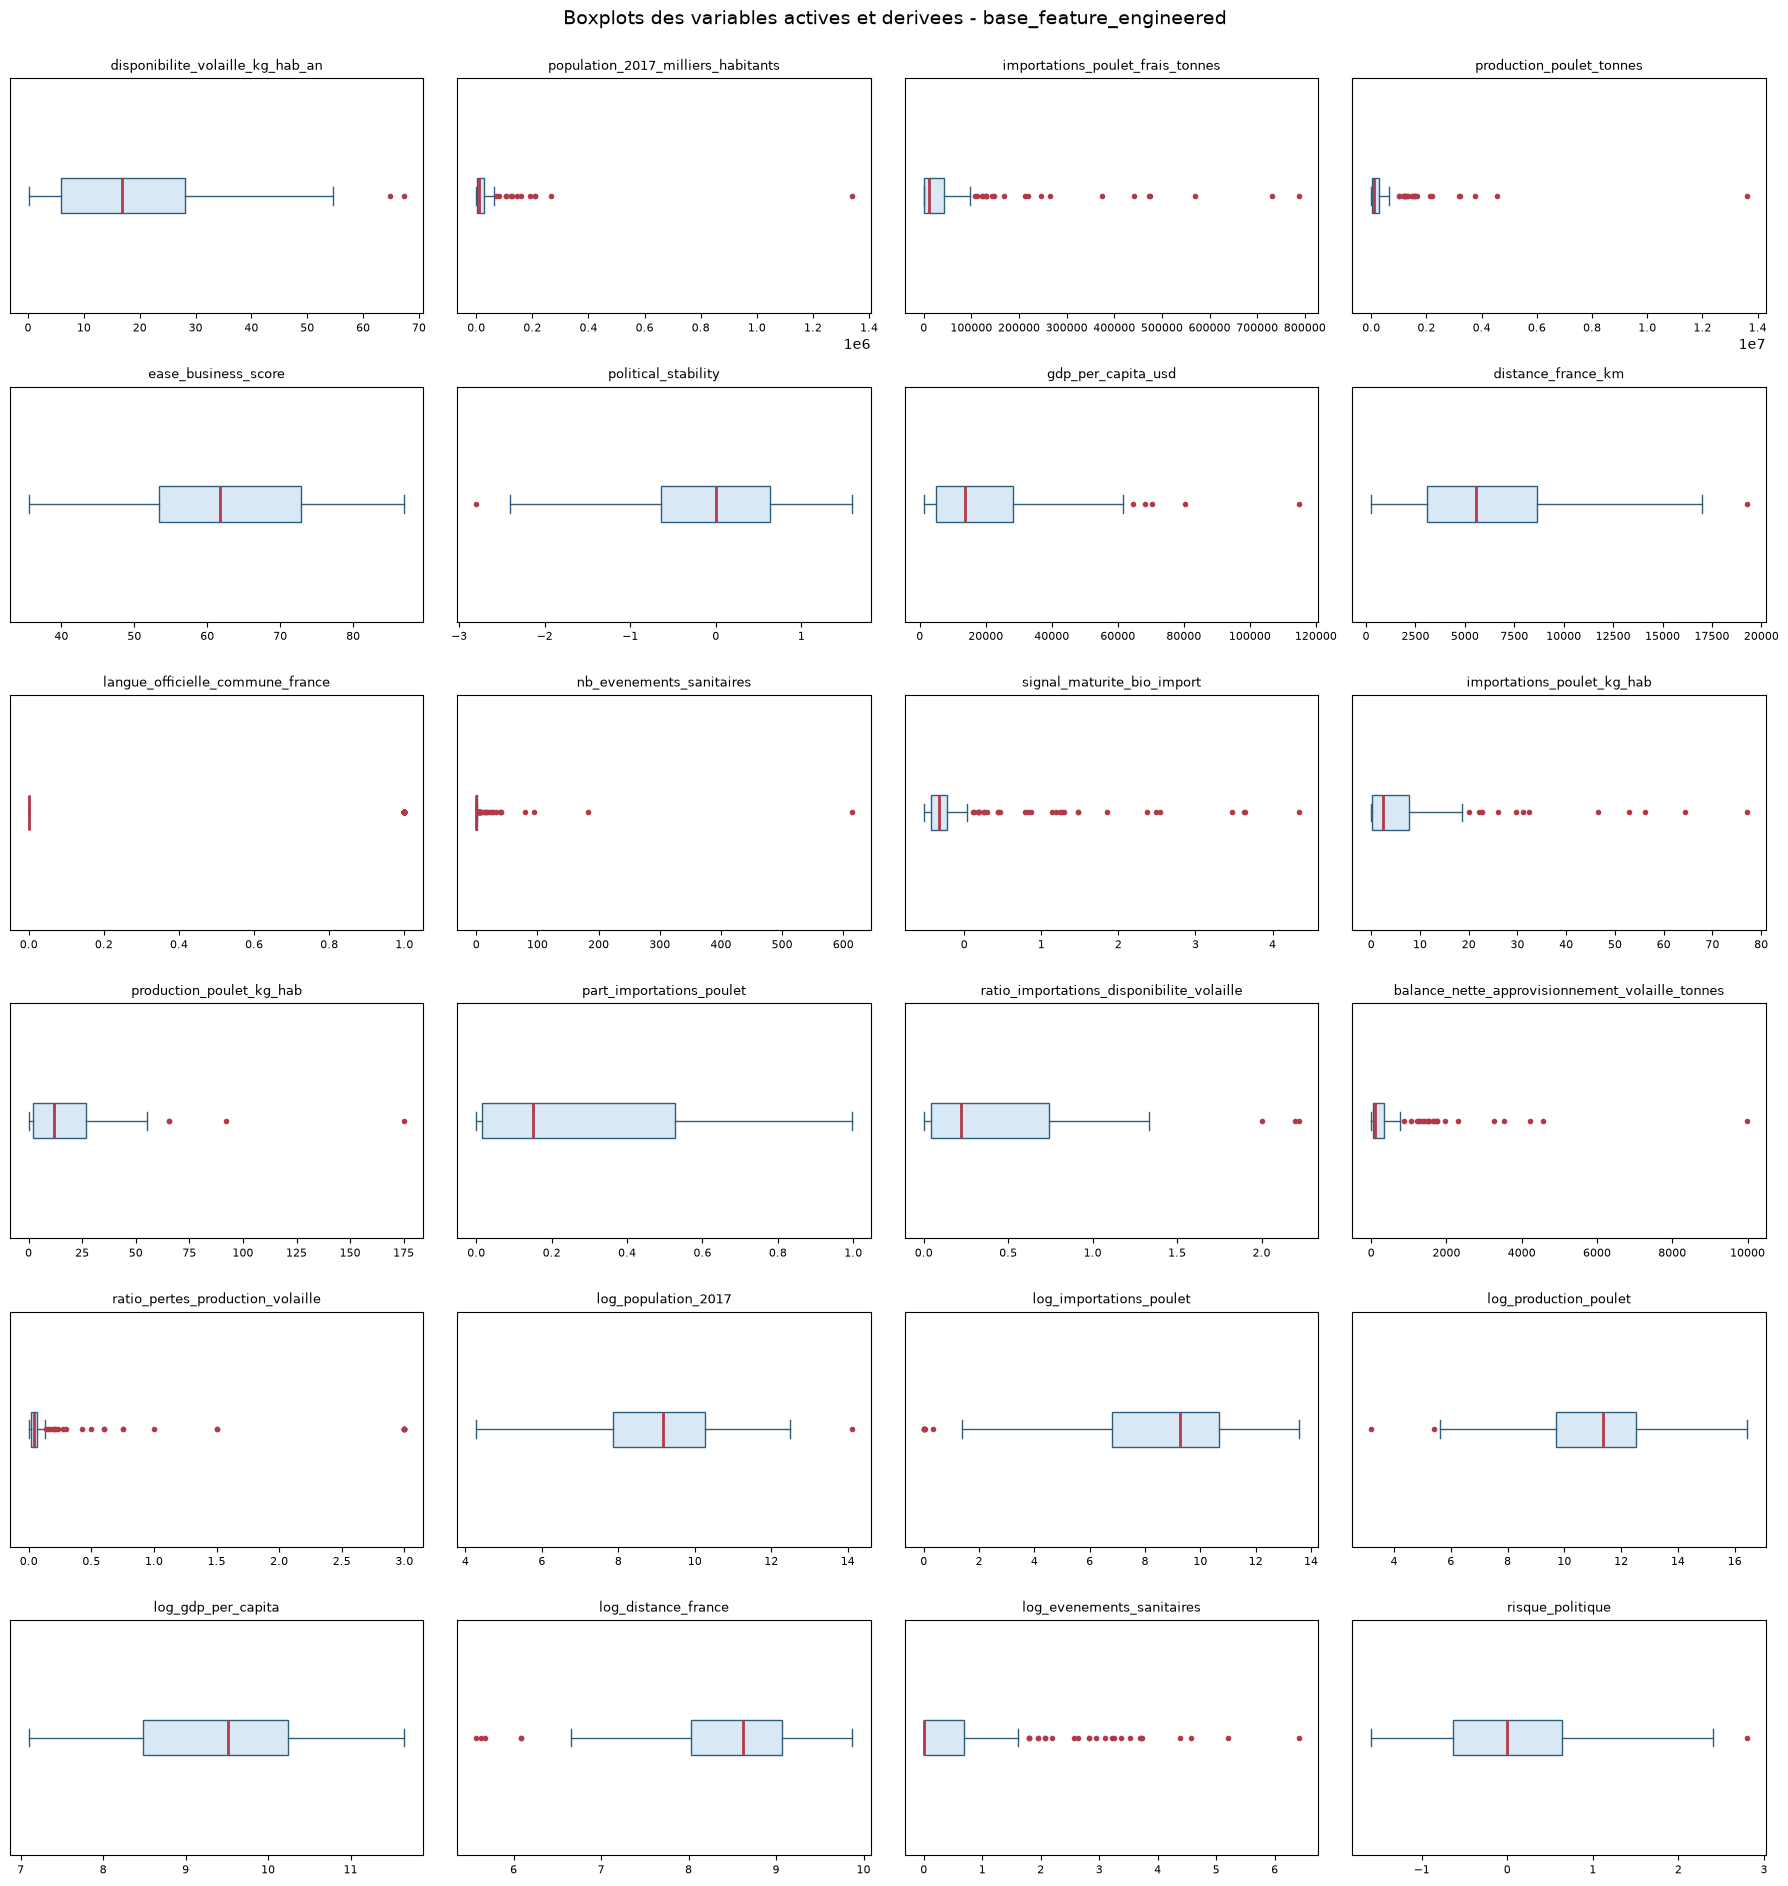

In [55]:
# J'analyse les distributions et les outliers par la methode IQR.
variables_ajoutees = variables_creees_feature_engineering['variable_creee'].tolist()
variables_outliers = variables_actives_retenues + variables_ajoutees

base_outliers = base_feature_engineered[identifiants + variables_outliers].copy()

stats_descriptives = (
    base_outliers[variables_outliers]
    .describe(percentiles=[0.25, 0.5, 0.75])
    .T
    .rename(columns={
        'count': 'nb_valeurs',
        'mean': 'moyenne',
        'std': 'ecart_type',
        'min': 'minimum',
        '25%': 'q1',
        '50%': 'mediane',
        '75%': 'q3',
        'max': 'maximum',
    })
    .reset_index(names='variable')
)

lignes_iqr = []
lignes_outliers = []

for variable in variables_outliers:
    serie = base_outliers[variable]
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr

    masque_outlier = serie.lt(borne_basse) | serie.gt(borne_haute)
    nb_outliers = int(masque_outlier.sum())

    lignes_iqr.append({
        'variable': variable,
        'q1': q1,
        'mediane': serie.median(),
        'q3': q3,
        'iqr': iqr,
        'borne_basse_iqr': borne_basse,
        'borne_haute_iqr': borne_haute,
        'nb_outliers_iqr': nb_outliers,
        'pct_outliers_iqr': round(nb_outliers / len(base_outliers) * 100, 1),
    })

    if nb_outliers > 0:
        ecart_mediane = (serie - serie.median()).abs()
        details = base_outliers.loc[masque_outlier, identifiants + [variable]].copy()
        details['variable'] = variable
        details['valeur'] = details[variable]
        details['borne_basse_iqr'] = borne_basse
        details['borne_haute_iqr'] = borne_haute
        details['ecart_mediane_abs'] = ecart_mediane.loc[masque_outlier]
        lignes_outliers.append(
            details[
                identifiants
                + ['variable', 'valeur', 'borne_basse_iqr', 'borne_haute_iqr', 'ecart_mediane_abs']
            ]
        )

controle_iqr = pd.DataFrame(lignes_iqr).sort_values(
    ['nb_outliers_iqr', 'pct_outliers_iqr'],
    ascending=False,
)

if lignes_outliers:
    detail_outliers_iqr = pd.concat(lignes_outliers, ignore_index=True).sort_values(
        ['variable', 'ecart_mediane_abs'],
        ascending=[True, False],
    )
else:
    detail_outliers_iqr = pd.DataFrame(
        columns=identifiants + ['variable', 'valeur', 'borne_basse_iqr', 'borne_haute_iqr', 'ecart_mediane_abs']
    )

controle_global_outliers = pd.DataFrame([{
    'dataset': 'base_feature_engineered',
    'pays': len(base_outliers),
    'variables_controlees': len(variables_outliers),
    'variables_avec_outliers_iqr': int(controle_iqr['nb_outliers_iqr'].gt(0).sum()),
    'lignes_outliers_documentees': len(detail_outliers_iqr),
    'nan_total': int(base_outliers.isna().sum().sum()),
}])

export_stats_descriptives = PROCESSED / 'stats_descriptives_base_feature_engineered.csv'
export_controle_iqr = PROCESSED / 'controle_outliers_iqr_base_feature_engineered.csv'
export_detail_outliers_iqr = PROCESSED / 'detail_outliers_iqr_base_feature_engineered.csv'

stats_descriptives.to_csv(export_stats_descriptives, index=False, encoding='utf-8-sig')
controle_iqr.to_csv(export_controle_iqr, index=False, encoding='utf-8-sig')
detail_outliers_iqr.to_csv(export_detail_outliers_iqr, index=False, encoding='utf-8-sig')

print('Variables controlees :', len(variables_outliers))
print('Variables avec outliers IQR :', int(controle_iqr['nb_outliers_iqr'].gt(0).sum()))
print('Lignes outliers documentees :', len(detail_outliers_iqr))
print('Export stats descriptives :', export_stats_descriptives)
print('Export controle IQR :', export_controle_iqr)
print('Export detail outliers :', export_detail_outliers_iqr)

display(controle_global_outliers)
display(stats_descriptives.round(3))
display(controle_iqr.round(3))
display(detail_outliers_iqr.head(30))

nb_colonnes_grille = 4
nb_lignes_grille = int(np.ceil(len(variables_outliers) / nb_colonnes_grille))
fig, axes = plt.subplots(
    nb_lignes_grille,
    nb_colonnes_grille,
    figsize=(18, 3.2 * nb_lignes_grille),
)
axes = np.array(axes).reshape(-1)

for axe, variable in zip(axes, variables_outliers):
    axe.boxplot(
        base_outliers[variable],
        vert=False,
        patch_artist=True,
        boxprops={'facecolor': '#d9e8f5', 'edgecolor': '#2f5d7c'},
        medianprops={'color': '#b23a48', 'linewidth': 2},
        whiskerprops={'color': '#2f5d7c'},
        capprops={'color': '#2f5d7c'},
        flierprops={'marker': 'o', 'markersize': 3, 'markerfacecolor': '#b23a48', 'markeredgecolor': '#b23a48'},
    )
    axe.set_title(variable, fontsize=9)
    axe.tick_params(axis='x', labelsize=8)
    axe.set_yticks([])

for axe in axes[len(variables_outliers):]:
    axe.axis('off')

fig.suptitle('Boxplots des variables actives et derivees - base_feature_engineered', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Conclusion de l'etape 12

L'analyse descriptive confirme que les variables n'ont pas les memes ordres de grandeur : certaines sont des scores bornes, d'autres des volumes tres asymetriques, des ratios, des distances, des indicateurs binaires ou un signal synthetique bio/import.

La methode IQR permet de documenter les valeurs atypiques sans les supprimer automatiquement. Ici, **24 variables** ont ete controlees, **21 variables** presentent au moins une valeur atypique selon l'IQR et **260 observations atypiques** sont documentees. Ces valeurs ne sont pas forcement des erreurs : elles peuvent representer de grands marches, des pays tres importateurs, de forts producteurs, des pays tres eloignes, des situations sanitaires particulieres, des pays plus matures sur le bio ou des situations particulieres d'approvisionnement/pertes.

Les nouveaux indicateurs de feature engineering apportent des controles utiles : `ratio_importations_disponibilite_volaille` donne une lecture de dependance alimentaire, `balance_nette_approvisionnement_volaille_tonnes` reconstitue l'approvisionnement net, et `ratio_pertes_production_volaille` documente l'efficacite alimentaire. Ils devront toutefois etre compares aux variables deja presentes pour eviter les doublons dans l'ACP.

Les boxplots montrent aussi pourquoi les transformations logarithmiques creees en section 11 sont utiles : elles reduisent l'effet des valeurs extremes sur les variables de volume, tout en conservant l'information de rang entre les pays.

Le signal `signal_maturite_bio_import` presente des valeurs atypiques positives : c'est attendu pour un indicateur de maturite bio premium, car seuls certains pays combinent une maturite bio FiBL forte et un signal d'importation OMC/ADB visible.

Pour la suite, je ne supprime donc pas les outliers a ce stade. Je les conserve, je les documente, puis je les prendrai en compte dans l'arbitrage final des variables et dans la standardisation avant l'ACP.

## 13. Preparation a la standardisation pour l'ACP
<a id="Preparation-des-donnees">Preparation-des-donnees</a>
### Pourquoi preparer les variables ?

Les variables finales ont des echelles differentes : volumes, ratios, scores, distances, parts et indicateurs binaires. Pour une ACP, ces differences d'echelle doivent etre neutralisees, sinon les variables les plus grandes numeriquement domineraient artificiellement les axes.

In [56]:
# Je prepare les variables numeriques pour la future standardisation ACP.
variables_standardisation_candidates = variables_actives_retenues + variables_ajoutees

base_pre_standardisation_acp = base_feature_engineered[
    identifiants + variables_standardisation_candidates + variables_trace_selection
].copy()

lignes_preparation_standardisation = []
for variable in variables_standardisation_candidates:
    serie = base_pre_standardisation_acp[variable]
    ecart_type = serie.std(ddof=0)
    est_binaire = serie.dropna().isin([0, 1]).all()
    est_constante = serie.nunique(dropna=False) <= 1
    standardisable = bool(pd.api.types.is_numeric_dtype(serie) and not est_constante and ecart_type > 0)

    if variable in variables_actives_retenues:
        origine = 'variable active existante'
    else:
        origine = 'variable ajoutee section 11'

    if est_constante:
        decision_preparation = 'exclure standardisation'
        justification = 'variable constante'
    elif not pd.api.types.is_numeric_dtype(serie):
        decision_preparation = 'exclure standardisation'
        justification = 'variable non numerique'
    elif est_binaire:
        decision_preparation = 'standardisable avec vigilance'
        justification = 'variable binaire interpretable, a surveiller car sa variance depend de la proportion de 1'
    else:
        decision_preparation = 'standardisable'
        justification = 'variable numerique non constante'

    lignes_preparation_standardisation.append({
        'variable': variable,
        'origine': origine,
        'type_variable': 'binaire' if est_binaire else 'numerique continue',
        'moyenne': serie.mean(),
        'ecart_type_population': ecart_type,
        'minimum': serie.min(),
        'maximum': serie.max(),
        'nb_valeurs_uniques': serie.nunique(dropna=False),
        'nb_nan': int(serie.isna().sum()),
        'standardisable': standardisable,
        'decision_preparation': decision_preparation,
        'justification': justification,
    })

controle_standardisation = pd.DataFrame(lignes_preparation_standardisation)
variables_standardisables = controle_standardisation.loc[
    controle_standardisation['standardisable'],
    'variable',
].tolist()

base_standardisee_preview = base_pre_standardisation_acp[identifiants].copy()
for variable in variables_standardisables:
    moyenne = controle_standardisation.loc[
        controle_standardisation['variable'].eq(variable),
        'moyenne',
    ].iloc[0]
    ecart_type = controle_standardisation.loc[
        controle_standardisation['variable'].eq(variable),
        'ecart_type_population',
    ].iloc[0]
    base_standardisee_preview[f'{variable}_zscore'] = (
        base_pre_standardisation_acp[variable] - moyenne
    ) / ecart_type

controle_base_pre_standardisation = pd.DataFrame([{
    'dataset': 'base_pre_standardisation_acp',
    'lignes': len(base_pre_standardisation_acp),
    'pays_iso3': base_pre_standardisation_acp['iso3'].nunique(),
    'variables_candidates': len(variables_standardisation_candidates),
    'variables_standardisables': len(variables_standardisables),
    'traces_imputation_conservees': len(variables_trace_selection),
    'nan_total': int(base_pre_standardisation_acp.isna().sum().sum()),
}])

export_base_pre_standardisation = PROCESSED / 'base_pre_standardisation_acp_2017.csv'
export_controle_standardisation = PROCESSED / 'controle_pre_standardisation_acp.csv'
export_preview_standardisee = PROCESSED / 'apercu_variables_standardisees_zscore.csv'

base_pre_standardisation_acp.to_csv(export_base_pre_standardisation, index=False, encoding='utf-8-sig')
controle_standardisation.to_csv(export_controle_standardisation, index=False, encoding='utf-8-sig')
base_standardisee_preview.to_csv(export_preview_standardisee, index=False, encoding='utf-8-sig')

print('Variables candidates standardisation :', len(variables_standardisation_candidates))
print('Variables standardisables :', len(variables_standardisables))
print('Export base pre-standardisation :', export_base_pre_standardisation)
print('Export controle standardisation :', export_controle_standardisation)
print('Export apercu z-score :', export_preview_standardisee)

display(controle_base_pre_standardisation)
display(controle_standardisation.round(4))
display(base_pre_standardisation_acp.head())
display(base_standardisee_preview.head())

Variables candidates standardisation : 24
Variables standardisables : 24
Export base pre-standardisation : C:\Users\feria\Documents\P11\data\processed\base_pre_standardisation_acp_2017.csv
Export controle standardisation : C:\Users\feria\Documents\P11\data\processed\controle_pre_standardisation_acp.csv
Export apercu z-score : C:\Users\feria\Documents\P11\data\processed\apercu_variables_standardisees_zscore.csv


,dataset,lignes,pays_iso3,variables_candidates,variables_standardisables,traces_imputation_conservees,nan_total
0,base_pre_standardisation_acp,139,139,24,24,6,0


,variable,origine,type_variable,moyenne,ecart_type_population,minimum,maximum,nb_valeurs_uniques,nb_nan,standardisable,decision_preparation,justification
0,disponibilite_volaille_kg_hab_an,variable active existante,numerique continue,18.8657,1.472350e+01,0.1300,6.739000e+01,138,0,True,standardisable,variable numerique non constante
1,population_2017_milliers_habitants,variable active existante,numerique continue,34782.0191,1.193630e+05,71.4580,1.338677e+06,139,0,True,standardisable,variable numerique non constante
2,importations_poulet_frais_tonnes,variable active existante,numerique continue,56965.6686,1.283119e+05,0.0000,7.884518e+05,135,0,True,standardisable,variable numerique non constante
3,production_poulet_tonnes,variable active existante,numerique continue,469719.3836,1.341557e+06,23.4800,1.360735e+07,137,0,True,standardisable,variable numerique non constante
4,ease_business_score,variable active existante,numerique continue,62.7835,1.239170e+01,35.5261,8.702210e+01,139,0,True,standardisable,variable numerique non constante
5,political_stability,variable active existante,numerique continue,-0.0575,8.725000e-01,-2.8000,1.590000e+00,114,0,True,standardisable,variable numerique non constante
6,gdp_per_capita_usd,variable active existante,numerique continue,19883.8098,1.946787e+04,1208.1461,1.149858e+05,139,0,True,standardisable,variable numerique non constante
7,distance_france_km,variable active existante,numerique continue,5968.0270,3.868895e+03,262.3845,1.926388e+04,135,0,True,standardisable,variable numerique non constante
8,langue_officielle_commune_france,variable active existante,binaire,0.1871,3.900000e-01,0.0000,1.000000e+00,2,0,True,standardisable avec vigilance,"variable binaire interpretable, a surveiller c..."
9,nb_evenements_sanitaires,variable active existante,numerique continue,9.8921,5.507620e+01,0.0000,6.140000e+02,25,0,True,standardisable,variable numerique non constante


,iso3,country_label,disponibilite_volaille_kg_hab_an,population_2017_milliers_habitants,importations_poulet_frais_tonnes,production_poulet_tonnes,ease_business_score,political_stability,gdp_per_capita_usd,distance_france_km,langue_officielle_commune_france,nb_evenements_sanitaires,signal_maturite_bio_import,importations_poulet_kg_hab,production_poulet_kg_hab,part_importations_poulet,ratio_importations_disponibilite_volaille,balance_nette_approvisionnement_volaille_tonnes,ratio_pertes_production_volaille,log_population_2017,log_importations_poulet,log_production_poulet,log_gdp_per_capita,log_distance_france,log_evenements_sanitaires,risque_politique,disponibilite_volaille_kg_hab_an_impute,importations_poulet_frais_tonnes_impute,production_poulet_tonnes_impute,distance_france_km_impute,langue_officielle_commune_france_impute,signal_maturite_bio_import_impute
0,AFG,Afghanistan,1.53,36296.113,28937.00,27637.84,37.13062,-2.80,2335.795862,5590.381,0.0,0.0,-0.324978,0.797248,0.761455,0.511482,0.508772,57.0,0.071429,10.499493,10.272911,10.226977,7.756536,8.628982,0.000000,2.80,0,0,0,0,0,1
1,AGO,Angola,10.56,29816.766,265888.30,40460.72,39.00774,-0.33,8006.836615,6510.322,0.0,0.0,-0.324978,8.917409,1.356979,0.867926,0.868339,319.0,0.047619,10.302860,12.490835,10.608112,8.988176,8.781298,0.000000,0.33,0,0,0,0,0,1
2,ALB,Albania,16.36,2884.169,17515.47,12912.00,66.83770,0.38,14110.683242,1603.534,0.0,0.0,-0.514623,6.072969,4.476853,0.575647,0.808511,51.0,0.230769,7.967339,9.770897,9.465990,9.554758,7.380589,0.000000,-0.38,0,0,0,0,0,0
3,ARE,United Arab Emirates,43.47,9487.203,440543.31,57387.00,79.30036,0.62,70281.888950,5249.535,0.0,0.0,-0.295802,46.435531,6.048885,0.884749,1.050971,387.0,0.062500,9.157805,12.995766,10.957591,11.160284,8.566085,0.000000,-0.62,0,0,0,0,0,0
4,ARG,Argentina,42.24,43937.140,2097.23,2116000.00,57.31005,0.17,23385.074090,11072.250,0.0,16.0,0.108496,0.047733,48.159712,0.000990,0.004077,1962.0,0.049051,10.690538,7.648849,14.565039,10.059896,9.312288,2.833213,-0.17,0,0,0,0,0,0


,iso3,country_label,disponibilite_volaille_kg_hab_an_zscore,population_2017_milliers_habitants_zscore,importations_poulet_frais_tonnes_zscore,production_poulet_tonnes_zscore,ease_business_score_zscore,political_stability_zscore,gdp_per_capita_usd_zscore,distance_france_km_zscore,langue_officielle_commune_france_zscore,nb_evenements_sanitaires_zscore,signal_maturite_bio_import_zscore,importations_poulet_kg_hab_zscore,production_poulet_kg_hab_zscore,part_importations_poulet_zscore,ratio_importations_disponibilite_volaille_zscore,balance_nette_approvisionnement_volaille_tonnes_zscore,ratio_pertes_production_volaille_zscore,log_population_2017_zscore,log_importations_poulet_zscore,log_production_poulet_zscore,log_gdp_per_capita_zscore,log_distance_france_zscore,log_evenements_sanitaires_zscore,risque_politique_zscore
0,AFG,Afghanistan,-1.177417,0.012685,-0.218442,-0.329529,-2.070163,-3.143326,-0.901383,-0.097611,-0.479675,-0.179607,-0.351263,-0.498110,-0.785016,0.659137,0.209082,-0.380145,-0.246321,0.840382,0.559382,-0.325852,-1.495318,0.255009,-0.519425,3.143326
1,AGO,Angola,-0.564112,-0.041598,1.628240,-0.319970,-1.918681,-0.312345,-0.610081,0.140168,-0.479675,-0.179607,-0.351263,0.164347,-0.758080,1.736000,0.994304,-0.147314,-0.284074,0.733335,1.246787,-0.169073,-0.364939,0.427782,-0.519425,0.312345
2,ALB,Albania,-0.170185,-0.267234,-0.307455,-0.340505,0.327168,0.501418,-0.296546,-1.128098,-0.479675,-0.179607,-0.564173,-0.067707,-0.616966,0.852987,0.863652,-0.385477,0.006337,-0.538113,0.403793,-0.638881,0.155061,-1.161047,-0.519425,-0.501418
3,ARE,United Arab Emirates,1.671087,-0.211915,2.989416,-0.307354,1.332892,0.776493,2.588783,-0.185710,-0.479675,-0.179607,-0.318508,3.225144,-0.545861,1.786824,1.393137,-0.086885,-0.260478,0.109972,1.403281,-0.025316,1.628585,0.183666,-0.519425,-0.776493
4,ARG,Argentina,1.587547,0.076700,-0.427618,1.227141,-0.441704,0.260728,0.179848,1.319297,-0.479675,0.110899,0.135387,-0.559257,1.358850,-0.883123,-0.893071,1.312766,-0.281803,0.944386,-0.253897,1.458597,0.618667,1.030085,1.686350,-0.260728


### Conclusion de l'etape 13

La base `base_pre_standardisation_acp` est prete pour la suite : elle conserve les identifiants pays, les **20 variables candidates** issues des variables actives et du feature engineering, ainsi que les **5 traces d'imputation** utiles pour documenter la qualite.

Toutes les variables candidates sont numeriques, non constantes et donc standardisables. La variable `langue_officielle_commune_france` est bien standardisable techniquement, mais elle reste a surveiller car c'est une variable binaire : son poids dans l'ACP dependra de sa distribution entre les pays.

L'apercu z-score permet de verifier l'effet attendu de la standardisation : les variables sont ramenees sur une echelle comparable, sans modifier le rang des pays. La standardisation definitive pourra etre faite dans le notebook 2 avant l'ACP.

La prochaine etape consiste a analyser les correlations pour eviter de conserver plusieurs variables portant la meme information.

## 14. Analyse des correlations et de la colinearite

### Objectif

Identifier les redondances fortes avant la selection finale. Deux variables tres correlees peuvent porter la meme information et rendre l'interpretation ACP moins lisible.

### Methode retenue

Pour detecter la colinearite, j'utilise d'abord la **matrice de correlation de Pearson** sur les **20 variables candidates** preparees en section 13. Pearson est adapte ici car l'objectif est de reperer des relations lineaires fortes entre variables numeriques avant l'ACP.

Je retiens trois niveaux de lecture :

- `|correlation| >= 0.90` : redondance tres forte, arbitrage prioritaire ;
- `0.80 <= |correlation| < 0.90` : correlation forte, variable a surveiller ;
- `|correlation| < 0.80` : pas d'alerte de colinearite forte.

La detection ne supprime aucune variable automatiquement. Elle sert a construire un tableau de paires correlees, puis a arbitrer en section 15 selon l'interpretation metier, la qualite de la variable et la lisibilite pour l'ACP.

En controle secondaire, une correlation de **Spearman** peut etre calculee pour verifier si certaines relations monotones restent fortes apres les transformations logarithmiques. Le VIF est plutot reserve aux modeles de regression ; il peut aider, mais il est moins pedagogique et moins prioritaire ici que la matrice de correlations pour preparer une ACP.

Variables analysees : 24
Paires totales : 276
Paires Pearson avec |correlation| >= 0.80 : 5
Paires Spearman avec |correlation| >= 0.80 : 12
Export matrice Pearson : C:\Users\feria\Documents\P11\data\processed\matrice_correlation_pearson_variables_candidates.csv
Export matrice Spearman : C:\Users\feria\Documents\P11\data\processed\matrice_correlation_spearman_variables_candidates.csv
Export rapport colinearite : C:\Users\feria\Documents\P11\data\processed\rapport_colinearite_variables_candidates.csv
Export paires Pearson fortes : C:\Users\feria\Documents\P11\data\processed\paires_colinearite_pearson_forte_variables_candidates.csv
Export paires Spearman fortes : C:\Users\feria\Documents\P11\data\processed\paires_colinearite_spearman_forte_variables_candidates.csv


,dataset,variables_analysees,paires_total,paires_pearson_forte_080,paires_pearson_tres_forte_090,paires_spearman_forte_080,paires_spearman_tres_forte_090,nan_total_matrice_pearson,nan_total_matrice_spearman
0,base_pre_standardisation_acp,24,276,5,2,12,10,0,0


Matrice de correlation de Pearson


,disponibilite_volaille_kg_hab_an,population_2017_milliers_habitants,importations_poulet_frais_tonnes,production_poulet_tonnes,ease_business_score,political_stability,gdp_per_capita_usd,distance_france_km,langue_officielle_commune_france,nb_evenements_sanitaires,signal_maturite_bio_import,importations_poulet_kg_hab,production_poulet_kg_hab,part_importations_poulet,ratio_importations_disponibilite_volaille,balance_nette_approvisionnement_volaille_tonnes,ratio_pertes_production_volaille,log_population_2017,log_importations_poulet,log_production_poulet,log_gdp_per_capita,log_distance_france,log_evenements_sanitaires,risque_politique
disponibilite_volaille_kg_hab_an,1.00,-0.12,0.19,0.23,0.40,0.42,0.43,0.11,-0.22,0.03,0.04,0.47,0.44,0.05,-0.03,0.26,-0.06,-0.27,0.21,0.14,0.58,0.02,0.09,-0.42
population_2017_milliers_habitants,-0.12,1.00,0.06,0.42,-0.03,-0.21,-0.09,0.04,-0.08,0.04,-0.07,-0.13,-0.06,-0.18,-0.19,0.45,-0.07,0.47,-0.16,0.33,-0.07,0.07,0.13,0.21
importations_poulet_frais_tonnes,0.19,0.06,1.00,0.18,0.18,-0.03,0.28,-0.09,-0.11,0.31,-0.04,0.17,-0.02,0.16,0.13,0.36,-0.12,0.31,0.52,0.31,0.29,-0.13,0.30,0.03
production_poulet_tonnes,0.23,0.42,0.18,1.00,0.09,-0.10,0.03,0.12,-0.12,0.07,-0.07,-0.14,0.25,-0.24,-0.23,0.97,-0.11,0.44,0.02,0.50,0.11,0.08,0.22,0.10
ease_business_score,0.40,-0.03,0.18,0.09,1.00,0.55,0.66,-0.20,-0.23,0.21,0.32,0.03,0.25,-0.16,-0.10,0.14,-0.22,0.01,0.24,0.30,0.74,-0.38,0.42,-0.55
political_stability,0.42,-0.21,-0.03,-0.10,0.55,1.00,0.58,0.07,-0.13,0.12,0.33,0.32,0.20,0.21,0.25,-0.10,0.16,-0.54,0.15,-0.25,0.58,-0.15,0.22,-1.00
gdp_per_capita_usd,0.43,-0.09,0.28,0.03,0.66,0.58,1.00,-0.32,-0.08,0.22,0.37,0.16,0.25,0.01,0.07,0.08,-0.18,-0.10,0.29,0.15,0.87,-0.55,0.37,-0.58
distance_france_km,0.11,0.04,-0.09,0.12,-0.20,0.07,-0.32,1.00,-0.14,-0.16,-0.30,0.03,0.13,-0.04,-0.10,0.10,0.14,-0.10,-0.28,-0.07,-0.26,0.89,-0.20,-0.07
langue_officielle_commune_france,-0.22,-0.08,-0.11,-0.12,-0.23,-0.13,-0.08,-0.14,1.00,-0.07,-0.09,-0.03,-0.13,-0.01,0.03,-0.14,-0.06,-0.01,-0.21,-0.12,-0.25,-0.14,-0.16,0.13
nb_evenements_sanitaires,0.03,0.04,0.31,0.07,0.21,0.12,0.22,-0.16,-0.07,1.00,0.17,-0.03,0.02,-0.04,0.01,0.14,-0.06,0.16,0.17,0.17,0.20,-0.29,0.61,-0.12


Matrice de correlation de Spearman


,disponibilite_volaille_kg_hab_an,population_2017_milliers_habitants,importations_poulet_frais_tonnes,production_poulet_tonnes,ease_business_score,political_stability,gdp_per_capita_usd,distance_france_km,langue_officielle_commune_france,nb_evenements_sanitaires,signal_maturite_bio_import,importations_poulet_kg_hab,production_poulet_kg_hab,part_importations_poulet,ratio_importations_disponibilite_volaille,balance_nette_approvisionnement_volaille_tonnes,ratio_pertes_production_volaille,log_population_2017,log_importations_poulet,log_production_poulet,log_gdp_per_capita,log_distance_france,log_evenements_sanitaires,risque_politique
disponibilite_volaille_kg_hab_an,1.00,-0.25,0.34,0.24,0.49,0.49,0.66,0.01,-0.24,0.15,0.11,0.42,0.66,0.10,0.10,0.33,-0.28,-0.25,0.34,0.24,0.66,0.01,0.15,-0.49
population_2017_milliers_habitants,-0.25,1.00,0.10,0.74,-0.03,-0.54,-0.13,-0.01,0.02,0.30,-0.19,-0.52,0.01,-0.49,-0.53,0.72,-0.22,1.00,0.10,0.74,-0.13,-0.01,0.30,0.54
importations_poulet_frais_tonnes,0.34,0.10,1.00,0.16,0.32,0.15,0.38,-0.29,-0.19,0.25,0.10,0.70,0.10,0.61,0.55,0.38,-0.24,0.10,1.00,0.16,0.38,-0.29,0.25,-0.15
production_poulet_tonnes,0.24,0.74,0.16,1.00,0.32,-0.22,0.31,-0.01,-0.14,0.44,-0.03,-0.38,0.62,-0.62,-0.56,0.91,-0.37,0.74,0.16,1.00,0.31,-0.01,0.44,0.22
ease_business_score,0.49,-0.03,0.32,0.32,1.00,0.55,0.77,-0.28,-0.23,0.44,0.24,0.21,0.47,-0.00,0.02,0.32,-0.25,-0.03,0.32,0.32,0.77,-0.28,0.44,-0.55
political_stability,0.49,-0.54,0.15,-0.22,0.55,1.00,0.62,-0.04,-0.16,0.18,0.39,0.45,0.27,0.30,0.33,-0.18,-0.09,-0.54,0.15,-0.22,0.62,-0.04,0.18,-1.00
gdp_per_capita_usd,0.66,-0.13,0.38,0.31,0.77,0.62,1.00,-0.32,-0.24,0.43,0.28,0.37,0.57,0.08,0.12,0.36,-0.31,-0.13,0.38,0.31,1.00,-0.32,0.43,-0.62
distance_france_km,0.01,-0.01,-0.29,-0.01,-0.28,-0.04,-0.32,1.00,-0.16,-0.22,-0.27,-0.23,0.04,-0.19,-0.22,-0.03,0.13,-0.01,-0.29,-0.01,-0.32,1.00,-0.22,0.04
langue_officielle_commune_france,-0.24,0.02,-0.19,-0.14,-0.23,-0.16,-0.24,-0.16,1.00,-0.18,-0.08,-0.13,-0.19,-0.08,-0.04,-0.16,-0.08,0.02,-0.19,-0.14,-0.24,-0.16,-0.18,0.16
nb_evenements_sanitaires,0.15,0.30,0.25,0.44,0.44,0.18,0.43,-0.22,-0.18,1.00,0.30,0.00,0.31,-0.14,-0.08,0.40,-0.20,0.30,0.25,0.44,0.43,-0.22,1.00,-0.18


Paires fortes selon Pearson


,variable_1,variable_2,correlation_pearson,correlation_spearman,abs_pearson,abs_spearman,niveau_alerte_pearson,niveau_alerte_spearman,decision_pearson
0,political_stability,risque_politique,-1.000,-1.000,1.000,1.000,redondance tres forte,relation monotone tres forte,arbitrage prioritaire en section 15
1,production_poulet_tonnes,balance_nette_approvisionnement_volaille_tonnes,0.970,0.914,0.970,0.914,redondance tres forte,relation monotone tres forte,arbitrage prioritaire en section 15
2,distance_france_km,log_distance_france,0.885,1.000,0.885,1.000,correlation forte,relation monotone tres forte,surveiller en section 15
3,gdp_per_capita_usd,log_gdp_per_capita,0.870,1.000,0.870,1.000,correlation forte,relation monotone tres forte,surveiller en section 15
4,part_importations_poulet,ratio_importations_disponibilite_volaille,0.825,0.918,0.825,0.918,correlation forte,relation monotone tres forte,surveiller en section 15


Paires fortes selon Spearman


,variable_1,variable_2,correlation_pearson,correlation_spearman,abs_pearson,abs_spearman,niveau_alerte_pearson,niveau_alerte_spearman,decision_pearson
0,political_stability,risque_politique,-1.000,-1.000,1.000,1.000,redondance tres forte,relation monotone tres forte,arbitrage prioritaire en section 15
2,distance_france_km,log_distance_france,0.885,1.000,0.885,1.000,correlation forte,relation monotone tres forte,surveiller en section 15
3,gdp_per_capita_usd,log_gdp_per_capita,0.870,1.000,0.870,1.000,correlation forte,relation monotone tres forte,surveiller en section 15
11,nb_evenements_sanitaires,log_evenements_sanitaires,0.608,1.000,0.608,1.000,pas d alerte forte,relation monotone tres forte,conserver pour analyse
27,production_poulet_tonnes,log_production_poulet,0.501,1.000,0.501,1.000,pas d alerte forte,relation monotone tres forte,conserver pour analyse
32,population_2017_milliers_habitants,log_population_2017,0.466,1.000,0.466,1.000,pas d alerte forte,relation monotone tres forte,conserver pour analyse
24,importations_poulet_frais_tonnes,log_importations_poulet,0.521,1.000,0.521,1.000,pas d alerte forte,relation monotone tres forte,conserver pour analyse
4,part_importations_poulet,ratio_importations_disponibilite_volaille,0.825,0.918,0.825,0.918,correlation forte,relation monotone tres forte,surveiller en section 15
1,production_poulet_tonnes,balance_nette_approvisionnement_volaille_tonnes,0.970,0.914,0.970,0.914,redondance tres forte,relation monotone tres forte,arbitrage prioritaire en section 15
17,balance_nette_approvisionnement_volaille_tonnes,log_production_poulet,0.564,0.914,0.564,0.914,pas d alerte forte,relation monotone tres forte,conserver pour analyse


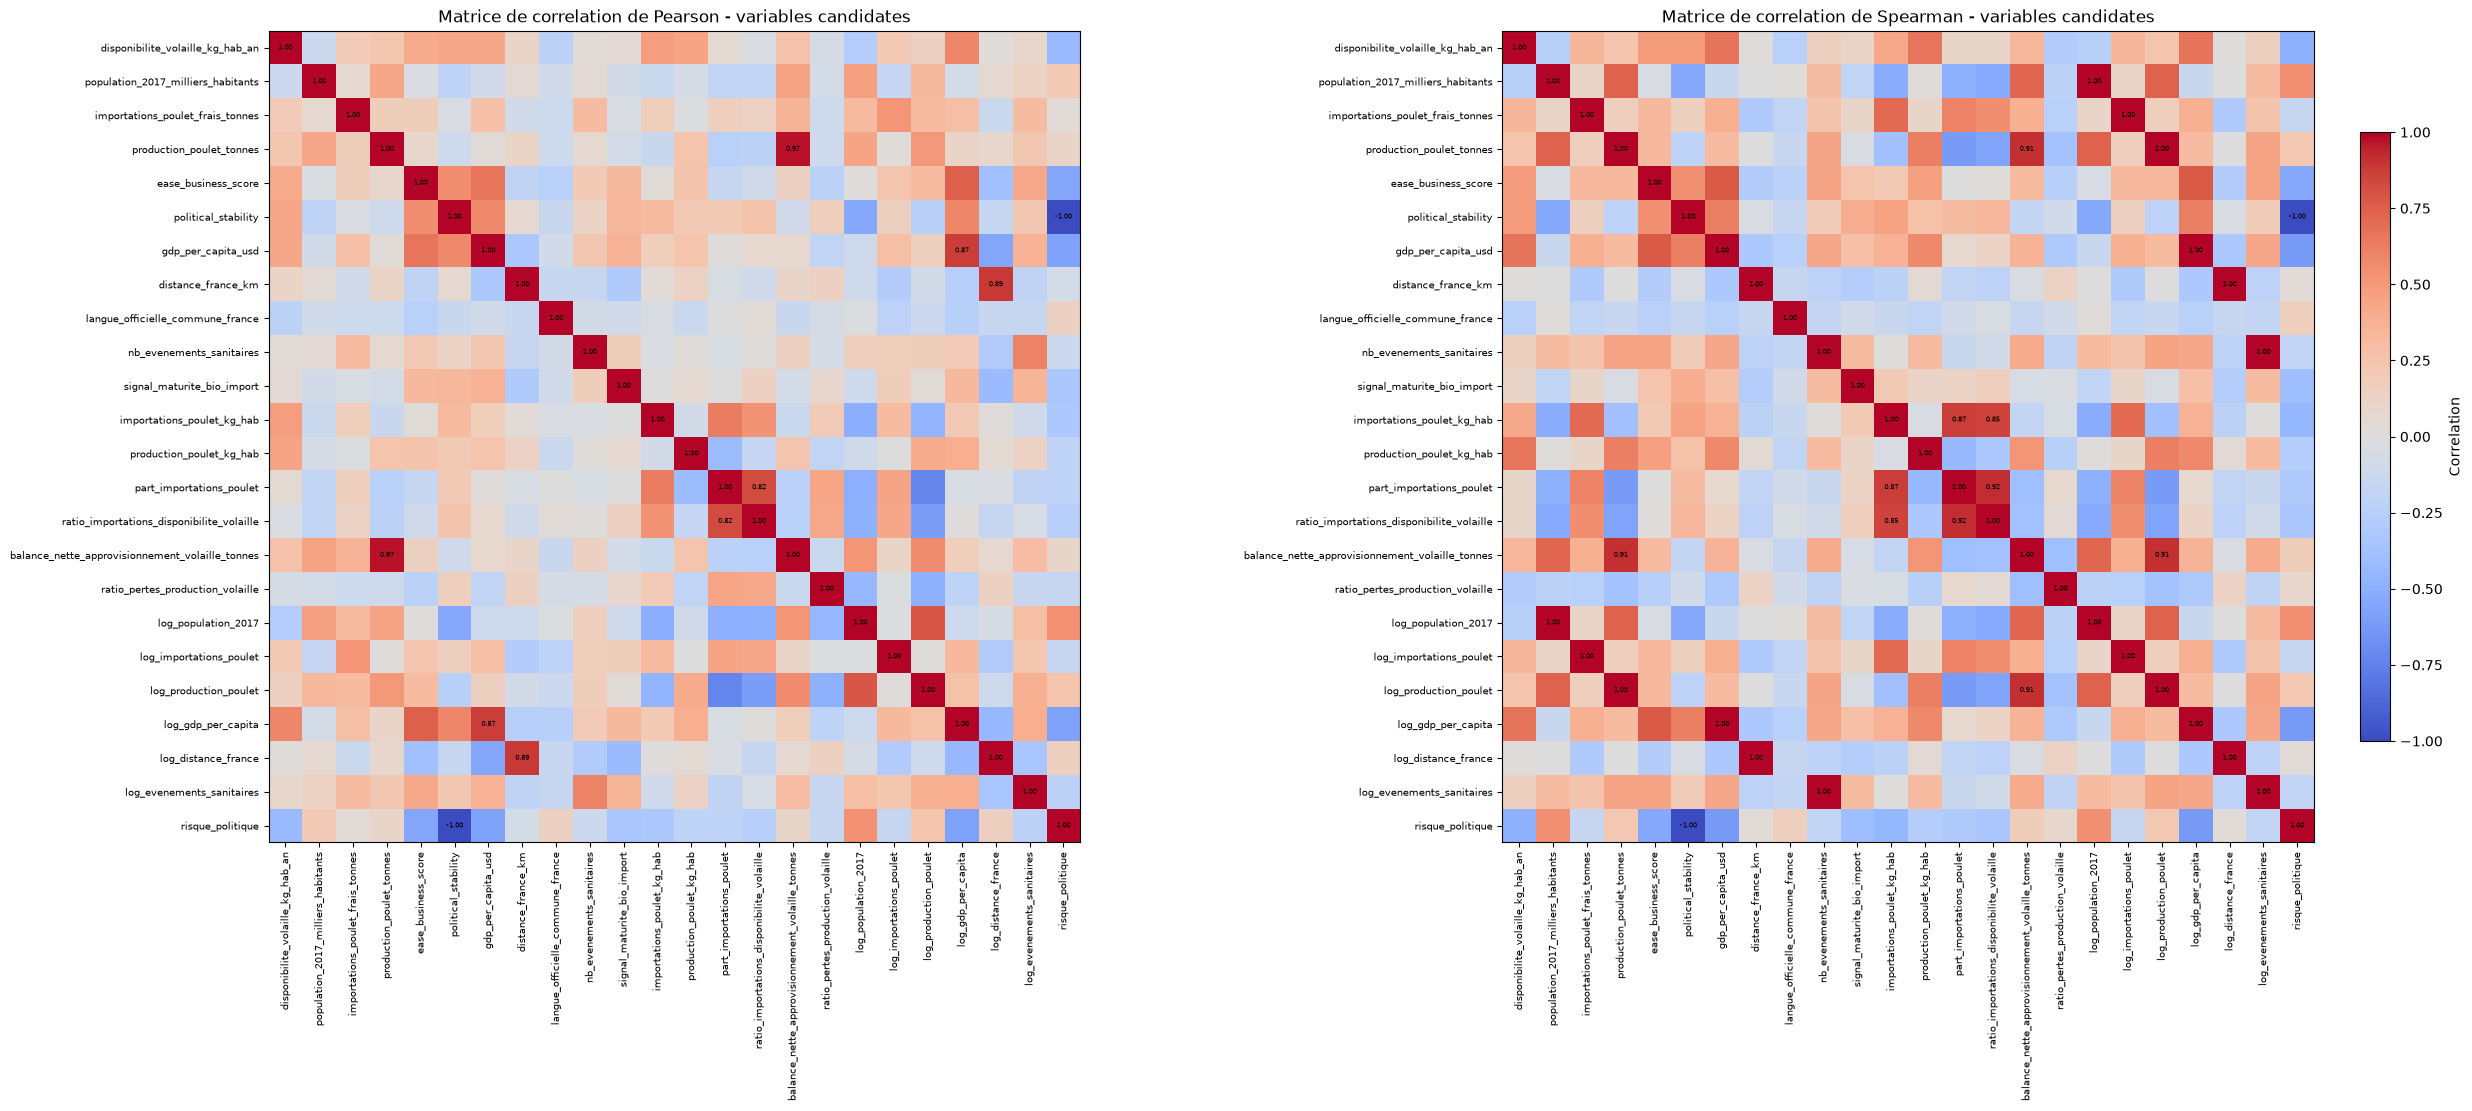

In [57]:
# Je calcule la matrice de correlation pour detecter les colinearites.
variables_correlation = variables_standardisables.copy()
base_correlation = base_pre_standardisation_acp[variables_correlation].copy()

matrice_correlation_pearson = base_correlation.corr(method='pearson')
matrice_correlation_spearman = base_correlation.corr(method='spearman')

paires_correlation = []
for i, variable_1 in enumerate(variables_correlation):
    for variable_2 in variables_correlation[i + 1:]:
        correlation_pearson = matrice_correlation_pearson.loc[variable_1, variable_2]
        correlation_spearman = matrice_correlation_spearman.loc[variable_1, variable_2]
        correlation_pearson_absolue = abs(correlation_pearson)
        correlation_spearman_absolue = abs(correlation_spearman)

        if correlation_pearson_absolue >= 0.90:
            niveau_alerte_pearson = 'redondance tres forte'
            decision_pearson = 'arbitrage prioritaire en section 15'
        elif correlation_pearson_absolue >= 0.80:
            niveau_alerte_pearson = 'correlation forte'
            decision_pearson = 'surveiller en section 15'
        else:
            niveau_alerte_pearson = 'pas d alerte forte'
            decision_pearson = 'conserver pour analyse'

        if correlation_spearman_absolue >= 0.90:
            niveau_alerte_spearman = 'relation monotone tres forte'
        elif correlation_spearman_absolue >= 0.80:
            niveau_alerte_spearman = 'relation monotone forte'
        else:
            niveau_alerte_spearman = 'pas d alerte monotone forte'

        paires_correlation.append({
            'variable_1': variable_1,
            'variable_2': variable_2,
            'correlation_pearson': correlation_pearson,
            'correlation_spearman': correlation_spearman,
            'abs_pearson': correlation_pearson_absolue,
            'abs_spearman': correlation_spearman_absolue,
            'niveau_alerte_pearson': niveau_alerte_pearson,
            'niveau_alerte_spearman': niveau_alerte_spearman,
            'decision_pearson': decision_pearson,
        })

rapport_colinearite = (
    pd.DataFrame(paires_correlation)
    .sort_values(['abs_pearson', 'abs_spearman'], ascending=False)
    .reset_index(drop=True)
)

paires_colinearite_pearson_forte = rapport_colinearite.loc[
    rapport_colinearite['abs_pearson'].ge(0.80)
].copy()
paires_colinearite_spearman_forte = rapport_colinearite.loc[
    rapport_colinearite['abs_spearman'].ge(0.80)
].sort_values(
    'abs_spearman',
    ascending=False,
).copy()

controle_colinearite = pd.DataFrame([{
    'dataset': 'base_pre_standardisation_acp',
    'variables_analysees': len(variables_correlation),
    'paires_total': len(rapport_colinearite),
    'paires_pearson_forte_080': len(paires_colinearite_pearson_forte),
    'paires_pearson_tres_forte_090': int(rapport_colinearite['abs_pearson'].ge(0.90).sum()),
    'paires_spearman_forte_080': len(paires_colinearite_spearman_forte),
    'paires_spearman_tres_forte_090': int(rapport_colinearite['abs_spearman'].ge(0.90).sum()),
    'nan_total_matrice_pearson': int(matrice_correlation_pearson.isna().sum().sum()),
    'nan_total_matrice_spearman': int(matrice_correlation_spearman.isna().sum().sum()),
}])

export_matrice_correlation_pearson = PROCESSED / 'matrice_correlation_pearson_variables_candidates.csv'
export_matrice_correlation_spearman = PROCESSED / 'matrice_correlation_spearman_variables_candidates.csv'
export_rapport_colinearite = PROCESSED / 'rapport_colinearite_variables_candidates.csv'
export_paires_colinearite_pearson_forte = PROCESSED / 'paires_colinearite_pearson_forte_variables_candidates.csv'
export_paires_colinearite_spearman_forte = PROCESSED / 'paires_colinearite_spearman_forte_variables_candidates.csv'

matrice_correlation_pearson.to_csv(export_matrice_correlation_pearson, encoding='utf-8-sig')
matrice_correlation_spearman.to_csv(export_matrice_correlation_spearman, encoding='utf-8-sig')
rapport_colinearite.to_csv(export_rapport_colinearite, index=False, encoding='utf-8-sig')
paires_colinearite_pearson_forte.to_csv(export_paires_colinearite_pearson_forte, index=False, encoding='utf-8-sig')
paires_colinearite_spearman_forte.to_csv(export_paires_colinearite_spearman_forte, index=False, encoding='utf-8-sig')

print('Variables analysees :', len(variables_correlation))
print('Paires totales :', len(rapport_colinearite))
print('Paires Pearson avec |correlation| >= 0.80 :', len(paires_colinearite_pearson_forte))
print('Paires Spearman avec |correlation| >= 0.80 :', len(paires_colinearite_spearman_forte))
print('Export matrice Pearson :', export_matrice_correlation_pearson)
print('Export matrice Spearman :', export_matrice_correlation_spearman)
print('Export rapport colinearite :', export_rapport_colinearite)
print('Export paires Pearson fortes :', export_paires_colinearite_pearson_forte)
print('Export paires Spearman fortes :', export_paires_colinearite_spearman_forte)

display(controle_colinearite)
print('Matrice de correlation de Pearson')
display(matrice_correlation_pearson.round(2))
print('Matrice de correlation de Spearman')
display(matrice_correlation_spearman.round(2))
print('Paires fortes selon Pearson')
display(paires_colinearite_pearson_forte.round(3))
print('Paires fortes selon Spearman')
display(paires_colinearite_spearman_forte.round(3))

fig, axes = plt.subplots(1, 2, figsize=(26, 11), constrained_layout=True)
matrices_a_afficher = [
    ('Pearson', matrice_correlation_pearson),
    ('Spearman', matrice_correlation_spearman),
]

for axe, (methode, matrice) in zip(axes, matrices_a_afficher):
    image = axe.imshow(
        matrice,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
    )
    axe.set_title(f'Matrice de correlation de {methode} - variables candidates', fontsize=12)
    axe.set_xticks(range(len(variables_correlation)))
    axe.set_yticks(range(len(variables_correlation)))
    axe.set_xticklabels(variables_correlation, rotation=90, fontsize=7)
    axe.set_yticklabels(variables_correlation, fontsize=7)

    for ligne in range(len(variables_correlation)):
        for colonne in range(len(variables_correlation)):
            valeur = matrice.iloc[ligne, colonne]
            if abs(valeur) >= 0.80 or ligne == colonne:
                axe.text(
                    colonne,
                    ligne,
                    f'{valeur:.2f}',
                    ha='center',
                    va='center',
                    fontsize=5,
                    color='black',
                )

fig.colorbar(image, ax=axes, location='right', shrink=0.75, pad=0.02, label='Correlation')
plt.show()

### Conclusion de l'etape 14

La matrice de correlation de Pearson met en evidence quelques colinearites lineaires fortes parmi les **24 variables candidates** : sur 276 paires possibles, **5 paires** depassent le seuil de `|correlation| >= 0.80`.

La redondance la plus forte est mecanique : `political_stability` et `risque_politique` sont parfaitement correlees en sens inverse, puisque `risque_politique` est construit comme l'oppose de la stabilite politique. Il faudra donc en conserver une seule dans la selection finale.

Pearson signale aussi des redondances fortes entre variables brutes et variables transformees : `distance_france_km` avec `log_distance_france`, et `gdp_per_capita_usd` avec `log_gdp_per_capita`. Dans ces deux cas, l'arbitrage portera surtout sur la lisibilite : garder la variable brute pour l'interpretation directe, ou la version logarithmique pour reduire l'effet des valeurs extremes.

Les nouveaux controles de feature engineering sont egalement informatifs : `ratio_importations_disponibilite_volaille` est fortement correle avec `part_importations_poulet`, et `balance_nette_approvisionnement_volaille_tonnes` est tres proche de `production_poulet_tonnes`. Ils seront donc documentes, mais ne devront pas etre conserves en doublon dans l'ACP finale.

Le signal `signal_maturite_bio_import` ne cree pas de redondance forte avec les autres variables candidates. Il apporte donc une information specifique sur la maturite bio premium et l'attractivite import, ce qui repond directement au cadrage du projet.

La matrice de Spearman complete cette lecture : elle detecte **12 relations monotones fortes**. C'est attendu, car une transformation logarithmique conserve le rang des pays. Spearman signale donc plus fortement les couples variable brute / variable log, par exemple population, importations, production, distance, PIB par habitant ou evenements sanitaires.

La section 15 pourra donc utiliser les deux diagnostics : Pearson pour reperer les redondances lineaires qui pesent directement sur l'ACP, et Spearman pour documenter les relations monotones creees par les transformations. A ce stade, aucune variable n'est supprimee automatiquement.

## 15. Selection finale des variables

### Methode d'arbitrage

Cette etape transforme les controles precedents en choix final pour l'ACP. L'objectif n'est pas de garder toutes les variables disponibles, mais de conserver une representation equilibree des dimensions metier : demande, taille du marche, dependance aux importations, production locale, environnement economique, stabilite politique, richesse, distance, proximite linguistique, risque sanitaire et maturite bio premium.

Pour chaque famille, on compare les variables brutes, les variables logarithmiques et les variables construites. Les decisions tiennent compte de quatre criteres : absence de valeurs manquantes, standardisation possible, sensibilite aux valeurs extremes observee en section 12, et redondance mesuree par Pearson et Spearman en section 14.

<a id="Constitution-de-la-base-ACP">Constitution-de-la-base-ACP</a>

In [58]:
# Je supprime les redondances en gardant une seule variable active par famille.
variables_finales_acp = [
    'disponibilite_volaille_kg_hab_an',
    'log_population_2017',
    'part_importations_poulet',
    'log_production_poulet',
    'ease_business_score',
    'political_stability',
    'log_gdp_per_capita',
    'log_distance_france',
    'langue_officielle_commune_france',
    'log_evenements_sanitaires',
    'signal_maturite_bio_import',
]

arbitrage_selection_finale = pd.DataFrame([
    {
        'famille': 'Demande alimentaire',
        'variable': 'disponibilite_volaille_kg_hab_an',
        'decision_finale': 'retenue',
        'raison_finale': 'indicateur direct de consommation potentielle par habitant, non redondant avec les volumes totaux',
    },
    {
        'famille': 'Taille du marche',
        'variable': 'population_2017_milliers_habitants',
        'decision_finale': 'ecartee',
        'raison_finale': 'redondante avec log_population_2017 ; la version log reduit l influence des tres grands pays',
    },
    {
        'famille': 'Taille du marche',
        'variable': 'log_population_2017',
        'decision_finale': 'retenue',
        'raison_finale': 'represente la taille du marche en limitant l effet des valeurs extremes',
    },
    {
        'famille': 'Dependance aux importations',
        'variable': 'importations_poulet_frais_tonnes',
        'decision_finale': 'ecartee',
        'raison_finale': 'volume total redondant avec les transformations et sensible a la taille du pays',
    },
    {
        'famille': 'Dependance aux importations',
        'variable': 'log_importations_poulet',
        'decision_finale': 'ecartee',
        'raison_finale': 'utile pour reduire les extremes mais moins interpretable que la part des importations dans la logique export',
    },
    {
        'famille': 'Dependance aux importations',
        'variable': 'importations_poulet_kg_hab',
        'decision_finale': 'ecartee',
        'raison_finale': 'relation monotone forte avec part_importations_poulet ; on conserve l indicateur de dependance',
    },
    {
        'famille': 'Dependance aux importations',
        'variable': 'part_importations_poulet',
        'decision_finale': 'retenue',
        'raison_finale': 'mesure directement la dependance au poulet importe, utile pour prioriser un potentiel export',
    },
    {
        'famille': 'Dependance aux importations',
        'variable': 'ratio_importations_disponibilite_volaille',
        'decision_finale': 'ecartee',
        'raison_finale': 'ratio pertinent pour le controle FE mais fortement correle a part_importations_poulet ; on evite de doubler le signal import',
    },
    {
        'famille': 'Production locale',
        'variable': 'production_poulet_tonnes',
        'decision_finale': 'ecartee',
        'raison_finale': 'redondante avec log_production_poulet et tres sensible aux grands producteurs',
    },
    {
        'famille': 'Production locale',
        'variable': 'production_poulet_kg_hab',
        'decision_finale': 'ecartee',
        'raison_finale': 'indicateur interessant mais moins central que la capacite productive totale transformee',
    },
    {
        'famille': 'Production locale',
        'variable': 'balance_nette_approvisionnement_volaille_tonnes',
        'decision_finale': 'ecartee',
        'raison_finale': 'controle utile de production + importations - exportations mais tres redondant avec la production locale',
    },
    {
        'famille': 'Production locale',
        'variable': 'log_production_poulet',
        'decision_finale': 'retenue',
        'raison_finale': 'conserve l information de production locale en limitant l effet des valeurs extremes',
    },
    {
        'famille': 'Efficacite alimentaire',
        'variable': 'ratio_pertes_production_volaille',
        'decision_finale': 'ecartee',
        'raison_finale': 'ratio documente en FE mais base sur une variable pertes tres imputee ; conserve comme controle, pas comme variable active ACP',
    },
    {
        'famille': 'Environnement des affaires',
        'variable': 'ease_business_score',
        'decision_finale': 'retenue',
        'raison_finale': 'score synthetique directement interpretable sur la facilite a faire des affaires',
    },
    {
        'famille': 'Stabilite politique',
        'variable': 'political_stability',
        'decision_finale': 'retenue',
        'raison_finale': 'variable source interpretable ; on ecarte son inverse mecanique',
    },
    {
        'famille': 'Stabilite politique',
        'variable': 'risque_politique',
        'decision_finale': 'ecartee',
        'raison_finale': 'redondance parfaite avec political_stability en sens inverse',
    },
    {
        'famille': 'Richesse du marche',
        'variable': 'gdp_per_capita_usd',
        'decision_finale': 'ecartee',
        'raison_finale': 'redondante avec log_gdp_per_capita ; la version log reduit l asymetrie des revenus',
    },
    {
        'famille': 'Richesse du marche',
        'variable': 'log_gdp_per_capita',
        'decision_finale': 'retenue',
        'raison_finale': 'represente le niveau de richesse en limitant l effet des pays tres riches',
    },
    {
        'famille': 'Eloignement geographique',
        'variable': 'distance_france_km',
        'decision_finale': 'ecartee',
        'raison_finale': 'redondante avec log_distance_france ; la version log attenue les distances extremes',
    },
    {
        'famille': 'Eloignement geographique',
        'variable': 'log_distance_france',
        'decision_finale': 'retenue',
        'raison_finale': 'conserve l ordre d eloignement tout en reduisant l amplitude des distances',
    },
    {
        'famille': 'Proximite linguistique',
        'variable': 'langue_officielle_commune_france',
        'decision_finale': 'retenue',
        'raison_finale': 'variable binaire metier, non remplacee par une variable transformee',
    },
    {
        'famille': 'Risque sanitaire',
        'variable': 'nb_evenements_sanitaires',
        'decision_finale': 'ecartee',
        'raison_finale': 'redondante avec log_evenements_sanitaires et sensible aux pays avec beaucoup d evenements',
    },
    {
        'famille': 'Risque sanitaire',
        'variable': 'log_evenements_sanitaires',
        'decision_finale': 'retenue',
        'raison_finale': 'garde le signal sanitaire en limitant l effet des valeurs extremes',
    },
    {
        'famille': 'Maturite bio premium',
        'variable': 'signal_maturite_bio_import',
        'decision_finale': 'retenue',
        'raison_finale': 'ajoute le signal direct manquant du brief : maturite bio FiBL croisee avec attractivite import OMC/ADB',
    },
])

variables_candidates_attendues = set(variables_standardisables)
variables_documentees = set(arbitrage_selection_finale['variable'])
variables_manquantes_arbitrage = sorted(variables_candidates_attendues - variables_documentees)
variables_inconnues_arbitrage = sorted(variables_documentees - variables_candidates_attendues)

if variables_manquantes_arbitrage:
    raise ValueError(f'Variables candidates non arbitrees : {variables_manquantes_arbitrage}')
if variables_inconnues_arbitrage:
    raise ValueError(f'Variables arbitrees absentes de la base candidate : {variables_inconnues_arbitrage}')

variables_retenues_table = arbitrage_selection_finale.loc[
    arbitrage_selection_finale['decision_finale'].eq('retenue'),
    ['famille', 'variable', 'raison_finale'],
] .reset_index(drop=True)
variables_ecartees_table = arbitrage_selection_finale.loc[
    arbitrage_selection_finale['decision_finale'].eq('ecartee'),
    ['famille', 'variable', 'raison_finale'],
] .reset_index(drop=True)

base_acp_finale = base_pre_standardisation_acp[identifiants + variables_finales_acp + variables_trace_selection].copy()
base_acp_finale_standardisee = base_acp_finale[identifiants].copy()

for variable in variables_finales_acp:
    moyenne = base_acp_finale[variable].mean()
    ecart_type = base_acp_finale[variable].std(ddof=0)
    base_acp_finale_standardisee[variable] = (base_acp_finale[variable] - moyenne) / ecart_type

controle_selection_finale = pd.DataFrame([{
    'dataset': 'base_acp_finale',
    'pays': len(base_acp_finale),
    'variables_candidates_avant_arbitrage': len(variables_standardisables),
    'variables_retenues_apres_arbitrage': len(variables_finales_acp),
    'variables_ecartees_pour_redondance': len(variables_standardisables) - len(variables_finales_acp),
    'traces_imputation_conservees_hors_acp': len(variables_trace_selection),
    'nan_total_base_finale': int(base_acp_finale.isna().sum().sum()),
    'nan_total_base_standardisee': int(base_acp_finale_standardisee.isna().sum().sum()),
}])

correlation_finale_pearson = base_acp_finale[variables_finales_acp].corr(method='pearson')
paires_finales = []
for i, variable_1 in enumerate(variables_finales_acp):
    for variable_2 in variables_finales_acp[i + 1:]:
        correlation = correlation_finale_pearson.loc[variable_1, variable_2]
        paires_finales.append({
            'variable_1': variable_1,
            'variable_2': variable_2,
            'correlation_pearson': correlation,
            'abs_pearson': abs(correlation),
        })

controle_colinearite_finale = (
    pd.DataFrame(paires_finales)
    .sort_values('abs_pearson', ascending=False)
    .reset_index(drop=True)
)
paires_finales_fortes = controle_colinearite_finale.loc[
    controle_colinearite_finale['abs_pearson'].ge(0.80)
] .copy()

export_arbitrage_selection_finale = PROCESSED / 'arbitrage_selection_finale_variables_acp.csv'
export_base_acp_finale = PROCESSED / 'base_acp_finale_2017.csv'
export_base_acp_finale_standardisee = PROCESSED / 'base_acp_finale_standardisee_2017.csv'
export_controle_colinearite_finale = PROCESSED / 'controle_colinearite_base_acp_finale.csv'

arbitrage_selection_finale.to_csv(export_arbitrage_selection_finale, index=False, encoding='utf-8-sig')
base_acp_finale.to_csv(export_base_acp_finale, index=False, encoding='utf-8-sig')
base_acp_finale_standardisee.to_csv(export_base_acp_finale_standardisee, index=False, encoding='utf-8-sig')
controle_colinearite_finale.to_csv(export_controle_colinearite_finale, index=False, encoding='utf-8-sig')

print(f'Variables candidates avant arbitrage : {len(variables_standardisables)}')
print(f'Variables retenues apres suppression des redondances : {len(variables_finales_acp)}')
print(f'Variables ecartees : {len(variables_standardisables) - len(variables_finales_acp)}')
print(f'Paires finales avec |correlation Pearson| >= 0.80 : {len(paires_finales_fortes)}')
print(f'Export arbitrage : {export_arbitrage_selection_finale}')
print(f'Export base ACP finale : {export_base_acp_finale}')
print(f'Export base ACP finale standardisee : {export_base_acp_finale_standardisee}')

print('\nVariables retenues pour l ACP :')
display(variables_retenues_table)

print('\nVariables ecartees pour supprimer les redondances :')
display(variables_ecartees_table)

print('\nControle de la base finale :')
display(controle_selection_finale)

print('\nPlus fortes correlations restantes dans la base finale :')
display(controle_colinearite_finale.head(10))

Variables candidates avant arbitrage : 24
Variables retenues apres suppression des redondances : 11
Variables ecartees : 13
Paires finales avec |correlation Pearson| >= 0.80 : 0
Export arbitrage : C:\Users\feria\Documents\P11\data\processed\arbitrage_selection_finale_variables_acp.csv
Export base ACP finale : C:\Users\feria\Documents\P11\data\processed\base_acp_finale_2017.csv
Export base ACP finale standardisee : C:\Users\feria\Documents\P11\data\processed\base_acp_finale_standardisee_2017.csv

Variables retenues pour l ACP :


,famille,variable,raison_finale
0,Demande alimentaire,disponibilite_volaille_kg_hab_an,indicateur direct de consommation potentielle ...
1,Taille du marche,log_population_2017,represente la taille du marche en limitant l e...
2,Dependance aux importations,part_importations_poulet,mesure directement la dependance au poulet imp...
3,Production locale,log_production_poulet,conserve l information de production locale en...
4,Environnement des affaires,ease_business_score,score synthetique directement interpretable su...
5,Stabilite politique,political_stability,variable source interpretable ; on ecarte son ...
6,Richesse du marche,log_gdp_per_capita,represente le niveau de richesse en limitant l...
7,Eloignement geographique,log_distance_france,conserve l ordre d eloignement tout en reduisa...
8,Proximite linguistique,langue_officielle_commune_france,"variable binaire metier, non remplacee par une..."
9,Risque sanitaire,log_evenements_sanitaires,garde le signal sanitaire en limitant l effet ...



Variables ecartees pour supprimer les redondances :


,famille,variable,raison_finale
0,Taille du marche,population_2017_milliers_habitants,redondante avec log_population_2017 ; la versi...
1,Dependance aux importations,importations_poulet_frais_tonnes,volume total redondant avec les transformation...
2,Dependance aux importations,log_importations_poulet,utile pour reduire les extremes mais moins int...
3,Dependance aux importations,importations_poulet_kg_hab,relation monotone forte avec part_importations...
4,Dependance aux importations,ratio_importations_disponibilite_volaille,ratio pertinent pour le controle FE mais forte...
5,Production locale,production_poulet_tonnes,redondante avec log_production_poulet et tres ...
6,Production locale,production_poulet_kg_hab,indicateur interessant mais moins central que ...
7,Production locale,balance_nette_approvisionnement_volaille_tonnes,controle utile de production + importations - ...
8,Efficacite alimentaire,ratio_pertes_production_volaille,ratio documente en FE mais base sur une variab...
9,Stabilite politique,risque_politique,redondance parfaite avec political_stability e...



Controle de la base finale :


,dataset,pays,variables_candidates_avant_arbitrage,variables_retenues_apres_arbitrage,variables_ecartees_pour_redondance,traces_imputation_conservees_hors_acp,nan_total_base_finale,nan_total_base_standardisee
0,base_acp_finale,139,24,11,13,6,0,0



Plus fortes correlations restantes dans la base finale :


,variable_1,variable_2,correlation_pearson,abs_pearson
0,log_population_2017,log_production_poulet,0.783063,0.783063
1,ease_business_score,log_gdp_per_capita,0.744685,0.744685
2,part_importations_poulet,log_production_poulet,-0.726821,0.726821
3,disponibilite_volaille_kg_hab_an,log_gdp_per_capita,0.581463,0.581463
4,political_stability,log_gdp_per_capita,0.578639,0.578639
5,ease_business_score,political_stability,0.553015,0.553015
6,log_population_2017,political_stability,-0.537921,0.537921
7,log_population_2017,part_importations_poulet,-0.492593,0.492593
8,log_gdp_per_capita,log_distance_france,-0.440740,0.440740
9,disponibilite_volaille_kg_hab_an,political_stability,0.423910,0.423910


### Conclusion de l'etape 15

La selection finale supprime les redondances identifiees aux etapes precedentes. Les **24 variables candidates** sont reduites a **11 variables actives** pour l'ACP.

Les arbitrages principaux sont les suivants :

- les variables brutes tres asymetriques sont remplacees par leur version logarithmique quand cela reduit l'effet des valeurs extremes ;
- les couples parfaitement ou fortement redondants ne sont pas conserves ensemble ;
- `political_stability` est conservee et `risque_politique` est ecartee, car les deux variables portent exactement la meme information en sens inverse ;
- `part_importations_poulet` est conservee pour representer la dependance aux importations, plus directement utile pour la decision export que le volume brut importe ;
- `ratio_importations_disponibilite_volaille` est documente en controle FE mais ecarte de l'ACP finale, car il double fortement le signal de `part_importations_poulet` ;
- `balance_nette_approvisionnement_volaille_tonnes` est documentee en controle d'approvisionnement mais ecartee car tres redondante avec la production locale ;
- `ratio_pertes_production_volaille` est documente mais ecarte de l'ACP finale, car la variable pertes est trop imputee pour porter une dimension active robuste ;
- `signal_maturite_bio_import` est conserve pour representer directement le bloc bio premium FiBL/OMC-ADB sans ajouter les variables FiBL et OMC brutes, plus lacunaires et redondantes entre elles.

Le controle final confirme que la base ACP contient **139 pays**, **11 variables actives**, **6 traces d'imputation**, **0 valeur manquante** et **aucune paire restante avec `|correlation Pearson| >= 0.80`**.

La base finale non standardisee est exportee pour controle, et une version standardisee est egalement exportee pour faciliter le passage au notebook 2.

## 16. Exports finaux pour le notebook 2

### Resultat attendu

Le notebook 1 se termine par des fichiers directement exploitables dans le notebook 2. Ces exports correspondent a la **base ACP finale construite en section 15**, apres selection des variables actives, suppression des redondances et controle de completion.

### Passage de relais

Le notebook 2 utilisera principalement la base standardisee pour l'ACP, puis pour la CAH et le KMeans. La base non standardisee, l'arbitrage des variables et le dictionnaire final restent conserves pour expliquer les choix methodologiques et interpreter les axes.

In [ ]:
# Je prepare le passage de relais vers le notebook 2 a partir de la base ACP finale.
justification_pestel_variables = {
    'disponibilite_volaille_kg_hab_an': {
        'dimension_pestel': 'Social',
        'justification_pestel': 'mesure la demande alimentaire potentielle pour la volaille',
    },
    'log_population_2017': {
        'dimension_pestel': 'Social',
        'justification_pestel': 'approche la taille du marche en limitant l effet des tres grands pays',
    },
    'part_importations_poulet': {
        'dimension_pestel': 'Economique',
        'justification_pestel': 'mesure la dependance du marche aux importations de poulet',
    },
    'log_production_poulet': {
        'dimension_pestel': 'Economique',
        'justification_pestel': 'approche la capacite de production locale et la concurrence domestique',
    },
    'ease_business_score': {
        'dimension_pestel': 'Economique / legal',
        'justification_pestel': 'resume la facilite institutionnelle et reglementaire a faire des affaires',
    },
    'political_stability': {
        'dimension_pestel': 'Politique',
        'justification_pestel': 'mesure la stabilite institutionnelle et le risque pays',
    },
    'log_gdp_per_capita': {
        'dimension_pestel': 'Economique',
        'justification_pestel': 'approche le niveau de richesse et la capacite d achat du marche',
    },
    'log_distance_france': {
        'dimension_pestel': 'Technologique / logistique',
        'justification_pestel': 'approche les contraintes d acces commercial et logistique depuis la France',
    },
    'langue_officielle_commune_france': {
        'dimension_pestel': 'Social',
        'justification_pestel': 'approche la proximite culturelle et la facilite de relation commerciale',
    },
    'log_evenements_sanitaires': {
        'dimension_pestel': 'Environnemental / sanitaire',
        'justification_pestel': 'integre un signal de risque sanitaire pour la filiere volaille',
    },
    'signal_maturite_bio_import': {
        'dimension_pestel': 'Environnemental / economique',
        'justification_pestel': 'integre le signal bio premium du brief via FiBL et OMC/ADB: maturite bio et attractivite import HS0207',
    },
}

dictionnaire_variables_actives_finales = variables_retenues_table.merge(
    controle_standardisation[[
        'variable',
        'origine',
        'type_variable',
        'moyenne',
        'ecart_type_population',
        'minimum',
        'maximum',
        'nb_nan',
    ]],
    on='variable',
    how='left',
)
dictionnaire_variables_actives_finales['dimension_pestel'] = dictionnaire_variables_actives_finales['variable'].map(
    lambda variable: justification_pestel_variables[variable]['dimension_pestel']
)
dictionnaire_variables_actives_finales['justification_pestel'] = dictionnaire_variables_actives_finales['variable'].map(
    lambda variable: justification_pestel_variables[variable]['justification_pestel']
)
dictionnaire_variables_actives_finales['role_notebook_2'] = 'variable active ACP'
dictionnaire_variables_actives_finales['traitement_notebook_2'] = 'utilisee standardisee dans base_acp_finale_standardisee'

traces_imputation_finales = pd.DataFrame({
    'famille': 'Trace qualite',
    'variable': variables_trace_selection,
    'raison_finale': 'conservee pour documenter les imputations, non utilisee comme variable active ACP',
    'origine': 'indicateur imputation',
    'type_variable': 'trace binaire',
    'moyenne': [base_acp_finale[colonne].mean() for colonne in variables_trace_selection],
    'ecart_type_population': [base_acp_finale[colonne].std(ddof=0) for colonne in variables_trace_selection],
    'minimum': [base_acp_finale[colonne].min() for colonne in variables_trace_selection],
    'maximum': [base_acp_finale[colonne].max() for colonne in variables_trace_selection],
    'nb_nan': [int(base_acp_finale[colonne].isna().sum()) for colonne in variables_trace_selection],
    'dimension_pestel': 'Qualite des donnees',
    'justification_pestel': 'trace methodologique conservee pour documenter la fiabilite des variables',
    'role_notebook_2': 'trace qualite hors ACP',
    'traitement_notebook_2': 'conservee pour controle et interpretation, exclue de l ACP',
})

dictionnaire_variables_acp_finales = pd.concat(
    [dictionnaire_variables_actives_finales, traces_imputation_finales],
    ignore_index=True,
)

controle_completion_acp_finale = pd.DataFrame([
    {
        'dataset': 'base_acp_finale',
        'usage_notebook_2': 'controle et interpretation non standardisee',
        'pays': len(base_acp_finale),
        'iso3_uniques': base_acp_finale['iso3'].nunique(),
        'doublons_iso3': int(base_acp_finale['iso3'].duplicated().sum()),
        'variables_actives': len(variables_finales_acp),
        'traces_imputation': len(variables_trace_selection),
        'nb_colonnes': len(base_acp_finale.columns),
        'nan_total': int(base_acp_finale.isna().sum().sum()),
        'paires_pearson_fortes_080': len(paires_finales_fortes),
    },
    {
        'dataset': 'base_acp_finale_standardisee',
        'usage_notebook_2': 'ACP, CAH et KMeans',
        'pays': len(base_acp_finale_standardisee),
        'iso3_uniques': base_acp_finale_standardisee['iso3'].nunique(),
        'doublons_iso3': int(base_acp_finale_standardisee['iso3'].duplicated().sum()),
        'variables_actives': len(variables_finales_acp),
        'traces_imputation': 0,
        'nb_colonnes': len(base_acp_finale_standardisee.columns),
        'nan_total': int(base_acp_finale_standardisee.isna().sum().sum()),
        'paires_pearson_fortes_080': len(paires_finales_fortes),
    },
])
controle_completion_acp_finale['statut'] = controle_completion_acp_finale.apply(
    lambda ligne: 'pret pour notebook 2'
    if ligne['nan_total'] == 0 and ligne['doublons_iso3'] == 0 and ligne['paires_pearson_fortes_080'] == 0
    else 'controle a revoir',
    axis=1,
)

export_dictionnaire_variables_acp_finales = PROCESSED / 'dictionnaire_variables_acp_finales.csv'
export_controle_completion_acp_finale = PROCESSED / 'controle_completion_acp_finale.csv'

dictionnaire_variables_acp_finales.to_csv(
    export_dictionnaire_variables_acp_finales,
    index=False,
    encoding='utf-8-sig',
)
controle_completion_acp_finale.to_csv(
    export_controle_completion_acp_finale,
    index=False,
    encoding='utf-8-sig',
)

exports_finaux_notebook1 = pd.DataFrame([
    {
        'fichier': export_base_acp_finale.name,
        'role': 'base finale non standardisee pour controle et interpretation',
        'existe': export_base_acp_finale.exists(),
    },
    {
        'fichier': export_base_acp_finale_standardisee.name,
        'role': 'base standardisee pour ACP, CAH et KMeans, incluant le signal bio/import',
        'existe': export_base_acp_finale_standardisee.exists(),
    },
    {
        'fichier': export_arbitrage_selection_finale.name,
        'role': 'justification des variables retenues et ecartees',
        'existe': export_arbitrage_selection_finale.exists(),
    },
    {
        'fichier': export_controle_colinearite_finale.name,
        'role': 'controle des correlations restantes apres arbitrage',
        'existe': export_controle_colinearite_finale.exists(),
    },
    {
        'fichier': export_dictionnaire_variables_acp_finales.name,
        'role': 'dictionnaire final des variables actives, traces qualite et justification PESTEL',
        'existe': export_dictionnaire_variables_acp_finales.exists(),
    },
    {
        'fichier': export_controle_completion_acp_finale.name,
        'role': 'controle de completion des bases finales',
        'existe': export_controle_completion_acp_finale.exists(),
    },
])

print('Exports finaux prepares pour le notebook 2 :')
display(exports_finaux_notebook1)

print('\nControle de completion des bases finales :')
display(controle_completion_acp_finale)

print('\nDictionnaire final des variables transmises :')
display(dictionnaire_variables_acp_finales)

if not exports_finaux_notebook1['existe'].all():
    fichiers_absents = exports_finaux_notebook1.loc[~exports_finaux_notebook1['existe'], 'fichier'].tolist()
    raise FileNotFoundError(f'Exports finaux absents : {fichiers_absents}')

if not controle_completion_acp_finale['statut'].eq('pret pour notebook 2').all():
    raise ValueError('Un controle final bloque le passage au notebook 2.')

Exports finaux prepares pour le notebook 2 :


,fichier,role,existe
0,base_acp_finale_2017.csv,base finale non standardisee pour controle et ...,True
1,base_acp_finale_standardisee_2017.csv,"base standardisee pour ACP, CAH et KMeans, inc...",True
2,arbitrage_selection_finale_variables_acp.csv,justification des variables retenues et ecartees,True
3,controle_colinearite_base_acp_finale.csv,controle des correlations restantes apres arbi...,True
4,dictionnaire_variables_acp_finales.csv,"dictionnaire final des variables actives, trac...",True
5,controle_completion_acp_finale.csv,controle de completion des bases finales,True



Controle de completion des bases finales :


,dataset,usage_notebook_2,pays,iso3_uniques,doublons_iso3,variables_actives,traces_imputation,nb_colonnes,nan_total,paires_pearson_fortes_080,statut
0,base_acp_finale,controle et interpretation non standardisee,139,139,0,11,6,19,0,0,pret pour notebook 2
1,base_acp_finale_standardisee,"ACP, CAH et KMeans",139,139,0,11,0,13,0,0,pret pour notebook 2



Dictionnaire final des variables transmises :


,famille,variable,raison_finale,origine,type_variable,moyenne,ecart_type_population,minimum,maximum,nb_nan,dimension_pestel,justification_pestel,role_notebook_2,traitement_notebook_2
0,Demande alimentaire,disponibilite_volaille_kg_hab_an,indicateur direct de consommation potentielle ...,variable active existante,numerique continue,18.865719,14.723517,0.130000,67.390000,0,Social,mesure la demande alimentaire potentielle pour...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...
1,Taille du marche,log_population_2017,represente la taille du marche en limitant l e...,variable ajoutee section 11,numerique continue,8.955798,1.836898,4.283007,14.107193,0,Social,approche la taille du marche en limitant l eff...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...
2,Dependance aux importations,part_importations_poulet,mesure directement la dependance au poulet imp...,variable ajoutee section 11,numerique continue,0.293306,0.331002,0.000000,0.996193,0,Economique,mesure la dependance du marche aux importation...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...
3,Production locale,log_production_poulet,conserve l information de production locale en...,variable ajoutee section 11,numerique continue,11.019135,2.431038,3.197856,16.426121,0,Economique,approche la capacite de production locale et l...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...
4,Environnement des affaires,ease_business_score,score synthetique directement interpretable su...,variable active existante,numerique continue,62.783521,12.391729,35.526060,87.022130,0,Economique / legal,resume la facilite institutionnelle et regleme...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...
5,Stabilite politique,political_stability,variable source interpretable ; on ecarte son ...,variable active existante,numerique continue,-0.057482,0.872489,-2.800000,1.590000,0,Politique,mesure la stabilite institutionnelle et le ris...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...
6,Richesse du marche,log_gdp_per_capita,represente le niveau de richesse en limitant l...,variable ajoutee section 11,numerique continue,9.385807,1.089582,7.097670,11.652573,0,Economique,approche le niveau de richesse et la capacite ...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...
7,Eloignement geographique,log_distance_france,conserve l ordre d eloignement tout en reduisa...,variable ajoutee section 11,numerique continue,8.404166,0.881599,5.573615,9.866039,0,Technologique / logistique,approche les contraintes d acces commercial et...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...
8,Proximite linguistique,langue_officielle_commune_france,"variable binaire metier, non remplacee par une...",variable active existante,binaire,0.187050,0.389952,0.000000,1.000000,0,Social,approche la proximite culturelle et la facilit...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...
9,Risque sanitaire,log_evenements_sanitaires,garde le signal sanitaire en limitant l effet ...,variable ajoutee section 11,numerique continue,0.667176,1.284453,0.000000,6.421622,0,Environnemental / sanitaire,integre un signal de risque sanitaire pour la ...,variable active ACP,utilisee standardisee dans base_acp_finale_sta...


## 17. Conclusion et resultat attendu en fin de notebook

A la fin de ce premier notebook, j'obtiens une base pays complete, harmonisee et documentee, prete pour les analyses multidimensionnelles du notebook 2.

Le resultat final est le suivant :

- une **base ACP finale de 139 pays** ;
- **11 variables actives** retenues apres suppression des redondances ;
- **6 indicateurs de trace d'imputation** conserves hors ACP pour documenter la qualite des donnees ;
- **0 valeur manquante** dans la base finale ;
- **0 doublon ISO3** ;
- **aucune paire restante avec `|correlation Pearson| >= 0.80`** parmi les variables actives.

La selection finale est aussi justifiee par le cadre PESTEL pose au debut du notebook :

| Dimension PESTEL | Variables actives retenues | Justification |
|---|---|---|
| Politique | `political_stability` | mesurer la stabilite institutionnelle et le risque pays avant une decision export |
| Economique | `log_gdp_per_capita`, `part_importations_poulet`, `log_production_poulet` | evaluer la capacite d'achat, la dependance aux importations et la presence d'une production locale |
| Social | `disponibilite_volaille_kg_hab_an`, `log_population_2017`, `langue_officielle_commune_france` | approcher la demande alimentaire, la taille du marche et la proximite culturelle ou commerciale |
| Technologique / logistique | `log_distance_france` | tenir compte de l'eloignement depuis la France, qui influence les contraintes logistiques et commerciales |
| Environnemental / sanitaire | `log_evenements_sanitaires` | integrer un signal de risque sanitaire pouvant affecter la filiere volaille et les conditions d'export |
| Environnemental / economique | `signal_maturite_bio_import` | integrer le signal bio premium attendu : maturite bio FiBL croisee avec attractivite import OMC/ADB HS0207 |
| Legal / reglementaire | `ease_business_score` | approcher la facilite institutionnelle et reglementaire a faire des affaires |

Ce tableau montre que les variables retenues ne sont pas seulement choisies pour leur qualite statistique. Elles couvrent les principaux facteurs externes qui peuvent influencer l'attractivite d'un pays pour La Poule qui Chante : stabilite politique, potentiel economique, demande, accessibilite, risque sanitaire, cadre institutionnel et maturite bio premium.

Le notebook 1 a donc permis de passer de sources heterogenes a une base propre, consolidee, enrichie, controlee et arbitree. Les variables trop redondantes n'ont pas ete conservees ensemble : les choix finaux privilegient une representation equilibree du potentiel marche, de la dependance aux importations, de la production locale, de l'environnement economique, du risque politique, de la distance, de la proximite linguistique, du risque sanitaire et du signal direct de maturite bio/import.

Le notebook 2 pourra repartir de `base_acp_finale_standardisee_2017.csv` pour realiser l'ACP, interpreter les axes, comparer CAH et KMeans, puis construire la priorisation finale des pays cibles. Les fichiers d'arbitrage, de dictionnaire et de controle restent disponibles pour justifier les choix methodologiques pendant l'interpretation.